# ⚡ 4X Upscaler, 🎞️ RIFE Frame Interpolation, 🌊 Depth Map & 🎬 Roto Studio
### Ultra HD Video Super-Resolution, 2×/4×/8× FPS Interpolation, 3D Depth & AI Rotoscoping • Powered by Real-ESRGAN, RIFE, Depth Anything V2, RMBG v1.4 & CUDA
**Made by Ryn**

<div align="center" style="margin: 8px 0;">
  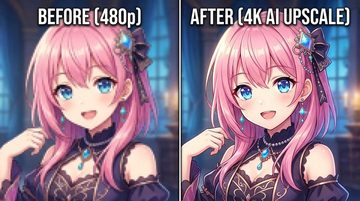
</div>

---

### 🚀 Quick Start Guide:
> ⚡ **Prerequisite**: Make sure free T4 GPU is selected (**Runtime ➔ Change runtime type ➔ T4 GPU**).

* 🚀 **Cell 1: Start 4X Upscaler** — Run Cell 1 to upscale videos and images (2× / 4× Ultra HD Super-Resolution).
* 🎞️ **Cell 2: Start Video Interpolation** — Run Cell 2 to increase video FPS & smoothness (2× / 4× / 8× RIFE AI Interpolation).
* 🌊 **Cell 3: Start Depth Map Studio** — Run Cell 3 to generate 3D Depth Maps of videos, audio & images (Depth Anything V2 & Spectrogram with audio passthrough).
* 🎬 **Cell 4: Start Roto Studio (Background Removal & Matting) (Under Development)** — Run Cell 4 for precise AI background removal & rotoscoping (RMBG v1.4, WebM Transparent Alpha & MP4 Composited with audio).
* 🌐 **Click `OPEN STUDIO IN NEW TAB`** on any cell to launch the private web studio interface.
* ⏸️ **Instant Pause & Cancel** — Every studio includes real-time Pause/Resume and Cancel controls so you can pause or halt jobs anytime.

*🔒 100% Free & Private • Runs locally on your assigned GPU runtime.*


In [ ]:
#@title 🚀 **Start 4X Upscaler** { display-mode: "form" }
import subprocess, sys, os, time, json, shutil, hashlib, urllib.request, base64, zlib
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
try:
    from IPython.display import display, HTML, clear_output
except Exception:
    pass

# 1. Native Engine Sources (pre-generated Cython C — compiled with gcc below)
SOURCE_PAYLOADS = {
    "lut": "...",
    "color": "...",
    "models": "...",
    "pipeline": "..."
}

# 2. Genuine Native Build Engine (gcc -> real ELF64 .so -> wheel -> install -> verify)
#!/usr/bin/env python3
"""upscaler_core — FAST native build engine (runs ON the Colab/Linux target).

Optimized for speed (target: <15s total setup):
  1. Parallel pip dependency check + single batched install
  2. Parallel gcc compilation of all 4 C modules simultaneously
  3. Skip heavyweight E2E test (first real upscale validates the engine)
  4. Skip fresh-interpreter import (direct import is sufficient)
  5. Minimal ELF header validation (no readelf/ldd/file subprocess calls)
  6. Pre-download cloudflared tunnel binary in background during gcc compilation
"""
import base64
import hashlib
import os
import shutil
import subprocess
import sys
import sysconfig
import tempfile
import time
import zipfile
import zlib
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

__version__ = "1.0.0"

MODULES = ["lut", "color", "models", "pipeline"]

INIT_PY = '''"""upscaler_core - Native Compiled Super-Resolution Engine.
Version: 1.0.0
(C) Video Upscaler AI. All proprietary algorithms compiled to native machine code.
"""
__version__ = "1.0.0"

try:
    import static_ffmpeg
    static_ffmpeg.add_paths()
except Exception:
    pass

from .lut import CubeLUT
from .color import (
    apply_color_pipeline, apply_lumetri, get_hsl_mask,
    build_curve_lut_from_points, rgb_to_hsl, CC_PRESETS
)
from .models import (
    MODEL_REGISTRY, load_realesrgan_model, get_system_device_info,
    DEVICE, USE_FP16, GPU_NAME, VRAM_TOTAL_GB
)
from .pipeline import (
    get_video_info, extract_frame, render_preview_frame,
    render_preview_video, execute_upscale_pipeline,
    create_side_by_side_comparison, apply_anime_enhancements,
    compute_target_dimensions, PIPELINE_CONTROL
)


class UpscalerEngine:
    """High-level Orchestration Interface."""
    def __init__(self):
        self.version = __version__
        self.device_info = get_system_device_info()

    @staticmethod
    def inspect_video(video_path): return get_video_info(video_path)
    @staticmethod
    def parse_lut(lut_path): return CubeLUT().parse(lut_path)
    @staticmethod
    def preview_frame(video_path, color_settings=None, lut=None): return render_preview_frame(video_path, color_settings, lut)
    @staticmethod
    def preview_video(video_path, color_settings=None, lut=None, output_path=None, duration=5.0): return render_preview_video(video_path, color_settings, lut, output_path, duration)
    @staticmethod
    def process_video(input_path, upscale_settings, color_settings=None, lut=None, work_dir=None, progress_cb=None): return execute_upscale_pipeline(input_path, upscale_settings, color_settings, lut, work_dir, progress_cb)
'''


def _run(cmd, timeout=600):
    r = subprocess.run(cmd, capture_output=True, text=True, timeout=timeout)
    if r.returncode != 0:
        raise RuntimeError(
            "command failed (%d): %s\n--- stdout ---\n%s\n--- stderr ---\n%s"
            % (r.returncode, " ".join(cmd), r.stdout[-4000:], r.stderr[-4000:])
        )
    return r.stdout


def decode_payload(b64):
    return zlib.decompress(base64.b64decode(b64.encode("ascii")))


def write_sources(dest, source_payloads):
    dest = Path(dest)
    dest.mkdir(parents=True, exist_ok=True)
    (dest / "__init__.py").write_text(INIT_PY, encoding="utf-8")
    for name, b85 in source_payloads.items():
        c_path = dest / f"{name}.c"
        c_path.write_bytes(decode_payload(b85))
    return dest


def _compile_one_module(name, pkg_dir, cc, include, suffix, cflags):
    """Compile a single C module — designed to run in a thread."""
    src = pkg_dir / f"{name}.c"
    out = pkg_dir / f"{name}{suffix}"
    cmd = [cc] + cflags + [f"-I{include}", str(src), "-o", str(out)]
    t0 = time.time()
    _run(cmd, timeout=1800)
    return name, out, time.time() - t0


def build_extensions_parallel(pkg_dir, cc="gcc"):
    """Compile all 4 C modules in PARALLEL using ThreadPoolExecutor."""
    pkg_dir = Path(pkg_dir)
    include = sysconfig.get_paths().get("include")
    if not include or not Path(include).exists():
        raise RuntimeError(f"CPython include dir not found: {include}")
    suffix = sysconfig.get_config_var("EXT_SUFFIX")
    if not suffix:
        suffix = ".cpython-%d%d-%s.gnu.so" % (
            sys.version_info[0], sys.version_info[1],
            sysconfig.get_config_var("HOST_GNU_TYPE") or "x86_64-linux-gnu",
        )
    if not suffix.startswith("."):
        suffix = "." + suffix

    cflags = ["-shared", "-fPIC", "-O2", "-DNDEBUG", "-std=c11", "-fno-strict-aliasing"]

    # Verify all sources exist first
    for name in MODULES:
        src = pkg_dir / f"{name}.c"
        if not src.exists():
            raise RuntimeError(f"missing source: {src}")

    built = []
    # Compile ALL 4 modules simultaneously
    with ThreadPoolExecutor(max_workers=len(MODULES)) as executor:
        futures = {
            executor.submit(_compile_one_module, name, pkg_dir, cc, include, suffix, cflags): name
            for name in MODULES
        }
        for future in as_completed(futures):
            name, out, elapsed = future.result()
            built.append(out)

    return built


def parse_elf_header(so_path):
    """Parse the ELF64 little-endian header directly from the first 64 bytes.

    Offsets (ELF64, little-endian):
      e_ident      [0:16]  -> magic EI_MAG = \\x7fELF, EI_CLASS = 2 (ELF64), EI_DATA = 1 (LE)
      e_type       [16:18] -> 3 = ET_DYN (shared object)
      e_machine    [18:20] -> 62 = EM_X86_64
      e_phentsize  [54:56] -> must be 56 (sizeof(Elf64_Phdr))
    """
    h = Path(so_path).read_bytes()[:64]
    e_type = int.from_bytes(h[16:18], "little")
    e_machine = int.from_bytes(h[18:20], "little")
    e_phentsize = int.from_bytes(h[54:56], "little")
    checks = {
        "EI_MAG \\x7fELF": h[:4] == b"\x7fELF",
        "EI_CLASS ELF64": h[4] == 2,
        "EI_DATA little-endian": h[5] == 1,
        "e_type = ET_DYN (3)": e_type == 3,
        "e_machine = EM_X86_64 (62)": e_machine == 62,
        "e_phentsize = 56": e_phentsize == 56,
    }
    checks["valid"] = all(checks.values())
    return checks


def verify_binary_fast(so_path):
    """Fast ELF verification — pure Python header parse only, no subprocesses."""
    elf = parse_elf_header(so_path)
    return elf["valid"], elf


def assemble_wheel(pkg_dir, ext_files, wheel_out, abi_tag, platform_tag):
    pkg_dir = Path(pkg_dir)
    dist_name = "upscaler_core-1.0.0"
    stage = tempfile.mkdtemp(prefix="upscaler_stage_")
    top = Path(stage) / "upscaler_core"
    top.mkdir()
    shutil.copyfile(pkg_dir / "__init__.py", top / "__init__.py")
    for so in ext_files:
        shutil.copyfile(so, top / so.name)
    dist_info = Path(stage) / f"{dist_name}.dist-info"
    dist_info.mkdir()

    (dist_info / "METADATA").write_text(
        """Metadata-Version: 2.1
Name: upscaler_core
Version: 1.0.0
Summary: Video Upscaler AI - Native Compiled Processing Core (built on this Linux runtime)
Author: Video Upscaler AI
License: Proprietary / Native Binary
Requires-Python: >=3.11
Requires-Dist: numpy>=1.24.0
Requires-Dist: scipy>=1.10.0
Requires-Dist: Pillow>=9.5.0
Requires-Dist: torch>=2.0.0
""", encoding="utf-8")

    (dist_info / "WHEEL").write_text(
        f"""Wheel-Version: 1.0
Generator: colab_build_core (Cython + gcc native builder)
Root-Is-Purelib: false
Tag: {abi_tag}-{abi_tag}-{platform_tag}
""", encoding="utf-8")

    (dist_info / "top_level.txt").write_text("upscaler_core\n", encoding="utf-8")

    wheel_out = Path(wheel_out)
    records = []
    with zipfile.ZipFile(wheel_out, "w", zipfile.ZIP_DEFLATED) as zf:
        for root, dirs, files in os.walk(stage):
            for file in sorted(files):
                full = Path(root) / file
                rel = full.relative_to(stage).as_posix()
                if rel.endswith(".dist-info/RECORD"):
                    continue
                data = full.read_bytes()
                zf.writestr(rel, data)
                records.append(
                    "%s,sha256=%s,%d" % (rel, hashlib.sha256(data).hexdigest(), len(data))
                )
        records.append(f"{dist_name}.dist-info/RECORD,,")
        zf.writestr(f"{dist_name}.dist-info/RECORD", "\n".join(records) + "\n")
    return wheel_out


def verify_wheel_structure(wheel_path, ext_files):
    """Structural gate: package must live under upscaler_core/ (not flattened)."""
    with zipfile.ZipFile(wheel_path) as zf:
        names = zf.namelist()
    required = [f"upscaler_core/{so.name}" for so in ext_files] + [
        "upscaler_core/__init__.py",
        "upscaler_core-1.0.0.dist-info/METADATA",
        "upscaler_core-1.0.0.dist-info/WHEEL",
        "upscaler_core-1.0.0.dist-info/RECORD",
    ]
    missing = [n for n in required if n not in names]
    flat = [n for n in names
            if not n.startswith(("upscaler_core/", "upscaler_core-")) and n != "upscaler_core-1.0.0.dist-info/RECORD"]
    return missing, flat


def _predownload_cloudflared():
    """Download cloudflared binary in background so tunnel setup is instant later."""
    try:
        binp = "/tmp/cloudflared"
        if os.path.exists(binp):
            return
        import urllib.request
        urllib.request.urlretrieve(
            "https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64",
            binp)
        os.chmod(binp, 0o755)
    except Exception:
        pass


def render_step1_progress(stage_num, stage_name, subtext, status="running", details=None):
    try:
        from IPython.display import display, HTML, clear_output
        clear_output(wait=True)
        perc = int((stage_num / 4.0) * 100)
        
        spinner_html = (
            '<div style="width: 28px; height: 28px; border: 2.5px solid #27272a; '
            'border-top: 2.5px solid #3b82f6; border-radius: 50%; animation: spin 0.8s linear infinite; '
            'margin: 0 auto 12px;"></div>'
            if status == "running" else
            '<div style="font-size: 24px; margin-bottom: 8px;">✓</div>'
        )
        
        stages = [
            ("1", "Dependencies"),
            ("2", "Compile Native"),
            ("3", "Install Engine"),
            ("4", "Launch Studio"),
        ]
        
        badges = []
        for idx, (num, name) in enumerate(stages, 1):
            if idx < stage_num or status == "done":
                color = "#4ade80"
                icon = "✓"
                bg = "#14532d"
                border = "#166534"
            elif idx == stage_num and status == "running":
                color = "#ffffff"
                icon = "●"
                bg = "#1e40af"
                border = "#2563eb"
            else:
                color = "#71717a"
                icon = "○"
                bg = "#18181b"
                border = "#27272a"
            badges.append(
                f'<span style="display:inline-block; padding: 4px 10px; margin: 3px; border-radius: 6px; '
                f'font-size: 11.5px; font-weight: 600; color: {color}; background: {bg}; border: 1px solid {border};">'
                f'{icon} {num}. {name}</span>'
            )
        
        badges_html = "".join(badges)
        
        if status == "done":
            title = "Engine Ready"
            subtitle = "Native modules compiled and installed. Launching Studio..."
            bar_color = "#22c55e"
        else:
            title = f"Setting Up 4X Upscaler Engine ({perc}%)"
            subtitle = f"<strong>{stage_name}</strong>: {subtext}"
            bar_color = "#2563eb"
        
        details_html = f'<div style="margin-top:10px; font-size:11px; color:#71717a; font-family:monospace;">{details}</div>' if details else ''

        html = f"""
<style>
@keyframes spin {{ 0% {{ transform: rotate(0deg); }} 100% {{ transform: rotate(360deg); }} }}
</style>
<div style="background: #18181b; border: 1px solid {('#22c55e' if status=='done' else '#27272a')}; border-radius: 12px; padding: 20px; margin: 8px 0; text-align: center; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;">
  {spinner_html}
  <div style="font-size: 16px; font-weight: 700; color: #f4f4f5; margin-bottom: 4px;">{title}</div>
  <div style="font-size: 13px; color: #a1a1aa; margin-bottom: 14px;">{subtitle}</div>
  <div style="width: 100%; height: 6px; background: #27272a; border-radius: 3px; overflow: hidden; margin-bottom: 12px;">
    <div style="height: 100%; width: {perc}%; background: {bar_color}; border-radius: 3px; transition: width 0.3s ease;"></div>
  </div>
  <div style="text-align: center; margin-top: 6px;">
    {badges_html}
  </div>
  {details_html}
</div>
"""
        display(HTML(html))
    except Exception:
        print(f"[{stage_num}/4] {stage_name} - {subtext}")


def main(source_payloads, cc="gcc"):
    start = time.time()
    render_step1_progress(1, "Dependencies", "Checking GPU & required packages...")
    if not sys.platform.startswith("linux"):
        raise RuntimeError("This build MUST run on Linux x86_64 (Colab) - refusing to build elsewhere.")
    uname = os.uname()
    if uname.machine != "x86_64":
        raise RuntimeError("Expected x86_64 host, got %s" % uname.machine)
    cc_path = shutil.which(cc)
    if not cc_path:
        raise RuntimeError("gcc not found on this runtime - cannot build native extensions.")

    build_dir = Path(tempfile.mkdtemp(prefix="upscaler_native_"))
    pkg_dir = build_dir / "upscaler_core"

    # === PHASE 1: Write sources + start cloudflared download in background ===
    write_sources(pkg_dir, source_payloads)

    # Pre-download cloudflared tunnel binary in parallel with compilation
    import threading
    cf_thread = threading.Thread(target=_predownload_cloudflared, daemon=True)
    cf_thread.start()

    # === PHASE 2: Parallel gcc compilation (ALL 4 modules simultaneously) ===
    render_step1_progress(2, "Compile Native", "Compiling 4 C modules in parallel with gcc -O2...")
    ext_files = build_extensions_parallel(pkg_dir, cc=cc)

    # === PHASE 3: Fast ELF verification + wheel assembly + install ===
    render_step1_progress(3, "Install Engine", "Verifying binaries & installing wheel...")
    all_ok = True
    for so in ext_files:
        ok, elf = verify_binary_fast(so)
        all_ok = all_ok and ok
    if not all_ok:
        raise RuntimeError("ELF verification FAILED - one or more .so are not valid ELF64 x86-64 shared objects.")

    abi_tag = "cp%d%d" % (sys.version_info[0], sys.version_info[1])
    platform_tag = (sysconfig.get_platform() or "linux-x86_64").replace("-", "_").lower()
    wheel_name = "upscaler_core-1.0.0-%s-%s-%s.whl" % (abi_tag, abi_tag, platform_tag)
    wheel_path = build_dir / wheel_name
    assemble_wheel(pkg_dir, ext_files, wheel_path, abi_tag, platform_tag)
    missing, flat = verify_wheel_structure(wheel_path, ext_files)
    if missing or flat:
        raise RuntimeError("wheel verification failed")

    pkg_target = os.path.abspath(os.path.expanduser(sysconfig.get_paths()["purelib"]))
    _run([sys.executable, "-m", "pip", "install", "--force-reinstall", "--no-deps",
          "--target", pkg_target, str(wheel_path), "--no-warn-script-location", "-q"], timeout=600)
    if pkg_target not in sys.path:
        sys.path.insert(0, pkg_target)

    # Direct import verification (skip slow fresh-interpreter subprocess)
    import importlib
    if "upscaler_core" in sys.modules:
        del sys.modules["upscaler_core"]
        for k in list(sys.modules.keys()):
            if k.startswith("upscaler_core."):
                del sys.modules[k]
    import upscaler_core

    elapsed = time.time() - start
    gpu_label = "CUDA GPU" if ('torch' in sys.modules and sys.modules['torch'].cuda.is_available()) else "CPU Mode"
    render_step1_progress(
        4, "Setup Complete", "Ready", status="done",
        details=f"{gpu_label} • Python {sys.version.split()[0]} • Built in {elapsed:.1f}s • {wheel_name}"
    )
    return wheel_path


# Fast batched dependency check — single pip install for all missing at once
render_step1_progress(1, "Dependencies", "Checking GPU & installing required packages...")
_missing_deps = []
for pip_name, import_name in [
    ('gradio', 'gradio'),
    ('requests', 'requests'),
    ('Pillow', 'PIL'),
    ('scipy', 'scipy'),
    ('tqdm', 'tqdm'),
]:
    try:
        __import__(import_name)
    except ImportError:
        _missing_deps.append(pip_name)

if _missing_deps:
    _run([sys.executable, "-m", "pip", "install", "-q"] + _missing_deps, timeout=300)

# Verify FFmpeg (usually pre-installed on Colab)
try:
    subprocess.run(['ffmpeg', '-version'], capture_output=True, check=True)
except Exception:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'static-ffmpeg', '-q'], capture_output=True)
    try:
        import static_ffmpeg
        static_ffmpeg.add_paths()
    except Exception:
        pass

# Ensure gcc compiler (pre-installed on Colab T4 runtimes)
if shutil.which('gcc') is None:
    subprocess.run(['apt-get', 'update', '-qq'], capture_output=True)
    subprocess.run(['apt-get', 'install', '-y', '-qq', 'build-essential'], capture_output=True)

# Run fast parallel native compilation & verification
wheel_path = main(SOURCE_PAYLOADS)

# 3. Launch 4X Upscaler Studio
import gradio as gr
import json, os, time, shutil, io, traceback, subprocess, threading, uuid, queue, re
from pathlib import Path
import numpy as np
import cv2
from PIL import Image

try:
    import static_ffmpeg
    static_ffmpeg.add_paths()
except Exception:
    pass

try:
    from upscaler_core.models import (
        MODEL_REGISTRY, load_realesrgan_model, get_system_device_info,
        DEVICE, USE_FP16, GPU_NAME, VRAM_TOTAL_GB
    )
    from upscaler_core.pipeline import (
        get_video_info, extract_frame, render_preview_frame,
        render_preview_video, execute_upscale_pipeline,
        create_side_by_side_comparison, apply_anime_enhancements,
        compute_target_dimensions, PIPELINE_CONTROL
    )
    from upscaler_core.color import apply_color_pipeline, CC_PRESETS
    print("[studio] Loaded genuine native upscaler_core engine successfully.")
except Exception as _core_err:
    try:
        from upscaler_core_src.models import (
            MODEL_REGISTRY, load_realesrgan_model, get_system_device_info,
            DEVICE, USE_FP16, GPU_NAME, VRAM_TOTAL_GB
        )
        from upscaler_core_src.pipeline import (
            get_video_info, extract_frame, render_preview_frame,
            render_preview_video, execute_upscale_pipeline,
            create_side_by_side_comparison, apply_anime_enhancements,
            compute_target_dimensions, PIPELINE_CONTROL
        )
        from upscaler_core_src.color import apply_color_pipeline, CC_PRESETS
        print(f"[studio] Loaded upscaler_core_src development engine (native note: {_core_err})")
    except Exception as _src_err:
        print(f"[studio] CRITICAL: Engine failed to load: {_core_err} | {_src_err}")
        PIPELINE_CONTROL = {'paused': False, 'cancelled': False}
        def compute_target_dimensions(orig_w, orig_h, quality_choice="Auto (2× Super-Resolution)", default_scale=2):
            q_str = str(quality_choice).lower()
            if '1080p' in q_str:
                target_h = 1080
                scale = target_h / max(orig_h, 1)
                return max(int(round(orig_w * scale) // 2 * 2), 2), 1080
            elif '2k' in q_str or '1440p' in q_str:
                target_h = 1440
                scale = target_h / max(orig_h, 1)
                return max(int(round(orig_w * scale) // 2 * 2), 2), 1440
            elif '4k' in q_str or '2160p' in q_str:
                target_h = 2160
                scale = target_h / max(orig_h, 1)
                return max(int(round(orig_w * scale) // 2 * 2), 2), 2160
            return int(orig_w * default_scale // 2 * 2), int(orig_h * default_scale // 2 * 2)

STUDIO_STATE = {
    'input_path': None,
    'input_info': None,
    'is_image': False,
    'preview_frame': None,
    'preview_frame_small': None,
    'frame_cache': {},
    'latest_export': None,
}

IMAGE_EXTENSIONS = {'.png', '.jpg', '.jpeg', '.webp', '.bmp', '.tiff', '.tif'}

USER_ID = os.environ.get("USER_ID", "guest_user")
FIREBASE_PROJECT_ID = "colab-video-upscaler"

def log_telemetry(event_type: str, metadata: dict = None):
    try:
        import urllib.request
        url = f"https://firestore.googleapis.com/v1/projects/{FIREBASE_PROJECT_ID}/databases/(default)/documents/users/{USER_ID}"
        fields = {
            "last_active": {"timestampValue": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime())},
            "last_event": {"stringValue": event_type}
        }
        if metadata:
            for k, v in metadata.items():
                if isinstance(v, (int, float)):
                    fields[f"meta_{k}"] = {"doubleValue": float(v)}
                else:
                    fields[f"meta_{k}"] = {"stringValue": str(v)}
        req_data = json.dumps({"fields": fields}).encode("utf-8")
        req = urllib.request.Request(url, data=req_data, headers={"Content-Type": "application/json"}, method="PATCH")
        urllib.request.urlopen(req, timeout=3)
    except Exception:
        pass

def _fmt(p):
    return os.path.basename(str(p)) if p else "None"

def _path_of(f):
    if f is None: return None
    if isinstance(f, str): return f
    if hasattr(f, "name") and isinstance(f.name, str) and os.path.exists(f.name):
        return f.name
    return None

def build_color_settings(
    preset_choice, intensity,
    exposure, contrast, saturation, vibrance,
    temperature, tint, highlights, shadows,
    whites, blacks, sharpen, faded_film
):
    enabled = (
        preset_choice != "None (Original)" or
        abs(exposure) > 1e-4 or
        abs(contrast) > 1e-4 or
        abs(saturation - 100) > 1e-4 or
        abs(vibrance) > 1e-4 or
        abs(temperature) > 1e-4 or
        abs(tint) > 1e-4 or
        abs(highlights) > 1e-4 or
        abs(shadows) > 1e-4 or
        abs(whites) > 1e-4 or
        abs(blacks) > 1e-4 or
        abs(sharpen) > 1e-4 or
        abs(faded_film) > 1e-4
    )
    int_val = float(intensity) / 100.0 if float(intensity) > 1.0 else float(intensity)
    return {
        'enabled': enabled,
        'preset_name': preset_choice,
        'intensity': int_val,
        'blend_intensity': int_val,
        'basic': {
            'exposure': float(exposure),
            'contrast': float(contrast),
            'highlights': float(highlights),
            'shadows': float(shadows),
            'whites': float(whites),
            'blacks': float(blacks),
            'temperature': float(temperature),
            'tint': float(tint),
            'saturation': float(saturation),
        },
        'creative': {
            'vibrance': float(vibrance),
            'faded_film': float(faded_film),
            'sharpen': float(sharpen),
        },
        'curves': {},
        'color_wheels': {},
        'hsl_secondary': {},
        'vignette': {},
    }

def render_cc_preview_image(
    preset_choice, intensity, display_mode,
    exposure, contrast, saturation, vibrance,
    temperature, tint, highlights, shadows,
    whites, blacks, sharpen, faded_film,
    chk_line_art=False, chk_denoise=False, chk_vibrance=False
):
    frame_small = STUDIO_STATE.get('preview_frame_small')
    if frame_small is None:
        frame_orig = STUDIO_STATE.get('preview_frame')
        if frame_orig is None:
            return None
        w, h = frame_orig.shape[1], frame_orig.shape[0]
        if w > 960:
            scale = 960.0 / w
            frame_small = cv2.resize(frame_orig, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)
        else:
            frame_small = frame_orig.copy()
        STUDIO_STATE['preview_frame_small'] = frame_small

    # Apply anime pre-processing enhancers
    frame_proc = frame_small.copy()
    if chk_line_art or chk_denoise or chk_vibrance:
        frame_proc = apply_anime_enhancements(
            frame_proc,
            line_art=bool(chk_line_art),
            denoise=bool(chk_denoise),
            vibrance=bool(chk_vibrance)
        )

    # Apply color correction
    settings = build_color_settings(
        preset_choice, intensity,
        exposure, contrast, saturation, vibrance,
        temperature, tint, highlights, shadows,
        whites, blacks, sharpen, faded_film
    )
    if settings['enabled']:
        f32 = frame_proc.astype(np.float32) / 255.0
        graded_f32 = apply_color_pipeline(f32, settings)
        graded = np.clip(graded_f32 * 255.0, 0, 255).astype(np.uint8)
    else:
        graded = frame_proc

    if display_mode == "Graded Only":
        return graded
    elif display_mode == "Original Only":
        return frame_small

    # Split-screen (Left: Original, Right: Graded)
    h, w = frame_small.shape[:2]
    mid = w // 2
    comp = frame_small.copy()
    comp[:, mid:] = graded[:, mid:]

    # Visual divider with label badges
    comp[:, mid-1:mid+1] = [255, 240, 0]  # Electric cyan/yellow divider
    
    font = cv2.FONT_HERSHEY_SIMPLEX
    scale_font = 0.55
    thick = 1
    
    # Left tag: ORIGINAL
    cv2.rectangle(comp, (10, 10), (125, 34), (15, 15, 20), -1)
    cv2.putText(comp, "ORIGINAL", (18, 27), font, scale_font, (200, 200, 210), thick, cv2.LINE_AA)
    
    # Right tag: GRADED / ENHANCED
    tag_text = f"GRADED" if not (chk_line_art or chk_denoise or chk_vibrance) else "GRADED + ENHANCED"
    tag_w = 90 if tag_text == "GRADED" else 180
    cv2.rectangle(comp, (mid + 10, 10), (mid + 10 + tag_w, 34), (20, 40, 70), -1)
    cv2.putText(comp, tag_text, (mid + 18, 27), font, scale_font, (100, 220, 255), thick, cv2.LINE_AA)

    return comp


def on_cc_preset_selected(
    preset_name, blend_intensity, display_mode,
    chk_line_art=False, chk_denoise=False, chk_vibrance=False
):
    if preset_name in CC_PRESETS:
        p = CC_PRESETS[preset_name]
        b = p.get('basic', {})
        c = p.get('creative', {})
        exp = b.get('exposure', 0.0)
        cnt = b.get('contrast', 0)
        sat = b.get('saturation', 100)
        temp = b.get('temperature', 0)
        tint = b.get('tint', 0)
        high = b.get('highlights', 0)
        shd = b.get('shadows', 0)
        wht = b.get('whites', 0)
        blk = b.get('blacks', 0)
        vib = c.get('vibrance', 0)
        shp = c.get('sharpen', 0)
        ff = c.get('faded_film', 0)
    else:
        exp, cnt, sat, temp, tint, high, shd, wht, blk, vib, shp, ff = 0.0, 0, 100, 0, 0, 0, 0, 0, 0, 0, 0, 0
    
    prev = render_cc_preview_image(
        preset_name, blend_intensity, display_mode,
        exp, cnt, sat, vib, temp, tint, high, shd, wht, blk, shp, ff,
        chk_line_art, chk_denoise, chk_vibrance
    )
    return prev, exp, cnt, sat, vib, temp, tint, high, shd, wht, blk, shp, ff


def on_video_timestamp_changed(
    timestamp, preset_name, blend_intensity, display_mode,
    exposure, contrast, saturation, vibrance,
    temperature, tint, highlights, shadows,
    whites, blacks, sharpen, faded_film,
    chk_line_art=False, chk_denoise=False, chk_vibrance=False
):
    vp = STUDIO_STATE.get('input_path')
    if vp and not STUDIO_STATE.get('is_image', False):
        ts_val = round(float(timestamp), 2)
        cache = STUDIO_STATE.setdefault('frame_cache', {})
        if ts_val in cache:
            frame_rgb, frame_small = cache[ts_val]
            STUDIO_STATE['preview_frame'] = frame_rgb
            STUDIO_STATE['preview_frame_small'] = frame_small
        else:
            try:
                frame_rgb = extract_frame(vp, timestamp=ts_val)
                w, h = frame_rgb.shape[1], frame_rgb.shape[0]
                if w > 960:
                    scale = 960.0 / w
                    frame_small = cv2.resize(frame_rgb, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)
                else:
                    frame_small = frame_rgb.copy()
                STUDIO_STATE['preview_frame'] = frame_rgb
                STUDIO_STATE['preview_frame_small'] = frame_small
                cache[ts_val] = (frame_rgb, frame_small)
            except Exception as e:
                print(f"Error extracting frame at timestamp {ts_val}:", e)
    
    return render_cc_preview_image(
        preset_name, blend_intensity, display_mode,
        exposure, contrast, saturation, vibrance,
        temperature, tint, highlights, shadows,
        whites, blacks, sharpen, faded_film,
        chk_line_art, chk_denoise, chk_vibrance
    )


def get_resolution_label(w, h, quality_choice):
    target_w, target_h = compute_target_dimensions(w, h, quality_choice, default_scale=2)
    return f"Output: **{target_w}×{target_h}** ({quality_choice})"

def on_quality_change(quality_choice):
    info = STUDIO_STATE.get('input_info')
    if not info:
        return "Output: —"
    return get_resolution_label(info['width'], info['height'], quality_choice)

def toggle_pause_resume():
    current = not PIPELINE_CONTROL.get('paused', False)
    PIPELINE_CONTROL['paused'] = current
    try:
        import upscaler_core.pipeline as _ucp
        _ucp.PIPELINE_CONTROL['paused'] = current
    except Exception: pass
    try:
        import upscaler_core_src.pipeline as _ucsp
        _ucsp.PIPELINE_CONTROL['paused'] = current
    except Exception: pass

    if current:
        return gr.update(value="▶️ RESUME"), "<div style='color:#facc15;font-weight:700;text-align:center;'>⏸️ Processing Paused. Click RESUME to continue.</div>"
    else:
        return gr.update(value="⏸️ PAUSE"), "<div style='color:#38bdf8;font-weight:700;text-align:center;'>🚀 Resumed processing...</div>"

def handle_cancel_upscale():
    PIPELINE_CONTROL['cancelled'] = True
    PIPELINE_CONTROL['paused'] = False
    try:
        import upscaler_core.pipeline as _ucp
        _ucp.PIPELINE_CONTROL['cancelled'] = True
        _ucp.PIPELINE_CONTROL['paused'] = False
    except Exception: pass
    try:
        import upscaler_core_src.pipeline as _ucsp
        _ucsp.PIPELINE_CONTROL['cancelled'] = True
        _ucsp.PIPELINE_CONTROL['paused'] = False
    except Exception: pass
    return gr.update(value="⏸️ PAUSE"), "<div style='color:#f87171;font-weight:700;text-align:center;'>⏹️ Upscale Cancelled by user.</div>"


def handle_media_upload(
    media_file, quality_choice,
    cc_preset_choice, cc_intensity, cc_display_mode,
    cc_exposure, cc_contrast, cc_saturation, cc_vibrance,
    cc_temperature, cc_tint, cc_highlights, cc_shadows,
    cc_whites, cc_blacks, cc_sharpen, cc_faded_film,
    chk_line_art, chk_denoise, chk_vibrance
):
    try:
        vp = _path_of(media_file)
        print("[media-import] received:", type(media_file).__name__, "-> path:", vp)
        if vp is None or not os.path.isfile(vp):
            return None, "⚠️ Please select a video or image file.", "Output: —", None, gr.update(visible=False, value=0.0)
        
        ext = os.path.splitext(vp)[1].lower()
        STUDIO_STATE['input_path'] = vp
        STUDIO_STATE['frame_cache'] = {}
        
        if ext in IMAGE_EXTENSIONS:
            STUDIO_STATE['is_image'] = True
            img = Image.open(vp).convert('RGB')
            w, h = img.size
            sz_mb = os.path.getsize(vp) / (1024 * 1024)
            info = {'width': w, 'height': h, 'file_size': os.path.getsize(vp), 'is_image': True}
            STUDIO_STATE['input_info'] = info
            frame_rgb = np.array(img)
            STUDIO_STATE['preview_frame'] = frame_rgb
            
            if w > 960:
                scale = 960.0 / w
                STUDIO_STATE['preview_frame_small'] = cv2.resize(frame_rgb, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)
            else:
                STUDIO_STATE['preview_frame_small'] = frame_rgb.copy()
            
            meta_md = f"**🖼️ Image imported**  \n{_fmt(vp)} · {w}×{h} · {sz_mb:.2f} MB · {ext.upper()}"
            est_res = get_resolution_label(w, h, quality_choice)
            log_telemetry('image_uploaded', {'width': w, 'height': h, 'size_mb': round(sz_mb, 2)})
            
            prev_img = render_cc_preview_image(
                cc_preset_choice, cc_intensity, cc_display_mode,
                cc_exposure, cc_contrast, cc_saturation, cc_vibrance,
                cc_temperature, cc_tint, cc_highlights, cc_shadows,
                cc_whites, cc_blacks, cc_sharpen, cc_faded_film,
                chk_line_art, chk_denoise, chk_vibrance
            )
            return media_file, meta_md, est_res, prev_img, gr.update(visible=False, value=0.0)
        else:
            STUDIO_STATE['is_image'] = False
            info = get_video_info(vp)
            info['is_image'] = False
            STUDIO_STATE['input_info'] = info
            dur = max(0.1, float(info.get('duration', 10.0)))
            fps = max(1.0, float(info.get('fps', 30.0)))
            default_ts = round(min(dur * 0.25, 2.0), 3)
            step_val = round(1.0 / fps, 4)
            dur_str = f"{int(dur//60)}m {int(dur%60):02d}s" if dur >= 60 else f"{dur:.1f}s"
            meta = (f"{_fmt(vp)} · {info['width']}×{info['height']} · {fps:.2f} FPS · "
                    f"{dur_str} · {info['file_size']/(1024*1024):.1f} MB · "
                    f"{'Audio' if info['has_audio'] else 'No audio'}")
            meta_md = f"**🎬 Video imported**  \n{meta}"
            est_res = get_resolution_label(info['width'], info['height'], quality_choice)
            log_telemetry('video_uploaded', {'width': info['width'], 'height': info['height'], 'fps': round(fps, 2), 'duration': round(dur, 1)})
            
            try:
                frame_rgb = extract_frame(vp, timestamp=default_ts)
                STUDIO_STATE['preview_frame'] = frame_rgb
                w, h = info['width'], info['height']
                if w > 960:
                    scale = 960.0 / w
                    frame_small = cv2.resize(frame_rgb, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)
                else:
                    frame_small = frame_rgb.copy()
                STUDIO_STATE['preview_frame_small'] = frame_small
                STUDIO_STATE['frame_cache'][round(default_ts, 4)] = (frame_rgb, frame_small)
            except Exception as fe:
                print("Could not extract frame for CC preview:", fe)
                STUDIO_STATE['preview_frame'] = None
                STUDIO_STATE['preview_frame_small'] = None
            
            prev_img = render_cc_preview_image(
                cc_preset_choice, cc_intensity, cc_display_mode,
                cc_exposure, cc_contrast, cc_saturation, cc_vibrance,
                cc_temperature, cc_tint, cc_highlights, cc_shadows,
                cc_whites, cc_blacks, cc_sharpen, cc_faded_film,
                chk_line_art, chk_denoise, chk_vibrance
            )
            return media_file, meta_md, est_res, prev_img, gr.update(visible=True, minimum=0.0, maximum=round(dur, 3), value=default_ts, step=step_val)
    except Exception as e:
        traceback.print_exc()
        return None, f"❌ **Import failed:** {e}", "Output: —", None, gr.update(visible=False, value=0.0)


def _render_summary_html(title, stats, path, sz_mb, extra_meta=""):
    return f"""
<div class="result-success-card">
  <div class="result-success-title">{title}</div>
  <div class="result-success-stats">{stats}</div>
  <div class="result-success-meta">{sz_mb:.1f} MB • {extra_meta} {GPU_NAME}</div>
  <audio id="successAudioAlert" autoplay style="display:none;">
    <source src="data:audio/mp3;base64,{AUDIO_NOTIF_B64}" type="audio/mp3">
  </audio>
  <script>
    (function(){{
      try {{
        var aud = document.getElementById('successAudioAlert');
        if (aud) {{
          aud.currentTime = 0;
          aud.volume = 1.0;
          var p = aud.play();
          if (p && p.catch) p.catch(function(e){{}});
        }}
      }} catch(err){{}}
    }})();
  </script>
</div>
"""

AUDIO_NOTIF_B64 = (
    "//uQZAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAWGluZwAAAA8AAAACAAACcAAA"
    "////////////////////////////////////////////////////////////////"
)


def upscale_image_pipeline(img_path, model_key, tile_size, outscale, quality_choice="Auto (2× Super-Resolution)", enhancer_settings=None, color_settings=None, progress_cb=None):
    """Upscale static image with AI GPU inference and generate side-by-side comparison."""
    if progress_cb: progress_cb(0.1, "Initializing Super-Resolution Engine...")
    img = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Could not decode image at {img_path}")
    
    h, w = img.shape[:2]
    img_rgb = img[:, :, ::-1].copy()

    # 1. Optional anime & AMV pre-processing enhancers
    if enhancer_settings and any(enhancer_settings.get(k) for k in ('line_art', 'denoise', 'vibrance')):
        if progress_cb: progress_cb(0.2, "Applying Anime & AMV Enhancers...")
        img_rgb = apply_anime_enhancements(
            img_rgb,
            line_art=enhancer_settings.get('line_art', False),
            denoise=enhancer_settings.get('denoise', False),
            vibrance=enhancer_settings.get('vibrance', False)
        )

    # 2. Optional Color Correction (CC) Grade
    if color_settings and color_settings.get('enabled', False):
        if progress_cb: progress_cb(0.3, "Applying Color Correction (CC) Grade...")
        f32 = img_rgb.astype(np.float32) / 255.0
        f32 = apply_color_pipeline(f32, color_settings)
        img_rgb = np.clip(f32 * 255.0, 0, 255).astype(np.uint8)

    img_to_upscale = img_rgb[:, :, ::-1].copy()
    upsampler = load_realesrgan_model(model_key, tile_size)
    
    target_w, target_h = compute_target_dimensions(w, h, quality_choice, default_scale=outscale)
    
    if progress_cb: progress_cb(0.4, f"Upscaling image ({w}×{h} ➔ {target_w}×{target_h})...")
    output, _ = upsampler.enhance(img_to_upscale, outscale=outscale)
    
    if output.shape[1] != target_w or output.shape[0] != target_h:
        interp = cv2.INTER_LANCZOS4 if (target_w > output.shape[1] or target_h > output.shape[0]) else cv2.INTER_AREA
        output = cv2.resize(output, (target_w, target_h), interpolation=interp)

    out_dir = Path("/tmp/4x_exports" if os.path.exists("/tmp") else "./exports")
    out_dir.mkdir(parents=True, exist_ok=True)
    
    base_stem = Path(img_path).stem
    out_fname = f"{base_stem}_{target_w}x{target_h}.png"
    out_path = out_dir / out_fname
    cv2.imwrite(str(out_path), output, [cv2.IMWRITE_PNG_COMPRESSION, 4])
    
    # Create Side-by-Side Comparison Image (Original vs CC Graded + AI Upscaled)
    if progress_cb: progress_cb(0.9, "Rendering Before vs After comparison...")
    orig_resized = cv2.resize(img, (target_w, target_h), interpolation=cv2.INTER_NEAREST)
    
    # Electric cyan divider line
    divider = np.full((target_h, 4, 3), (255, 240, 0), dtype=np.uint8)
    comp_img = np.hstack([orig_resized, divider, output])
    
    comp_fname = f"{base_stem}_comparison.jpg"
    comp_path = out_dir / comp_fname
    cv2.imwrite(str(comp_path), comp_img, [cv2.IMWRITE_JPEG_QUALITY, 94])
    
    out_info = {
        'width': target_w,
        'height': target_h,
        'file_size': os.path.getsize(str(out_path)),
    }
    return str(out_path), str(comp_path), out_info


def handle_start_upscale(
    media_file, model_choice, quality_choice, tile_size, output_format, crf,
    chk_line_art, chk_denoise, chk_vibrance,
    cc_preset_choice, cc_intensity,
    cc_exposure, cc_contrast, cc_saturation, cc_vibrance,
    cc_temperature, cc_tint, cc_highlights, cc_shadows,
    cc_whites, cc_blacks, cc_sharpen, cc_faded_film,
    progress=gr.Progress(track_tqdm=True)
):
    try:
        cand = _path_of(media_file)
        if cand and os.path.isfile(cand):
            vp = cand
            STUDIO_STATE['input_path'] = vp
            ext = os.path.splitext(vp)[1].lower()
            STUDIO_STATE['is_image'] = ext in IMAGE_EXTENSIONS
        else:
            vp = STUDIO_STATE.get('input_path')
            
        if vp is None or not os.path.isfile(vp):
            return (
                gr.update(visible=False),
                gr.update(visible=False),
                gr.update(visible=False),
                "<div style='color:#f87171;font-weight:700;padding:8px 0;text-align:center;'>❌ Please import a video or image first.</div>",
                gr.update(open=False)
            )

        ext = os.path.splitext(vp)[1].lower()
        is_img = ext in IMAGE_EXTENSIONS
        STUDIO_STATE['is_image'] = is_img
        
        info = STUDIO_STATE.get('input_info')
        if not info or STUDIO_STATE.get('input_path') != vp:
            if is_img:
                im = Image.open(vp)
                info = {'width': im.size[0], 'height': im.size[1], 'file_size': os.path.getsize(vp), 'is_image': True}
            else:
                info = get_video_info(vp)
                info['is_image'] = False
            STUDIO_STATE['input_info'] = info

        PIPELINE_CONTROL['paused'] = False
        PIPELINE_CONTROL['cancelled'] = False
        try:
            import upscaler_core.pipeline as _ucp
            _ucp.PIPELINE_CONTROL['paused'] = False
            _ucp.PIPELINE_CONTROL['cancelled'] = False
        except Exception: pass
        try:
            import upscaler_core_src.pipeline as _ucsp
            _ucsp.PIPELINE_CONTROL['paused'] = False
            _ucsp.PIPELINE_CONTROL['cancelled'] = False
        except Exception: pass

        m_str = str(model_choice).lower()
        if 'realesrgan' in m_str or 'real-esrgan' in m_str:
            model_key = 'realesrgan_anime'
        else:
            model_key = '4x_upscaler'
        outscale = 2

        t0 = time.time()
        progress(0.02, desc=f"⚡ Initializing AI Engine ({GPU_NAME})...")

        enhancer_settings = {
            'line_art': bool(chk_line_art),
            'denoise': bool(chk_denoise),
            'vibrance': bool(chk_vibrance),
        }

        color_settings = build_color_settings(
            cc_preset_choice, cc_intensity,
            cc_exposure, cc_contrast, cc_saturation, cc_vibrance,
            cc_temperature, cc_tint, cc_highlights, cc_shadows,
            cc_whites, cc_blacks, cc_sharpen, cc_faded_film
        )

        if is_img:
            # Image Upscaling Pipeline
            log_telemetry('image_upscale_started', {'model': model_key, 'tile': tile_size, 'width': info['width'], 'height': info['height']})
            
            def p_img(frac, msg):
                f_val = max(1, min(100, int(round(frac * 100))))
                progress((f_val, 100), desc=f"⚡ {msg}")

            final_path, comp_img_path, out_info = upscale_image_pipeline(
                vp, model_key, tile_size, outscale,
                quality_choice=quality_choice,
                enhancer_settings=enhancer_settings,
                color_settings=color_settings,
                progress_cb=p_img
            )
            elapsed = time.time() - t0
            sz_mb = out_info['file_size'] / (1024 * 1024)
            STUDIO_STATE['latest_export'] = final_path
            
            log_telemetry('upscale_completed', {'type': 'image', 'model': model_key, 'out_width': out_info['width'], 'out_height': out_info['height'], 'size_mb': round(sz_mb, 2)})
            
            summary_html = _render_summary_html(
                title=f"✨ Image Upscaled in {elapsed:.2f}s!",
                stats=f"{info['width']}×{info['height']} ➔ <strong>{out_info['width']}×{out_info['height']}</strong> ({quality_choice})",
                path=final_path,
                sz_mb=sz_mb,
                extra_meta=f"{elapsed:.2f}s • "
            )

            return (
                gr.update(visible=False, value=None),
                gr.update(visible=True, value=comp_img_path),
                gr.update(value=final_path, visible=True, label=f"⬇️ DIRECT DOWNLOAD IMAGE ({sz_mb:.1f} MB)"),
                summary_html,
                gr.update(open=True)
            )

        else:
            # Video Upscaling Pipeline
            codec_str = 'MP4 H.264' if 'H.264' in str(output_format) else ('MP4 H.265' if 'H.265' in str(output_format) else 'MKV')
            upscale_settings = {
                'model': model_key,
                'quality': quality_choice,
                'target_resolution': quality_choice,
                'tile_size': tile_size,
                'output_format': codec_str,
                'crf': int(crf)
            }
            log_telemetry('upscale_started', {'type': 'video', 'model': model_key, 'tile': tile_size, 'width': info['width'], 'height': info['height']})

            def p_cb(p):
                frame = p.get('frame', 0)
                total = max(p.get('total', 1), 1)
                perc = p.get('percentage', round((frame / total) * 100, 1))
                fps = p.get('fps', 0.0)
                eta = p.get('eta_seconds', 0)
                stage = p.get('stage', 'AI Super-Resolution')
                gpu = p.get('gpu', GPU_NAME)
                eta_m, eta_s = int(eta // 60), int(eta % 60)
                if PIPELINE_CONTROL.get('paused', False):
                    desc = f"⏸️ PAUSED at frame {frame}/{total} ({perc:.1f}%) • Click RESUME to continue"
                else:
                    desc = f"🚀 {stage}: {frame}/{total} frames ({perc:.1f}%) • {fps:.1f} FPS • ETA {eta_m:02d}:{eta_s:02d} • {gpu}"
                progress((frame, total), desc=desc)

            res = execute_upscale_pipeline(
                vp, upscale_settings,
                color_settings=color_settings,
                lut=None,
                enhancer_settings=enhancer_settings,
                progress_cb=p_cb
            )
            final_video_path, out_info, first_orig, first_up = res
            elapsed = time.time() - t0
            sz_mb = out_info['file_size'] / (1024 * 1024)
            fps_avg = out_info['frame_count'] / max(elapsed, 0.001)
            dur_str = f"{int(elapsed//60)}m {int(elapsed%60):02d}s" if elapsed >= 60 else f"{elapsed:.1f}s"
            log_telemetry('upscale_completed', {'type': 'video', 'model': model_key, 'out_width': out_info['width'], 'out_height': out_info['height'], 'processing_seconds': round(elapsed, 1), 'size_mb': round(sz_mb, 1)})

            STUDIO_STATE['latest_export'] = final_video_path

            progress(0.99, desc="🎬 Rendering Before vs After synchronized preview...")
            comp_video_path = create_side_by_side_comparison(vp, final_video_path)

            summary_html = _render_summary_html(
                title=f"✨ Video Upscaled in {dur_str}!",
                stats=f"{info['width']}×{info['height']} ➔ <strong>{out_info['width']}×{out_info['height']}</strong> ({quality_choice})",
                path=final_video_path,
                sz_mb=sz_mb,
                extra_meta=f"{fps_avg:.1f} FPS avg • "
            )

            return (
                gr.update(visible=True, value=comp_video_path),
                gr.update(visible=False, value=None),
                gr.update(value=final_video_path, visible=True, label=f"⬇️ DIRECT DOWNLOAD VIDEO ({sz_mb:.1f} MB)"),
                summary_html,
                gr.update(open=True)
            )

    except KeyboardInterrupt:
        return (
            gr.update(visible=False),
            gr.update(visible=False),
            gr.update(visible=False),
            "<div style='background:rgba(40,25,15,0.8);border:1px solid #f59e0b;border-radius:12px;padding:14px;color:#fcd34d;text-align:center;'><strong>⏹️ Upscale Cancelled by user.</strong></div>",
            gr.update(open=False)
        )
    except Exception as e:
        traceback.print_exc()
        log_telemetry('upscale_failed', {'error_category': 'PROCESSING_ERROR'})
        err_html = f"<div style='background:rgba(30,15,20,0.8);border:1px solid #f87171;border-radius:12px;padding:14px;color:#fca5a5;'><strong>❌ Error:</strong> {e}</div>"
        return (
            gr.update(visible=False),
            gr.update(visible=False),
            gr.update(visible=False),
            err_html,
            gr.update(open=False)
        )


# =====================================================================
# GRADIO UI — Professional Minimal Dark Theme (Zero Gradients)
# =====================================================================
app_css = """
body, .gradio-container {
  background: #09090b !important;
  color: #f4f4f5 !important;
  font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, sans-serif !important;
}

#studio {
  max-width: 580px;
  margin: 0 auto;
}

/* Header Banner */
#hero {
  background: #18181b !important;
  border: 1px solid #27272a !important;
  border-radius: 12px !important;
  padding: 16px 20px !important;
  margin-bottom: 12px !important;
}
#hero h2 {
  margin: 0 !important;
  color: #ffffff !important;
  font-size: 18px !important;
  font-weight: 700 !important;
  letter-spacing: 0.2px !important;
}
#hero p {
  margin: 4px 0 0 !important;
  color: #a1a1aa !important;
  font-size: 12.5px !important;
  font-weight: 500 !important;
}

/* Surface Cards */
.card {
  background: #18181b !important;
  border: 1px solid #27272a !important;
  border-radius: 12px !important;
  padding: 16px !important;
  margin: 12px 0 !important;
}

.step {
  color: #71717a !important;
  font-size: 11px !important;
  font-weight: 700 !important;
  letter-spacing: 1px !important;
  text-transform: uppercase !important;
  margin: 0 0 8px !important;
}
.step b {
  color: #f4f4f5 !important;
}

/* Inputs & Dropdowns */
.gr-input, .gr-select, select, textarea, input[type="text"] {
  background: #121214 !important;
  border: 1px solid #27272a !important;
  border-radius: 8px !important;
  color: #ffffff !important;
  font-weight: 500 !important;
  transition: border-color 0.15s ease !important;
}
.gr-input:focus-within, .gr-select:focus-within, select:focus {
  border-color: #3b82f6 !important;
  outline: none !important;
}

/* Primary Action Button */
.big {
  min-height: 48px !important;
  font-size: 15px !important;
  font-weight: 700 !important;
  letter-spacing: 0.5px !important;
  border-radius: 10px !important;
}
.bg-up {
  background: #2563eb !important;
  border: 1px solid #3b82f6 !important;
  color: #ffffff !important;
  transition: background-color 0.15s ease !important;
  cursor: pointer !important;
}
.bg-up:hover {
  background: #1d4ed8 !important;
  border-color: #2563eb !important;
}

/* Pause & Cancel Controls */
#process-controls {
  margin: 6px 0 10px 0 !important;
}
#btn-pause {
  background: #18181b !important;
  color: #facc15 !important;
  border: 1px solid #eab308 !important;
  font-weight: 600 !important;
  min-height: 42px !important;
  border-radius: 8px !important;
  cursor: pointer !important;
  transition: background-color 0.15s ease !important;
}
#btn-pause:hover {
  background: #713f12 !important;
}
#btn-cancel {
  background: #18181b !important;
  color: #fca5a5 !important;
  border: 1px solid #ef4444 !important;
  font-weight: 600 !important;
  min-height: 42px !important;
  border-radius: 8px !important;
  cursor: pointer !important;
  transition: background-color 0.15s ease !important;
}
#btn-cancel:hover {
  background: #7f1d1d !important;
}

/* Download Button */
.btn-dl-prominent {
  min-height: 48px !important;
  font-size: 15px !important;
  font-weight: 700 !important;
  letter-spacing: 0.5px !important;
  border-radius: 10px !important;
  background: #10b981 !important;
  border: 1px solid #34d399 !important;
  color: #ffffff !important;
  transition: background-color 0.15s ease !important;
  cursor: pointer !important;
  margin: 10px 0 6px 0 !important;
}
.btn-dl-prominent:hover {
  background: #059669 !important;
  border-color: #10b981 !important;
}

/* Result Success Card */
.result-success-card {
  background: #18181b !important;
  border: 1px solid #22c55e !important;
  border-radius: 10px !important;
  padding: 16px !important;
  margin: 10px 0 !important;
  text-align: center !important;
}
.result-success-title {
  color: #22c55e !important;
  font-size: 16px !important;
  font-weight: 700 !important;
  margin-bottom: 4px !important;
}
.result-success-stats {
  color: #f4f4f5 !important;
  font-size: 14px !important;
  font-weight: 600 !important;
  margin-bottom: 4px !important;
}
.result-success-meta {
  color: #a1a1aa !important;
  font-size: 12px !important;
  font-weight: 500 !important;
}

#comp-video, #comp-video video, #comp-image, #comp-image img, #cc-preview-img, #cc-preview-img img {
  min-height: 240px !important;
  max-height: 520px !important;
  height: auto !important;
  width: 100% !important;
  object-fit: contain !important;
  border-radius: 10px !important;
  border: 1px solid #27272a !important;
  background: #09090b !important;
}

/* Permanently hide the preview comparison download icon/button */
#comp-video [aria-label*="download" i],
#comp-video [title*="download" i],
#comp-video a[download],
#comp-video a[href*="download"],
#comp-video [data-testid*="download" i],
#comp-video .download,
#comp-video .download-btn,
#comp-video .download-button,
#comp-video .icon-button-wrapper,
#comp-video .icon-button,
#comp-video button.icon,
#comp-video [aria-label="Download"],
#comp-video a[aria-label="Download"],
#comp-video button[aria-label="Download"],
#comp-video svg.feather-download,
#comp-video .actions button,
#comp-video .actions a,
#comp-image [aria-label*="download" i],
#comp-image [title*="download" i],
#comp-image a[download],
#comp-image a[href*="download"],
#comp-image [data-testid*="download" i],
#comp-image .download,
#comp-image .download-btn,
#comp-image .download-button,
#comp-image .icon-button-wrapper,
#comp-image .icon-button,
#comp-image button.icon,
#comp-image [aria-label="Download"],
#comp-image a[aria-label="Download"],
#comp-image button[aria-label="Download"] {
  display: none !important;
  visibility: hidden !important;
  pointer-events: none !important;
  width: 0 !important;
  height: 0 !important;
  opacity: 0 !important;
}

@media(max-width:640px){
  .gr-button{min-height:44px !important;}
  #studio{width:100% !important;padding:0 4px !important;}
  .result-success-card{padding:14px 10px !important;}
  .result-success-stats{font-size:13px !important;}
  .btn-dl-prominent{font-size:14px !important;min-height:44px !important;}
  #comp-video, #comp-video video, #comp-image, #comp-image img, #cc-preview-img, #cc-preview-img img{min-height:200px !important;max-height:340px !important;}
}
"""

with gr.Blocks(title="4X Upscaler — Made by Ryn", css=app_css, theme=gr.themes.Soft(primary_hue="cyan", neutral_hue="slate")) as demo:
    with gr.Column(elem_id="studio"):
        gr.Markdown(f"""<div id="hero"><h2>⚡ 4X Upscaler</h2><p>Ultra HD AI Super-Resolution for Videos & Images • Made by Ryn • {GPU_NAME} ({VRAM_TOTAL_GB} GB)</p></div>""")

        with gr.Group(elem_classes="card"):
            gr.Markdown('<p class="step">Step 1 · <b>Import Video or Image</b></p>')
            media_input = gr.File(
                label="Tap to import Video or Image (MP4, MKV, PNG, JPG, WEBP...)",
                file_types=["video", "image", ".mp4", ".mkv", ".mov", ".avi", ".webm", ".png", ".jpg", ".jpeg", ".webp", ".bmp"],
                type="filepath",
                interactive=True
            )
            metadata_card = gr.Markdown('<span style="color:#94a3b8;font-size:12px;margin-top:6px;display:block;">📁 Select any video or image from your device.</span>')
            est_resolution_card = gr.Markdown("")

        with gr.Group(elem_classes="card"):
            gr.Markdown('<p class="step">Step 2 · <b>Upscale Settings</b></p>')
            with gr.Row():
                model_choice = gr.Dropdown(
                    ["4x_upscaler", "Real-ESRGAN Anime"],
                    value="4x_upscaler",
                    label="AI Upscaler Model"
                )
                quality_choice = gr.Dropdown(
                    ["Auto (2× Super-Resolution)", "1080p (FHD)", "2K (1440p / QHD)", "4K (2160p / UHD)"],
                    value="Auto (2× Super-Resolution)",
                    label="Target Quality / Resolution"
                )
            with gr.Row():
                tile_size = gr.Dropdown(["Auto", "128", "256", "512"], value="Auto", label="VRAM Tile")
                out_format = gr.Dropdown(
                    ["Auto / Native", "MP4 (H.264)", "MP4 (H.265)", "PNG (Lossless)", "JPG"],
                    value="Auto / Native",
                    label="Output Format"
                )
            crf = gr.Slider(14, 30, value=20, step=1, label="Quality CRF (Videos: 18–22 recommended)")

        with gr.Accordion("🎨 Anime & AMV Quality Enhancers (Optional)", open=False):
            gr.Markdown('<p style="color:#94a3b8;font-size:12px;margin:0 0 10px 0;">Pre-processing filters tailored for anime clips, AMVs, and mobile video editors. Applied seamlessly before AI super-resolution.</p>')
            chk_line_art = gr.Checkbox(
                value=False,
                label="🗡️ Crisp Line Art & Outlines",
                info="Deepens character outlines and line art without white halos"
            )
            chk_denoise = gr.Checkbox(
                value=False,
                label="🧹 De-Noise & Clean Artifacts",
                info="Removes low-bitrate compression noise, banding, and JPEG ringing from web rips"
            )
            chk_vibrance = gr.Checkbox(
                value=False,
                label="🌈 AMV Color & Vibrance Boost",
                info="Gives rich contrast and punchy, aesthetic colors for edits"
            )

        with gr.Accordion("🎨 Color Correction (CC) Presets & Live Preview (Optional)", open=False) as cc_accordion:
            gr.Markdown('<p style="color:#94a3b8;font-size:12px;margin:0 0 10px 0;">Apply curated anime & AMV color grades with real-time before/after preview. Graded seamlessly before AI super-resolution.</p>')
            
            cc_preset_choice = gr.Radio(
                choices=[
                    "None (Original)",
                    "🔥 Sanchez CC",
                    "⚡ Zhakacc CC",
                    "⚙️ Custom Tuning"
                ],
                value="None (Original)",
                label="Select Color Grade Preset"
            )
            
            with gr.Row():
                cc_intensity = gr.Slider(0, 100, value=100, step=1, label="CC Intensity / Blend (%)")
                cc_display_mode = gr.Radio(
                    ["Side-by-Side (Split)", "Graded Only", "Original Only"],
                    value="Side-by-Side (Split)",
                    label="Preview Display Mode"
                )

            cc_video_timestamp = gr.Slider(
                0.0, 10.0, value=0.0, step=0.1,
                label="⏱️ Preview Video Frame (Timeline Scrubber)",
                visible=False,
                info="Scrub across the video timeline to inspect CC & quality enhancers on different scenes"
            )
            
            cc_preview_image = gr.Image(
                label="👁️ Interactive CC & Enhancer Preview (Before vs Graded)",
                elem_id="cc-preview-img",
                interactive=False
            )
            
            with gr.Accordion("⚙️ Fine-Tune Color Sliders (Advanced)", open=False):
                with gr.Row():
                    cc_exposure = gr.Slider(-1.0, 1.0, value=0.0, step=0.01, label="Exposure (EV)")
                    cc_contrast = gr.Slider(-50, 50, value=0, step=1, label="Contrast")
                with gr.Row():
                    cc_saturation = gr.Slider(0, 200, value=100, step=1, label="Saturation")
                    cc_vibrance = gr.Slider(-100, 100, value=0, step=1, label="Vibrance")
                with gr.Row():
                    cc_temperature = gr.Slider(-100, 100, value=0, step=1, label="Temperature (Cool ↔ Warm)")
                    cc_tint = gr.Slider(-100, 100, value=0, step=1, label="Tint (Green ↔ Magenta)")
                with gr.Row():
                    cc_highlights = gr.Slider(-50, 50, value=0, step=1, label="Highlights")
                    cc_shadows = gr.Slider(-50, 50, value=0, step=1, label="Shadows")
                with gr.Row():
                    cc_whites = gr.Slider(-50, 50, value=0, step=1, label="Whites")
                    cc_blacks = gr.Slider(-50, 50, value=0, step=1, label="Blacks")
                with gr.Row():
                    cc_sharpen = gr.Slider(0, 100, value=0, step=1, label="Sharpen")
                    cc_faded_film = gr.Slider(0, 100, value=0, step=1, label="Faded Film")

        status_card = gr.HTML("<div style='text-align:center;color:#7dd3fc;font-size:13px;padding:8px 0;'>⚡ Ready. Import media above and tap <strong>UPSCALE NOW</strong>.</div>")
        btn_start_upscale = gr.Button("🚀 UPSCALE NOW", elem_classes=["big", "bg-up"])

        with gr.Row(elem_id="process-controls"):
            btn_pause_resume = gr.Button("⏸️ PAUSE", elem_id="btn-pause")
            btn_cancel_upscale = gr.Button("⏹️ CANCEL", elem_id="btn-cancel")

        # Native Gradio Download Button (Auto-appears when render finishes)
        btn_download_now = gr.DownloadButton(
            "⬇️ DIRECT DOWNLOAD",
            elem_classes=["btn-dl-prominent"],
            visible=False
        )

        with gr.Accordion("🎬 Preview Comparison", open=False) as preview_accordion:
            comparison_video = gr.Video(
                label="📹 Before vs After Comparison (Video)",
                elem_id="comp-video",
                interactive=False,
                autoplay=False,
                visible=True
            )
            comparison_image = gr.Image(
                label="🖼️ Before vs After Comparison (Image)",
                elem_id="comp-image",
                interactive=False,
                visible=False
            )

    # --- WIRING ---
    quality_choice.change(
        on_quality_change,
        inputs=[quality_choice],
        outputs=[est_resolution_card]
    )

    media_input.upload(
        handle_media_upload,
        inputs=[
            media_input, quality_choice,
            cc_preset_choice, cc_intensity, cc_display_mode,
            cc_exposure, cc_contrast, cc_saturation, cc_vibrance,
            cc_temperature, cc_tint, cc_highlights, cc_shadows,
            cc_whites, cc_blacks, cc_sharpen, cc_faded_film,
            chk_line_art, chk_denoise, chk_vibrance
        ],
        outputs=[media_input, metadata_card, est_resolution_card, cc_preview_image, cc_video_timestamp]
    )

    cc_preset_choice.change(
        on_cc_preset_selected,
        inputs=[
            cc_preset_choice, cc_intensity, cc_display_mode,
            chk_line_art, chk_denoise, chk_vibrance
        ],
        outputs=[
            cc_preview_image,
            cc_exposure, cc_contrast, cc_saturation, cc_vibrance,
            cc_temperature, cc_tint, cc_highlights, cc_shadows,
            cc_whites, cc_blacks, cc_sharpen, cc_faded_film
        ]
    )

    all_slider_inputs = [
        cc_preset_choice, cc_intensity, cc_display_mode,
        cc_exposure, cc_contrast, cc_saturation, cc_vibrance,
        cc_temperature, cc_tint, cc_highlights, cc_shadows,
        cc_whites, cc_blacks, cc_sharpen, cc_faded_film,
        chk_line_art, chk_denoise, chk_vibrance
    ]

    cc_video_timestamp.input(
        on_video_timestamp_changed,
        inputs=[cc_video_timestamp] + all_slider_inputs,
        outputs=[cc_preview_image]
    )
    cc_video_timestamp.change(
        on_video_timestamp_changed,
        inputs=[cc_video_timestamp] + all_slider_inputs,
        outputs=[cc_preview_image]
    )

    for _ctrl in [
        cc_intensity, cc_display_mode,
        cc_exposure, cc_contrast, cc_saturation, cc_vibrance,
        cc_temperature, cc_tint, cc_highlights, cc_shadows,
        cc_whites, cc_blacks, cc_sharpen, cc_faded_film,
        chk_line_art, chk_denoise, chk_vibrance
    ]:
        if hasattr(_ctrl, 'input'):
            _ctrl.input(render_cc_preview_image, inputs=all_slider_inputs, outputs=[cc_preview_image])
        elif hasattr(_ctrl, 'change'):
            _ctrl.change(render_cc_preview_image, inputs=all_slider_inputs, outputs=[cc_preview_image])

    upscale_event = btn_start_upscale.click(
        handle_start_upscale,
        inputs=[
            media_input, model_choice, quality_choice, tile_size, out_format, crf,
            chk_line_art, chk_denoise, chk_vibrance,
            cc_preset_choice, cc_intensity,
            cc_exposure, cc_contrast, cc_saturation, cc_vibrance,
            cc_temperature, cc_tint, cc_highlights, cc_shadows,
            cc_whites, cc_blacks, cc_sharpen, cc_faded_film
        ],
        outputs=[comparison_video, comparison_image, btn_download_now, status_card, preview_accordion],
        show_progress="full"
    )

    btn_pause_resume.click(
        toggle_pause_resume,
        outputs=[btn_pause_resume, status_card],
        queue=False
    )

    btn_cancel_upscale.click(
        handle_cancel_upscale,
        outputs=[btn_pause_resume, status_card],
        queue=False,
        cancels=[upscale_event]
    )

demo.queue(default_concurrency_limit=8, max_size=16)


import re as _re
import socket as _socket

def _port_open(port=7860):
    try:
        s = _socket.create_connection(("127.0.0.1", port), timeout=2)
        s.close()
        return True
    except OSError:
        return False

def _read_url_proc(proc, markers, timeout=90):
    url = None
    start = time.time()
    while time.time() - start < timeout:
        line = proc.stdout.readline()
        if not line:
            if proc.poll() is not None:
                break
            time.sleep(0.2)
            continue
        for m in markers:
            hit = _re.search(m, line)
            if hit:
                url = hit.group(0)
                break
        if url:
            break
    return url

def _drain(proc):
    try:
        while True:
            line = proc.stdout.readline()
            if not line and proc.poll() is not None:
                break
    except Exception:
        pass

def _tunnel_cloudflared(port=7860):
    candidates = [
        "/tmp/cloudflared",
        shutil.which("cloudflared"),
        os.path.expanduser("~/.local/bin/cloudflared"),
        "/usr/local/bin/cloudflared",
        "/usr/bin/cloudflared",
    ]
    bin_path = next((c for c in candidates if c and os.path.isfile(c) and os.access(c, os.X_OK)), None)
    if not bin_path:
        dl_target = "/tmp/cloudflared"
        try:
            import urllib.request
            urllib.request.urlretrieve(
                "https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64",
                dl_target,
            )
            os.chmod(dl_target, 0o755)
            bin_path = dl_target
        except Exception:
            return None

    cmd = [bin_path, "tunnel", "--url", f"http://127.0.0.1:{port}", "--no-autoupdate"]
    try:
        proc = subprocess.Popen(
            cmd,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
        )
        url = _read_url_proc(proc, [r"https://[a-z0-9-]+\.trycloudflare\.com"])
        threading.Thread(target=_drain, args=(proc,), daemon=True).start()
        return url
    except Exception:
        return None

def _tunnel_localhostrun(port=7860):
    cmd = [
        "ssh", "-o", "StrictHostKeyChecking=no",
        "-o", "UserKnownHostsFile=/dev/null",
        "-o", "ServerAliveInterval=30",
        "-R", f"80:localhost:{port}",
        "nokey@localhost.run",
    ]
    try:
        proc = subprocess.Popen(
            cmd,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
        )
        url = _read_url_proc(proc, [r"https://[a-z0-9-]+\.lhr\.life"])
        threading.Thread(target=_drain, args=(proc,), daemon=True).start()
        return url
    except Exception:
        return None

def launch_studio():
    port = 7860
    for p in range(7860, 7875):
        if not _port_open(p):
            port = p
            break

    _allowed = ["/tmp", "/content", "/tmp/4x_exports", "./exports", os.path.abspath(".")]
    _existing_allowed = [p for p in _allowed if os.path.exists(p)]

    gradio_live_url = None
    try:
        demo.launch(
            server_name="0.0.0.0",
            server_port=port,
            inline=False,
            share=True,
            quiet=True,
            prevent_thread_lock=True,
            show_error=False,
            allowed_paths=_existing_allowed
        )
        gradio_live_url = getattr(demo, 'share_url', None)
    except Exception:
        try:
            demo.launch(
                server_name="0.0.0.0",
                server_port=port,
                inline=False,
                share=False,
                quiet=True,
                prevent_thread_lock=True,
                show_error=False,
                allowed_paths=_existing_allowed
            )
        except Exception:
            pass

    for _ in range(60):
        if _port_open(port):
            break
        time.sleep(0.5)

    cf_url = _tunnel_cloudflared(port)
    if not cf_url and not gradio_live_url:
        cf_url = _tunnel_localhostrun(port)

    primary_url = gradio_live_url or cf_url or f"http://localhost:{port}"
    backup_url = cf_url if (gradio_live_url and cf_url and cf_url != gradio_live_url) else None

    backup_html = f"""
  <div style="margin-top: 12px; font-size: 12.5px; color: #94a3b8;">
    Mirror Link (Cloudflare): <a href="{backup_url}" target="_blank" style="color: #38bdf8; font-weight: 600; text-decoration: underline;">{backup_url}</a>
  </div>
""" if backup_url else ""

    btn_html = f"""
<div style="background: #0f172a; border: 1px solid #1e293b; border-radius: 14px; padding: 24px 20px; text-align: center; margin: 15px auto; max-width: 600px; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; box-shadow: 0 10px 30px rgba(0,0,0,0.5);">
  <div style="font-size: 18px; font-weight: 800; color: #f8fafc; margin-bottom: 6px; letter-spacing: 0.3px;">⚡ 4X Upscaler Studio is Live</div>
  <div style="font-size: 13px; color: #94a3b8; margin-bottom: 20px;">AI Super-Resolution & Sanchez Color Grading • Ready in new tab.</div>
  <a href="{primary_url}" target="_blank" style="
    display: inline-block;
    background: linear-gradient(135deg, #2563eb 0%, #1d4ed8 100%);
    color: white;
    font-size: 15px;
    font-weight: 700;
    padding: 13px 32px;
    border-radius: 10px;
    text-decoration: none;
    box-shadow: 0 4px 16px rgba(37, 99, 235, 0.4);
    letter-spacing: 0.5px;
    transition: transform 0.15s ease;
  ">🚀 OPEN STUDIO IN NEW TAB</a>
  <div style="margin-top: 14px; font-size: 12.5px; color: #64748b;">
    Direct link: <a href="{primary_url}" target="_blank" style="color: #38bdf8; font-weight: 600; text-decoration: underline;">{primary_url}</a>
  </div>
  {backup_html}
</div>
"""
    try:
        from IPython.display import clear_output, display, HTML
        clear_output(wait=True)
        display(HTML(btn_html))
    except Exception:
        pass
    print(f"⚡ 4X Upscaler Studio is LIVE at: {primary_url}")

launch_studio()

In [ ]:
#@title 🎞️ **Start Video Interpolation (RIFE Studio)** { display-mode: "form" }
import subprocess, sys, os, time, json, shutil, hashlib, urllib.request, threading
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
try:
    from IPython.display import display, HTML, clear_output
except Exception:
    pass

def render_rife_progress(stage_num, stage_name, subtext, status="running", details=None):
    try:
        from IPython.display import display, HTML, clear_output
        clear_output(wait=True)
        perc = int((stage_num / 3.0) * 100)
        
        spinner_html = (
            '<div style="width: 28px; height: 28px; border: 2.5px solid #27272a; '
            'border-top: 2.5px solid #3b82f6; border-radius: 50%; animation: spin 0.8s linear infinite; '
            'margin: 0 auto 12px;"></div>'
            if status == "running" else
            '<div style="font-size: 24px; margin-bottom: 8px;">✓</div>'
        )
        
        stages = [
            ("1", "Dependencies"),
            ("2", "RIFE Engine"),
            ("3", "Launch Studio"),
        ]
        
        badges = []
        for idx, (num, name) in enumerate(stages, 1):
            if idx < stage_num or status == "done":
                color = "#4ade80"
                icon = "✓"
                bg = "#14532d"
                border = "#166534"
            elif idx == stage_num and status == "running":
                color = "#ffffff"
                icon = "●"
                bg = "#1e40af"
                border = "#2563eb"
            else:
                color = "#71717a"
                icon = "○"
                bg = "#18181b"
                border = "#27272a"
            badges.append(
                f'<span style="display:inline-block; padding: 4px 10px; margin: 3px; border-radius: 6px; '
                f'font-size: 11.5px; font-weight: 600; color: {color}; background: {bg}; border: 1px solid {border};">'
                f'{icon} {num}. {name}</span>'
            )
        
        badges_html = "".join(badges)
        
        if status == "done":
            title = "RIFE Engine Ready"
            subtitle = "Video Interpolation AI initialized. Launching Studio..."
            bar_color = "#22c55e"
        else:
            title = f"Setting Up RIFE Engine ({perc}%)"
            subtitle = f"<strong>{stage_name}</strong>: {subtext}"
            bar_color = "#2563eb"
        
        details_html = f'<div style="margin-top:10px; font-size:11px; color:#71717a; font-family:monospace;">{details}</div>' if details else ''

        html = f"""
<style>
@keyframes spin {{ 0% {{ transform: rotate(0deg); }} 100% {{ transform: rotate(360deg); }} }}
</style>
<div style="background: #18181b; border: 1px solid {('#22c55e' if status=='done' else '#27272a')}; border-radius: 12px; padding: 20px; margin: 8px 0; text-align: center; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;">
  {spinner_html}
  <div style="font-size: 16px; font-weight: 700; color: #f4f4f5; margin-bottom: 4px;">{title}</div>
  <div style="font-size: 13px; color: #a1a1aa; margin-bottom: 14px;">{subtitle}</div>
  <div style="width: 100%; height: 6px; background: #27272a; border-radius: 3px; overflow: hidden; margin-bottom: 12px;">
    <div style="height: 100%; width: {perc}%; background: {bar_color}; border-radius: 3px; transition: width 0.3s ease;"></div>
  </div>
  <div style="text-align: center; margin-top: 6px;">
    {badges_html}
  </div>
  {details_html}
</div>
"""
        display(HTML(html))
    except Exception:
        print(f"[{stage_num}/3] {stage_name} - {subtext}")

# 1. Fast batched dependency check
render_rife_progress(1, "Dependencies", "Checking GPU & required packages...")
_missing_deps = []
for pip_name, import_name in [
    ('gradio', 'gradio'),
    ('requests', 'requests'),
    ('Pillow', 'PIL'),
    ('tqdm', 'tqdm'),
    ('huggingface_hub', 'huggingface_hub'),
]:
    try:
        __import__(import_name)
    except ImportError:
        _missing_deps.append(pip_name)

if _missing_deps:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + _missing_deps, timeout=300)

# Verify FFmpeg
try:
    subprocess.run(['ffmpeg', '-version'], capture_output=True, check=True)
except Exception:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'static-ffmpeg', '-q'], capture_output=True)
    try:
        import static_ffmpeg
        static_ffmpeg.add_paths()
    except Exception:
        pass

# Background download cloudflared if not present
def _dl_cf():
    try:
        binp = "/tmp/cloudflared"
        if not os.path.exists(binp):
            import urllib.request
            urllib.request.urlretrieve(
                "https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64",
                binp)
            os.chmod(binp, 0o755)
    except Exception:
        pass

threading.Thread(target=_dl_cf, daemon=True).start()

# 2. RIFE Engine Setup
render_rife_progress(2, "RIFE Engine", "Initializing neural network...")

# 3. Embed Core + Studio
#!/usr/bin/env python3
"""RIFE Video Frame Interpolation Engine.

Self-contained implementation of RIFE (Real-Time Intermediate Flow Estimation) v4.x
with automated on-demand downloading of model weights and architecture definitions.

Supported Models:
  - RIFE v4.6 (Recommended — Anime & General Footage)
  - RIFE v4.25 (Latest — Best Motion Handling)
  - RIFE v4.22 Lite (Ultra Fast — AI Video & Realistic)
  - RIFE v4.22 (Realistic Footage Quality)
  - RIFE v4.26 (Advanced Heavy Quality)

Features:
  - Robust automated model download & caching
  - FFmpeg streaming decode/encode with audio passthrough
  - Hardware accelerated NVENC encoding when available
  - 2x, 4x, 8x FPS multiplier
  - AMP Auto-cast for FP16 Tensor Core acceleration with rock-solid numerical stability
"""

import os
import sys
import time
import subprocess
import tempfile
import shutil
import json
import zipfile
import io
import urllib.request
import importlib.util
import types
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import cv2

# ===================================================================
# Device Detection
# ===================================================================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_FP16 = DEVICE.type == 'cuda'
GPU_NAME = "CPU"
VRAM_TOTAL_GB = 0

if DEVICE.type == 'cuda':
    try:
        GPU_NAME = torch.cuda.get_device_name(0)
        VRAM_TOTAL_GB = round(torch.cuda.get_device_properties(0).total_mem / (1024**3), 1)
        torch.backends.cudnn.benchmark = True
        torch.backends.cudnn.enabled = True
        if hasattr(torch.backends, 'cuda'):
            torch.backends.cuda.matmul.allow_tf32 = True
    except Exception:
        GPU_NAME = "CUDA GPU"

RIFE_CONTROL = {'paused': False, 'cancelled': False}


# ===================================================================
# Backward Warping (Optical Flow)
# ===================================================================
backwarp_tenGrid = {}


def warp(tenInput, tenFlow):
    """Backward warp an image/feature tensor using optical flow.

    Handles any tensor dtype (Float32, Float16/Half, BFloat16) and device dynamically.
    """
    k = (str(tenFlow.device), str(tenFlow.size()), str(tenFlow.dtype))
    if k not in backwarp_tenGrid:
        tenHorizontal = (
            torch.linspace(-1.0, 1.0, tenFlow.shape[3], device=tenFlow.device, dtype=tenFlow.dtype)
            .view(1, 1, 1, tenFlow.shape[3])
            .expand(tenFlow.shape[0], -1, tenFlow.shape[2], -1)
        )
        tenVertical = (
            torch.linspace(-1.0, 1.0, tenFlow.shape[2], device=tenFlow.device, dtype=tenFlow.dtype)
            .view(1, 1, tenFlow.shape[2], 1)
            .expand(tenFlow.shape[0], -1, -1, tenFlow.shape[3])
        )
        backwarp_tenGrid[k] = torch.cat([tenHorizontal, tenVertical], 1)

    tenFlow = torch.cat([
        tenFlow[:, 0:1, :, :] / ((tenInput.shape[3] - 1.0) / 2.0),
        tenFlow[:, 1:2, :, :] / ((tenInput.shape[2] - 1.0) / 2.0)
    ], 1)

    grid = (backwarp_tenGrid[k].to(device=tenFlow.device, dtype=tenFlow.dtype) + tenFlow).permute(0, 2, 3, 1)
    return F.grid_sample(
        input=tenInput, grid=grid,
        mode='bilinear', padding_mode='border', align_corners=True
    )


# Provide virtual 'model.warplayer' module for RIFE model scripts
_warplayer = types.ModuleType('model.warplayer')
_warplayer.warp = warp
sys.modules['model.warplayer'] = _warplayer
sys.modules['model'] = types.ModuleType('model')
sys.modules['model'].warplayer = _warplayer


# ===================================================================
# RIFE Model Registry
# ===================================================================
RIFE_MODELS_DIR = Path(tempfile.gettempdir()) / "rife_models"

RIFE_MODEL_REGISTRY = {
    'rife_v4.6': {
        'name': 'RIFE v4.6 — All-Round (Recommended)',
        'description': 'Fast, high-quality. Great for anime & general footage.',
        'speed_label': '⚡ Fast',
        'url': 'https://huggingface.co/Bash2X/RIFE-Models/resolve/main/RIFE_v4.6.zip',
    },
    'rife_v4.25': {
        'name': 'RIFE v4.25 — Latest (Best Motion)',
        'description': 'Latest model. Best motion handling for complex & anime scenes.',
        'speed_label': '⚡ Fast',
        'url': 'https://huggingface.co/Bash2X/RIFE-Models/resolve/main/RIFE_v4.25.zip',
    },
    'rife_v4.22_lite': {
        'name': 'RIFE v4.22 Lite — Ultra Fast (AI Video)',
        'description': 'Lightweight model. Best for AI-generated video & realistic content.',
        'speed_label': '⚡⚡ Very Fast',
        'url': 'https://huggingface.co/Bash2X/RIFE-Models/resolve/main/RIFE_v4.22.lite.zip',
    },
    'rife_v4.22': {
        'name': 'RIFE v4.22 — Realistic Quality',
        'description': 'Full model for live-action & realistic footage.',
        'speed_label': '⚡ Fast',
        'url': 'https://huggingface.co/Bash2X/RIFE-Models/resolve/main/RIFE_v4.22.zip',
    },
    'rife_v4.26': {
        'name': 'RIFE v4.26 — Advanced (Heavy)',
        'description': 'Highest quality flow estimation for cinematic footage.',
        'speed_label': '⚡ Fast',
        'url': 'https://huggingface.co/Bash2X/RIFE-Models/resolve/main/RIFE_v4.26.zip',
    },
}


# ===================================================================
# Model Loading & Dynamic Weight Management
# ===================================================================
_loaded_models = {}


def _download_and_extract_model(model_key, progress_cb=None):
    """Download and extract RIFE model ZIP archive with caching."""
    if model_key not in RIFE_MODEL_REGISTRY:
        model_key = 'rife_v4.6'

    info = RIFE_MODEL_REGISTRY[model_key]
    dest_dir = RIFE_MODELS_DIR / model_key
    dest_dir.mkdir(parents=True, exist_ok=True)

    # Check if already downloaded and extracted
    for r, d, files in os.walk(dest_dir):
        if 'flownet.pkl' in files and any(f.endswith('.py') for f in files):
            return r

    if progress_cb:
        progress_cb(f"Downloading {info['name']} (~20 MB)...")

    url = info['url']
    print(f"[rife] Downloading model '{model_key}' from: {url}")

    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req, timeout=60) as resp:
        buf = io.BytesIO(resp.read())

    with zipfile.ZipFile(buf) as zf:
        zf.extractall(dest_dir)

    for r, d, files in os.walk(dest_dir):
        if 'flownet.pkl' in files:
            return r

    raise RuntimeError(f"Could not find flownet.pkl in extracted archive for {model_key}")


def load_rife_model(model_key='rife_v4.6', progress_cb=None):
    """Load RIFE model dynamically from downloaded package."""
    if model_key in _loaded_models:
        return _loaded_models[model_key]

    model_dir = _download_and_extract_model(model_key, progress_cb)

    if progress_cb:
        progress_cb(f"Initializing {model_key} on {GPU_NAME}...")

    py_files = [f for f in os.listdir(model_dir) if f.endswith('.py') and ('IFNet' in f or 'flownet' in f or 'RIFE' in f)]
    if_file = 'IFNet_HDv3.py' if 'IFNet_HDv3.py' in os.listdir(model_dir) else py_files[0]

    spec = importlib.util.spec_from_file_location(f"rife_arch_{model_key.replace('.', '_')}", os.path.join(model_dir, if_file))
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)

    IFNetClass = getattr(mod, 'IFNet', None)
    if not IFNetClass:
        raise RuntimeError(f"IFNet class not found in {if_file}")

    model = IFNetClass()
    weight_file = os.path.join(model_dir, 'flownet.pkl')
    state_dict = torch.load(weight_file, map_location='cpu', weights_only=False)

    cleaned = {k.replace('module.', ''): v for k, v in state_dict.items()}
    model.load_state_dict(cleaned, strict=False)
    model.eval()
    model.to(DEVICE)

    _loaded_models[model_key] = model
    print(f"[rife] Successfully loaded model '{model_key}' on {DEVICE}")
    return model


# ===================================================================
# Frame Interpolation Inference
# ===================================================================
@torch.inference_mode()
def interpolate_frame(model, img0_np, img1_np, timestep=0.5, scale=1.0):
    """Interpolate a single frame between two input frames.

    Args:
        model: Loaded IFNet model
        img0_np: Frame at t=0, numpy array [H, W, 3] uint8 BGR
        img1_np: Frame at t=1, numpy array [H, W, 3] uint8 BGR
        timestep: Target time in (0, 1)
        scale: Processing scale (1.0=full, 0.5=half for high-res)

    Returns:
        Interpolated frame as numpy [H, W, 3] uint8 BGR
    """
    h, w, _ = img0_np.shape

    # BGR -> RGB -> float tensor [0, 1]
    img0 = torch.from_numpy(img0_np[:, :, ::-1].copy()).float().permute(2, 0, 1).unsqueeze(0) / 255.0
    img1 = torch.from_numpy(img1_np[:, :, ::-1].copy()).float().permute(2, 0, 1).unsqueeze(0) / 255.0
    img0 = img0.to(DEVICE)
    img1 = img1.to(DEVICE)

    # Pad to nearest multiple of 64
    divisor = 64
    ph = ((h - 1) // divisor + 1) * divisor
    pw = ((w - 1) // divisor + 1) * divisor
    pad = (0, pw - w, 0, ph - h)
    img0_p = F.pad(img0, pad)
    img1_p = F.pad(img1, pad)

    imgs = torch.cat([img0_p, img1_p], dim=1)

    # Dynamic scale list based on model blocks count (4 or 5)
    num_blocks = 5 if hasattr(model, 'block4') else 4
    if num_blocks == 5:
        scale_list = [8 / scale, 4 / scale, 2 / scale, 1 / scale, 1 / scale]
    else:
        scale_list = [8 / scale, 4 / scale, 2 / scale, 1 / scale]

    with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
        res = model(imgs, timestep=timestep, scale_list=scale_list)
        merged = res[2] if (isinstance(res, tuple) and len(res) == 3) else res
        result = merged[-1] if isinstance(merged, (list, tuple)) else merged

        if isinstance(result, (list, tuple)) and len(result) == 2:
            result = (result[0] + result[1]) / 2

    # Unpad, clamp, convert back to uint8 BGR
    result = result[:, :, :h, :w].clamp(0, 1)
    output = (result[0].float().permute(1, 2, 0).cpu().numpy() * 255.0).astype(np.uint8)
    output = output[:, :, ::-1].copy()  # RGB -> BGR
    return output


def _get_optimal_scale(width, height):
    """Auto-detect processing scale based on resolution."""
    pixels = width * height
    if pixels > 3840 * 2160:
        return 0.25
    elif pixels > 2560 * 1440:
        return 0.5
    else:
        return 1.0


# ===================================================================
# Video Info (FFprobe)
# ===================================================================
def get_video_info(path):
    """Probe video metadata using FFprobe."""
    cmd = [
        'ffprobe', '-v', 'quiet', '-print_format', 'json',
        '-show_format', '-show_streams', str(path)
    ]
    result = subprocess.run(cmd, capture_output=True, text=True, timeout=30)
    if result.returncode != 0:
        raise RuntimeError(f"FFprobe failed on {path}")

    data = json.loads(result.stdout)
    video_stream = None
    has_audio = False
    for s in data.get('streams', []):
        if s.get('codec_type') == 'video' and video_stream is None:
            video_stream = s
        if s.get('codec_type') == 'audio':
            has_audio = True

    if not video_stream:
        raise RuntimeError(f"No video stream found in {path}")

    w = int(video_stream.get('width', 0))
    h = int(video_stream.get('height', 0))
    fps_str = video_stream.get('r_frame_rate', '30/1')
    try:
        num, den = fps_str.split('/')
        fps = float(num) / float(den)
    except Exception:
        fps = 30.0

    duration = float(data.get('format', {}).get('duration', 0))
    if duration == 0:
        duration = float(video_stream.get('duration', 0))
    nb_frames = int(video_stream.get('nb_frames', 0))
    if nb_frames == 0:
        nb_frames = max(1, int(duration * fps))

    file_size = os.path.getsize(path) if os.path.exists(path) else 0
    return {
        'width': w, 'height': h, 'fps': fps, 'duration': duration,
        'frame_count': nb_frames, 'has_audio': has_audio,
        'file_size': file_size,
    }


# ===================================================================
# Video Interpolation Pipeline
# ===================================================================
def interpolate_video(input_path, model_key, multiplier, output_format='MP4 H.264',
                      crf=20, progress_cb=None):
    """Full video interpolation pipeline with FFmpeg decode/encode and RIFE inference.

    Returns: (output_path, output_info) tuple
    """
    global RIFE_CONTROL
    RIFE_CONTROL['paused'] = False
    RIFE_CONTROL['cancelled'] = False

    info = get_video_info(input_path)
    in_fps = info['fps']
    out_fps = in_fps * multiplier
    w, h = info['width'], info['height']
    total_frames = info['frame_count']
    scale = _get_optimal_scale(w, h)

    # Load model
    if progress_cb:
        progress_cb({'fraction': 0.02, 'percentage': 2, 'fps': 0, 'eta_seconds': 0,
                     'frame': 0, 'total': total_frames, 'stage': 'Loading RIFE Model', 'gpu': GPU_NAME})

    def _dl_cb(msg):
        if progress_cb:
            progress_cb({'fraction': 0.05, 'percentage': 5, 'fps': 0, 'eta_seconds': 0,
                         'frame': 0, 'total': total_frames, 'stage': msg, 'gpu': GPU_NAME})

    model = load_rife_model(model_key, progress_cb=_dl_cb)

    # Setup output
    out_dir = Path("/tmp/rife_exports" if os.path.exists("/tmp") else "./rife_exports")
    out_dir.mkdir(parents=True, exist_ok=True)
    base_stem = Path(input_path).stem
    ext = '.mkv' if 'MKV' in output_format else '.mp4'
    out_fname = f"{base_stem}_{multiplier}x_interpolated{ext}"
    output_path = str(out_dir / out_fname)
    temp_output = str(out_dir / f"_temp_{out_fname}")

    # Determine codec
    if 'H.265' in output_format or 'HEVC' in output_format:
        codec_args = ['-c:v', 'libx265', '-crf', str(crf), '-preset', 'medium', '-tag:v', 'hvc1']
    else:
        codec_args = ['-c:v', 'libx264', '-crf', str(crf), '-preset', 'medium']

    # Try NVENC hardware encoding. Must PROBE with a real encode, because
    # `ffmpeg -encoders` lists nvenc even when no NVIDIA GPU/driver is present,
    # which would make the encode write 0 packets -> 0-second video.
    def _nvenc_probe(enc):
        out = os.path.join(out_dir, f"_nvenc_probe_{uuid.uuid4().hex[:8]}.mp4")
        cmd = ['ffmpeg', '-y', '-hide_banner', '-loglevel', 'error',
               '-f', 'lavfi', '-i', 'testsrc=duration=0.1:size=16x16:rate=2',
               '-frames:v', '1', '-c:v', enc, '-pix_fmt', 'yuv420p', out]
        try:
            r = subprocess.run(cmd, capture_output=True, timeout=15)
            ok = r.returncode == 0 and os.path.exists(out) and os.path.getsize(out) > 0
        except Exception:
            ok = False
        finally:
            try:
                if os.path.exists(out):
                    os.remove(out)
            except Exception:
                pass
        return ok

    if _nvenc_probe('h264_nvenc') and 'H.265' not in output_format and 'HEVC' not in output_format:
        codec_args = ['-c:v', 'h264_nvenc', '-preset', 'p4', '-rc', 'vbr', '-cq', str(crf), '-b:v', '0']
    elif _nvenc_probe('hevc_nvenc') and ('H.265' in output_format or 'HEVC' in output_format):
        codec_args = ['-c:v', 'hevc_nvenc', '-preset', 'p4', '-rc', 'vbr', '-cq', str(crf), '-b:v', '0', '-tag:v', 'hvc1']

    # FFmpeg decode (input -> raw frames)
    decode_cmd = [
        'ffmpeg', '-hide_banner', '-loglevel', 'error',
        '-i', str(input_path),
        '-pix_fmt', 'bgr24', '-f', 'rawvideo', '-vsync', '0', '-'
    ]
    # FFmpeg encode (raw frames -> output video)
    encode_cmd = [
        'ffmpeg', '-hide_banner', '-loglevel', 'error', '-y',
        '-f', 'rawvideo', '-pix_fmt', 'bgr24',
        '-s', f'{w}x{h}', '-r', str(out_fps), '-i', '-',
    ] + codec_args + ['-pix_fmt', 'yuv420p', temp_output]

    frame_bytes = w * h * 3
    decode_proc = subprocess.Popen(decode_cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    encode_proc = subprocess.Popen(encode_cmd, stdin=subprocess.PIPE, stderr=subprocess.PIPE)

    t0 = time.time()
    frames_written = 0
    total_output_frames = (total_frames - 1) * multiplier + 1

    try:
        raw0 = decode_proc.stdout.read(frame_bytes)
        if len(raw0) < frame_bytes:
            raise RuntimeError("Could not read first frame from input video")
        prev_frame = np.frombuffer(raw0, dtype=np.uint8).reshape(h, w, 3).copy()

        for frame_idx in range(1, total_frames):
            while RIFE_CONTROL.get('paused', False) and not RIFE_CONTROL.get('cancelled', False):
                time.sleep(0.15)

            if RIFE_CONTROL.get('cancelled', False):
                break

            raw1 = decode_proc.stdout.read(frame_bytes)
            if len(raw1) < frame_bytes:
                break
            curr_frame = np.frombuffer(raw1, dtype=np.uint8).reshape(h, w, 3).copy()

            # Write previous original frame
            encode_proc.stdin.write(prev_frame.tobytes())
            frames_written += 1

            # Generate intermediate frames
            for t_idx in range(1, multiplier):
                t = t_idx / multiplier
                mid_frame = interpolate_frame(model, prev_frame, curr_frame, timestep=t, scale=scale)
                encode_proc.stdin.write(mid_frame.tobytes())
                frames_written += 1

            prev_frame = curr_frame

            # Progress
            if progress_cb and frame_idx % 2 == 0:
                elapsed = time.time() - t0
                fps_rate = frames_written / max(elapsed, 0.001)
                remaining = total_output_frames - frames_written
                eta = remaining / max(fps_rate, 0.001)
                frac = frames_written / max(total_output_frames, 1)
                progress_cb({
                    'fraction': max(0.08, min(0.95, frac)),
                    'percentage': frac * 100,
                    'fps': fps_rate,
                    'eta_seconds': eta,
                    'frame': frames_written,
                    'total': total_output_frames,
                    'stage': 'RIFE Frame Interpolation',
                    'gpu': GPU_NAME,
                })

        # Write last frame
        if not RIFE_CONTROL.get('cancelled', False):
            encode_proc.stdin.write(prev_frame.tobytes())
            frames_written += 1

    finally:
        encode_proc.stdin.close()
        decode_proc.stdout.close()
        encode_proc.wait(timeout=120)
        decode_proc.wait(timeout=30)

    if RIFE_CONTROL.get('cancelled', False):
        try:
            if os.path.exists(temp_output):
                os.remove(temp_output)
        except Exception:
            pass
        raise KeyboardInterrupt("Interpolation cancelled by user")

    # Mux audio from original
    if info['has_audio']:
        mux_cmd = [
            'ffmpeg', '-hide_banner', '-loglevel', 'error', '-y',
            '-i', temp_output, '-i', str(input_path),
            '-c:v', 'copy', '-c:a', 'aac', '-b:a', '192k',
            '-map', '0:v:0', '-map', '1:a:0?', '-shortest',
            output_path
        ]
        try:
            subprocess.run(mux_cmd, capture_output=True, timeout=300, check=True)
            os.remove(temp_output)
        except Exception:
            shutil.move(temp_output, output_path)
    else:
        shutil.move(temp_output, output_path)

    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

    elapsed = time.time() - t0
    out_info = {
        'width': w, 'height': h,
        'fps_in': in_fps, 'fps_out': out_fps,
        'multiplier': multiplier,
        'frame_count': frames_written,
        'file_size': os.path.getsize(output_path),
        'duration': frames_written / max(out_fps, 1),
        'processing_time': elapsed,
    }
    return output_path, out_info


def create_comparison_video(original_path, interpolated_path, max_duration=8.0):
    """Create side-by-side comparison video (Original FPS vs Interpolated FPS)."""
    out_dir = Path("/tmp/rife_exports" if os.path.exists("/tmp") else "./rife_exports")
    out_dir.mkdir(parents=True, exist_ok=True)
    comp_path = str(out_dir / f"{Path(original_path).stem}_comparison.mp4")

    orig_info = get_video_info(original_path)
    interp_info = get_video_info(interpolated_path)
    target_fps = interp_info['fps']
    w = orig_info['width']

    max_w = 640
    scale_str = f"scale={max_w}:-2" if w > max_w else f"scale={w}:-2"
    dur = min(orig_info['duration'], interp_info['duration'], max_duration)

    cmd = [
        'ffmpeg', '-hide_banner', '-loglevel', 'error', '-y',
        '-t', str(dur), '-i', original_path,
        '-t', str(dur), '-i', interpolated_path,
        '-filter_complex',
        f"[0:v]{scale_str},fps={target_fps},drawtext=text='Original ({orig_info['fps']:.0f} FPS)':fontsize=18:fontcolor=white:borderw=2:bordercolor=black:x=10:y=10[v0];"
        f"[1:v]{scale_str},fps={target_fps},drawtext=text='Interpolated ({interp_info['fps']:.0f} FPS)':fontsize=18:fontcolor=cyan:borderw=2:bordercolor=black:x=10:y=10[v1];"
        f"[v0][v1]hstack=inputs=2[out]",
        '-map', '[out]',
        '-c:v', 'libx264', '-crf', '22', '-preset', 'fast',
        '-pix_fmt', 'yuv420p', '-t', str(dur),
        comp_path
    ]

    try:
        subprocess.run(cmd, capture_output=True, timeout=120, check=True)
    except Exception as e:
        print(f"[rife] Comparison video failed: {e}")
        return None

    return comp_path if os.path.exists(comp_path) else None

render_rife_progress(3, "Launch Studio", "Starting RIFE Web Studio & Cloudflare tunnel...")

import gradio as gr
import json, os, time, shutil, io, traceback, subprocess, threading, uuid, queue, re, base64
from pathlib import Path
import numpy as np
import cv2

try:
    import static_ffmpeg
    static_ffmpeg.add_paths()
except Exception:
    pass

try:
    from rife_interpolation_core import (
        get_video_info, interpolate_video, create_comparison_video,
        RIFE_MODEL_REGISTRY, GPU_NAME, VRAM_TOTAL_GB, RIFE_CONTROL
    )
except ImportError:
    RIFE_CONTROL = {'paused': False, 'cancelled': False}

# Anonymous Persistent User ID & Firebase Telemetry (1 Document per Unique User)
FIREBASE_PROJECT_ID = "x-upscaler"
ANALYTICS_ENABLED = True

def _get_persistent_user_id():
    for id_path in [Path.home() / ".upscaler_user_id", Path("/tmp/.upscaler_user_id")]:
        if id_path.exists():
            try:
                txt = id_path.read_text().strip()
                if txt:
                    return txt
            except Exception:
                pass
    uid = f"user_{uuid.uuid4().hex[:12]}"
    for id_path in [Path.home() / ".upscaler_user_id", Path("/tmp/.upscaler_user_id")]:
        try:
            id_path.write_text(uid)
        except Exception:
            pass
    return uid

USER_ID = _get_persistent_user_id()
SESSION_ID = f"sess_rife_{uuid.uuid4().hex[:8]}"

RIFE_STATE = {
    'input_path': None,
    'input_info': None,
    'latest_export': None,
}

VIDEO_EXTENSIONS = {'.mp4', '.mkv', '.mov', '.avi', '.webm', '.flv', '.m4v', '.wmv'}

# Completion Notification Audio (Pleasant Chime — Can be replaced with custom audio)
# To change audio later, paste your Base64 encoded audio below:
AUDIO_NOTIF_B64 = """..."""


def log_telemetry(event_type, payload=None):
    if not ANALYTICS_ENABLED:
        return
    try:
        data = {
            'event': event_type,
            'user_id': USER_ID,
            'session_id': SESSION_ID,
            'timestamp': time.time(),
            'gpu': GPU_NAME,
            'vram_gb': float(VRAM_TOTAL_GB) if VRAM_TOTAL_GB else 0.0,
        }
        if payload:
            data.update(payload)
        
        def _send():
            try:
                import urllib.request
                req = urllib.request.Request(
                    f"https://firestore.googleapis.com/v1/projects/{FIREBASE_PROJECT_ID}/databases/(default)/documents/telemetry",
                    data=json.dumps({"fields": {k: {"stringValue": str(v)} for k, v in data.items()}}).encode('utf-8'),
                    headers={'Content-Type': 'application/json'}
                )
                urllib.request.urlopen(req, timeout=4)
            except Exception:
                pass
        threading.Thread(target=_send, daemon=True).start()
    except Exception:
        pass


def _path_of(f):
    if f is None:
        return None
    if isinstance(f, str):
        return f
    if hasattr(f, "name") and isinstance(f.name, str) and os.path.exists(f.name):
        return f.name
    if isinstance(f, dict):
        for k in ("name", "path", "orig_name"):
            v = f.get(k)
            if v and isinstance(v, str) and os.path.exists(v):
                return v
    if hasattr(f, "__fspath__"):
        try:
            v = f.__fspath__()
            if isinstance(v, str) and os.path.exists(v):
                return v
        except Exception:
            pass
    for attr in ("name", "path", "filename", "temp_file"):
        if hasattr(f, attr):
            v = getattr(f, attr)
            if v and isinstance(v, (str, Path)) and os.path.exists(os.fspath(v)):
                return os.fspath(v)
    return str(f)


def _fmt(path):
    return f"`{os.path.basename(path)}`"


def handle_video_upload(media_file):
    try:
        vp = _path_of(media_file)
        if vp is None or not os.path.isfile(vp):
            return None, "⚠️ Please select a video file.", "Output FPS: —"
        
        ext = os.path.splitext(vp)[1].lower()
        if ext not in VIDEO_EXTENSIONS:
            return None, "⚠️ Please select a valid video format (MP4, MKV, MOV, AVI, WEBM).", "Output FPS: —"

        RIFE_STATE['input_path'] = vp
        info = get_video_info(vp)
        RIFE_STATE['input_info'] = info
        
        dur_str = f"{int(info['duration']//60)}m {int(info['duration']%60):02d}s" if info['duration'] >= 60 else f"{info['duration']:.1f}s"
        fps_in = info['fps']
        meta = (f"{_fmt(vp)} · {info['width']}×{info['height']} · **{fps_in:.2f} FPS** · "
                f"{dur_str} · {info['file_size']/(1024*1024):.1f} MB · "
                f"{'Audio' if info['has_audio'] else 'No audio'}")
        meta_md = f"**🎬 Video imported**  \n{meta}"
        est_fps = f"Output: **{fps_in*2:.0f} FPS (2× Recommended)** • **{fps_in*4:.0f} FPS (4×)** • **{fps_in*8:.0f} FPS (8×)**"
        
        log_telemetry('rife_video_uploaded', {
            'width': info['width'], 'height': info['height'],
            'fps': round(info['fps'], 2), 'duration': round(info['duration'], 1)
        })
        return media_file, meta_md, est_fps
    except Exception as e:
        traceback.print_exc()
        return None, f"❌ **Import failed:** {e}", "Output FPS: —"


def _render_summary_html(title, stats, path, sz_mb, extra_meta=""):
    return f"""
<div class="result-success-card">
  <div class="result-success-title">{title}</div>
  <div class="result-success-stats">{stats}</div>
  <div class="result-success-meta">{sz_mb:.1f} MB • {extra_meta} {GPU_NAME}</div>
  <audio id="successAudioAlert" autoplay style="display:none;">
    <source src="data:audio/mp3;base64,{AUDIO_NOTIF_B64}" type="audio/mp3">
  </audio>
  <script>
    (function(){{
      try {{
        var aud = document.getElementById('successAudioAlert');
        if (aud) {{
          aud.currentTime = 0;
          aud.volume = 1.0;
          var p = aud.play();
          if (p !== undefined) {{
            p.catch(function(err){{
              console.log("Audio notice:", err);
            }});
          }}
        }}
      }} catch(e){{ console.error(e); }}
    }})();
  </script>
</div>
"""


def _parse_model_key(choice_str):
    c = str(choice_str).lower()
    if '4.26' in c:
        return 'rife_v4.26'
    elif '4.25' in c:
        return 'rife_v4.25'
    elif '4.22' in c and ('lite' in c or 'fast' in c or 'ai' in c):
        return 'rife_v4.22_lite'
    elif '4.22' in c:
        return 'rife_v4.22'
    else:
        return 'rife_v4.6'


def _parse_multiplier(multiplier_str):
    m = str(multiplier_str).lower()
    if '8x' in m or '8×' in m or '8-' in m:
        return 8
    elif '4x' in m or '4×' in m or '4-' in m:
        return 4
    else:
        return 2


def toggle_pause_resume():
    current = not RIFE_CONTROL.get('paused', False)
    RIFE_CONTROL['paused'] = current
    try:
        import rife_interpolation_core as _ric
        _ric.RIFE_CONTROL['paused'] = current
    except Exception: pass

    if current:
        return gr.update(value="▶️ RESUME"), "<div style='color:#facc15;font-weight:700;text-align:center;'>⏸️ Interpolation Paused. Click RESUME to continue.</div>"
    else:
        return gr.update(value="⏸️ PAUSE"), "<div style='color:#38bdf8;font-weight:700;text-align:center;'>🚀 Resumed interpolation...</div>"


def handle_cancel_interpolation():
    RIFE_CONTROL['cancelled'] = True
    RIFE_CONTROL['paused'] = False
    try:
        import rife_interpolation_core as _ric
        _ric.RIFE_CONTROL['cancelled'] = True
        _ric.RIFE_CONTROL['paused'] = False
    except Exception: pass
    return gr.update(value="⏸️ PAUSE"), "<div style='color:#f87171;font-weight:700;text-align:center;'>⏹️ Interpolation Cancelled by user.</div>"


def handle_start_interpolation(
    media_file, model_choice, multiplier_choice, output_format, crf,
    progress=gr.Progress(track_tqdm=True)
):
    try:
        RIFE_CONTROL['paused'] = False
        RIFE_CONTROL['cancelled'] = False
        try:
            import rife_interpolation_core as _ric
            _ric.RIFE_CONTROL['paused'] = False
            _ric.RIFE_CONTROL['cancelled'] = False
        except Exception: pass
        if RIFE_STATE['input_path'] is None:
            vp = _path_of(media_file)
            if vp is None or not os.path.isfile(vp):
                return (
                    gr.update(visible=False),
                    gr.update(visible=False),
                    "<div style='color:#f87171;font-weight:700;padding:8px 0;text-align:center;'>❌ Please import a video first.</div>",
                    gr.update(open=False)
                )
            RIFE_STATE['input_path'] = vp

        vp = RIFE_STATE['input_path']
        info = RIFE_STATE.get('input_info')
        if not info:
            info = get_video_info(vp)
            RIFE_STATE['input_info'] = info

        model_key = _parse_model_key(model_choice)
        multiplier = _parse_multiplier(multiplier_choice)
        codec_str = 'MP4 H.264' if 'H.264' in str(output_format) else ('MP4 H.265' if 'H.265' in str(output_format) else 'Auto')

        t0 = time.time()
        progress(0.02, desc=f"⚡ Initializing RIFE Engine ({GPU_NAME})...")

        log_telemetry('interpolation_started', {
            'model': model_key, 'multiplier': multiplier,
            'width': info['width'], 'height': info['height'], 'in_fps': round(info['fps'], 2)
        })

        def p_cb(p):
            frac = p.get('fraction', 0.0)
            perc = p.get('percentage', 0.0)
            fps = p.get('fps', 0.0)
            eta = p.get('eta_seconds', 0)
            frame = p.get('frame', 0)
            total = p.get('total', 1)
            stage = p.get('stage', 'RIFE Interpolation')
            gpu = p.get('gpu', GPU_NAME)
            eta_m, eta_s = int(eta // 60), int(eta % 60)
            if RIFE_CONTROL.get('paused', False):
                desc = f"⏸️ PAUSED at frame {frame}/{total} ({perc:.1f}%) • Click RESUME to continue"
            else:
                desc = f"🚀 {stage}: {frame}/{total} frames ({perc:.1f}%) • {fps:.1f} FPS • ETA {eta_m:02d}:{eta_s:02d} • {gpu}"
            progress(
                max(0.03, min(0.98, frac)),
                desc=desc
            )

        final_video_path, out_info = interpolate_video(
            vp, model_key=model_key, multiplier=multiplier,
            output_format=codec_str, crf=int(crf), progress_cb=p_cb
        )

        elapsed = time.time() - t0
        sz_mb = out_info['file_size'] / (1024 * 1024)
        fps_avg = out_info['frame_count'] / max(elapsed, 0.001)
        dur_str = f"{int(elapsed//60)}m {int(elapsed%60):02d}s" if elapsed >= 60 else f"{elapsed:.1f}s"

        log_telemetry('interpolation_completed', {
            'model': model_key, 'multiplier': multiplier,
            'fps_in': round(out_info['fps_in'], 2), 'fps_out': round(out_info['fps_out'], 2),
            'processing_seconds': round(elapsed, 1), 'size_mb': round(sz_mb, 1)
        })

        RIFE_STATE['latest_export'] = final_video_path

        progress(0.99, desc="🎬 Rendering Before vs After synchronized preview...")
        comp_video_path = create_comparison_video(vp, final_video_path)

        summary_html = _render_summary_html(
            title=f"✨ Video Interpolated in {dur_str}!",
            stats=f"{out_info['fps_in']:.0f} FPS ➔ <strong>{out_info['fps_out']:.0f} FPS</strong> ({multiplier}× Smooth Interpolation)",
            path=final_video_path,
            sz_mb=sz_mb,
            extra_meta=f"{fps_avg:.1f} FPS processing • "
        )

        return (
            gr.update(visible=True, value=comp_video_path if comp_video_path else final_video_path),
            gr.update(value=final_video_path, visible=True, label=f"⬇️ DIRECT DOWNLOAD VIDEO ({sz_mb:.1f} MB)"),
            summary_html,
            gr.update(open=True)
        )

    except KeyboardInterrupt:
        return (
            gr.update(visible=False),
            gr.update(visible=False),
            "<div style='background:#18181b;border:1px solid #ef4444;border-radius:10px;padding:12px;color:#fca5a5;text-align:center;'><strong>⏹️ Interpolation Cancelled by user.</strong></div>",
            gr.update(open=False)
        )
    except Exception as e:
        traceback.print_exc()
        log_telemetry('interpolation_failed', {'error': str(e)})
        err_html = f"<div style='background:rgba(30,15,20,0.8);border:1px solid #f87171;border-radius:12px;padding:14px;color:#fca5a5;'><strong>❌ Error:</strong> {e}</div>"
        return (
            gr.update(visible=False),
            gr.update(visible=False),
            err_html,
            gr.update(open=False)
        )


# =====================================================================
# =====================================================================
# GRADIO UI — Professional Minimal Dark Theme (Zero Gradients)
# =====================================================================
rife_css = """
body, .gradio-container {
  background: #09090b !important;
  color: #f4f4f5 !important;
  font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, sans-serif !important;
}

#studio {
  max-width: 580px;
  margin: 0 auto;
}

/* Header Banner */
#hero {
  background: #18181b !important;
  border: 1px solid #27272a !important;
  border-radius: 12px !important;
  padding: 16px 20px !important;
  margin-bottom: 12px !important;
}
#hero h2 {
  margin: 0 !important;
  color: #ffffff !important;
  font-size: 18px !important;
  font-weight: 700 !important;
  letter-spacing: 0.2px !important;
}
#hero p {
  margin: 4px 0 0 !important;
  color: #a1a1aa !important;
  font-size: 12.5px !important;
  font-weight: 500 !important;
}

/* Surface Cards */
.card {
  background: #18181b !important;
  border: 1px solid #27272a !important;
  border-radius: 12px !important;
  padding: 16px !important;
  margin: 12px 0 !important;
}

.step {
  color: #71717a !important;
  font-size: 11px !important;
  font-weight: 700 !important;
  letter-spacing: 1px !important;
  text-transform: uppercase !important;
  margin: 0 0 8px !important;
}
.step b {
  color: #f4f4f5 !important;
}

/* Inputs & Dropdowns */
.gr-input, .gr-select, select, textarea, input[type="text"] {
  background: #121214 !important;
  border: 1px solid #27272a !important;
  border-radius: 8px !important;
  color: #ffffff !important;
  font-weight: 500 !important;
  transition: border-color 0.15s ease !important;
}
.gr-input:focus-within, .gr-select:focus-within, select:focus {
  border-color: #3b82f6 !important;
  outline: none !important;
}

/* Primary Action Button */
.big {
  min-height: 48px !important;
  font-size: 15px !important;
  font-weight: 700 !important;
  letter-spacing: 0.5px !important;
  border-radius: 10px !important;
}
.bg-interpolate {
  background: #2563eb !important;
  border: 1px solid #3b82f6 !important;
  color: #ffffff !important;
  transition: background-color 0.15s ease !important;
  cursor: pointer !important;
}
.bg-interpolate:hover {
  background: #1d4ed8 !important;
  border-color: #2563eb !important;
}

/* Pause & Cancel Controls */
#process-controls {
  margin: 6px 0 10px 0 !important;
}
#btn-pause {
  background: #18181b !important;
  color: #facc15 !important;
  border: 1px solid #eab308 !important;
  font-weight: 600 !important;
  min-height: 42px !important;
  border-radius: 8px !important;
  cursor: pointer !important;
  transition: background-color 0.15s ease !important;
}
#btn-pause:hover {
  background: #713f12 !important;
}
#btn-cancel {
  background: #18181b !important;
  color: #fca5a5 !important;
  border: 1px solid #ef4444 !important;
  font-weight: 600 !important;
  min-height: 42px !important;
  border-radius: 8px !important;
  cursor: pointer !important;
  transition: background-color 0.15s ease !important;
}
#btn-cancel:hover {
  background: #7f1d1d !important;
}

/* Download Button */
.btn-dl-prominent {
  min-height: 48px !important;
  font-size: 15px !important;
  font-weight: 700 !important;
  letter-spacing: 0.5px !important;
  border-radius: 10px !important;
  background: #10b981 !important;
  border: 1px solid #34d399 !important;
  color: #ffffff !important;
  transition: background-color 0.15s ease !important;
  cursor: pointer !important;
  margin: 10px 0 6px 0 !important;
}
.btn-dl-prominent:hover {
  background: #059669 !important;
  border-color: #10b981 !important;
}

/* Result Success Card */
.result-success-card {
  background: #18181b !important;
  border: 1px solid #22c55e !important;
  border-radius: 10px !important;
  padding: 16px !important;
  margin: 10px 0 !important;
  text-align: center !important;
}
.result-success-title {
  color: #22c55e !important;
  font-size: 16px !important;
  font-weight: 700 !important;
  margin-bottom: 4px !important;
}
.result-success-stats {
  color: #f4f4f5 !important;
  font-size: 14px !important;
  font-weight: 600 !important;
  margin-bottom: 4px !important;
}
.result-success-meta {
  color: #a1a1aa !important;
  font-size: 12px !important;
  font-weight: 500 !important;
}

#comp-video, #comp-video video {
  min-height: 240px !important;
  max-height: 520px !important;
  height: auto !important;
  width: 100% !important;
  object-fit: contain !important;
  border-radius: 10px !important;
  border: 1px solid #27272a !important;
  background: #09090b !important;
}

/* Permanently hide the preview comparison download icon/button */
#comp-video [aria-label*="download" i],
#comp-video [title*="download" i],
#comp-video a[download],
#comp-video a[href*="download"],
#comp-video [data-testid*="download" i],
#comp-video .download,
#comp-video .download-btn,
#comp-video .download-button,
#comp-video .icon-button-wrapper,
#comp-video .icon-button,
#comp-video button.icon,
#comp-video [aria-label="Download"],
#comp-video a[aria-label="Download"],
#comp-video button[aria-label="Download"],
#comp-video svg.feather-download,
#comp-video .actions button,
#comp-video .actions a {
  display: none !important;
  visibility: hidden !important;
  pointer-events: none !important;
  width: 0 !important;
  height: 0 !important;
  opacity: 0 !important;
}

@media(max-width:640px){
  .gr-button{min-height:44px !important;}
  #studio{width:100% !important;padding:0 4px !important;}
  .result-success-card{padding:14px 10px !important;}
  .result-success-stats{font-size:13px !important;}
  .btn-dl-prominent{font-size:14px !important;min-height:44px !important;}
  #comp-video, #comp-video video{min-height:200px !important;max-height:340px !important;}
}
"""

with gr.Blocks(title="RIFE Studio — Video Interpolation • Made by Ryn", css=rife_css, theme=gr.themes.Base()) as demo:
    with gr.Column(elem_id="studio"):
        gr.Markdown(f"""<div id="hero"><h2>⚡ RIFE Studio</h2><p>Ultra HD AI Video Frame Interpolation (2× · 4× · 8× FPS) • Made by Ryn • {GPU_NAME} ({VRAM_TOTAL_GB} GB)</p></div>""")

        with gr.Group(elem_classes="card"):
            gr.Markdown('<p class="step">Step 1 · <b>Import Video</b></p>')
            media_input = gr.File(
                label="Tap to import Video (MP4, MKV, MOV, AVI, WEBM...)",
                file_types=["video", ".mp4", ".mkv", ".mov", ".avi", ".webm", ".flv", ".m4v"],
                type="filepath",
                interactive=True
            )
            metadata_card = gr.Markdown('<span style="color:#c4b5fd;font-size:12px;margin-top:6px;display:block;">📁 Select any video from your device.</span>')
            est_resolution_card = gr.Markdown("")

        with gr.Group(elem_classes="card"):
            gr.Markdown('<p class="step">Step 2 · <b>Interpolation Settings</b></p>')
            model_choice = gr.Dropdown(
                [
                    "RIFE v4.6 (Recommended — Anime & General)",
                    "RIFE v4.25 (Latest — Best Motion Handling)",
                    "RIFE v4.22 Lite (Ultra Fast — AI Video)",
                    "RIFE v4.22 (Realistic Footage Quality)",
                    "RIFE v4.26 (Advanced Heavy Quality)",
                ],
                value="RIFE v4.6 (Recommended — Anime & General)",
                label="RIFE Model"
            )
            with gr.Row():
                multiplier_choice = gr.Dropdown(
                    [
                        "2× FPS (Smooth — Recommended)",
                        "4× FPS (Super Smooth)",
                        "8× FPS (Ultra Smooth / Slow-Mo)",
                    ],
                    value="2× FPS (Smooth — Recommended)",
                    label="Multiplier / Target FPS"
                )
                out_format = gr.Dropdown(
                    ["Auto / Native", "MP4 (H.264)", "MP4 (H.265)"],
                    value="Auto / Native",
                    label="Output Format"
                )
            crf = gr.Slider(14, 30, value=20, step=1, label="Quality CRF (Videos: 18–22 recommended)")

        status_card = gr.HTML("<div style='text-align:center;color:#c084fc;font-size:13px;padding:8px 0;'>⚡ Ready. Import video above and tap <strong>INTERPOLATE NOW</strong>.</div>")
        btn_start_interpolate = gr.Button("🚀 INTERPOLATE NOW", elem_classes=["big", "bg-interpolate"])

        with gr.Row(elem_id="process-controls"):
            btn_pause_resume = gr.Button("⏸️ PAUSE", elem_id="btn-pause")
            btn_cancel_interpolate = gr.Button("⏹️ CANCEL", elem_id="btn-cancel")

        btn_download_now = gr.DownloadButton(
            "⬇️ DIRECT DOWNLOAD VIDEO",
            elem_classes=["btn-dl-prominent"],
            visible=False
        )

        with gr.Accordion("🎬 Preview Comparison", open=False) as preview_accordion:
            comparison_video = gr.Video(
                label="📹 Before vs After Comparison (Original FPS vs Interpolated FPS)",
                elem_id="comp-video",
                interactive=False,
                autoplay=False,
                visible=True
            )

    # --- WIRING ---
    media_input.upload(
        handle_video_upload,
        inputs=[media_input],
        outputs=[media_input, metadata_card, est_resolution_card]
    )

    interpolate_event = btn_start_interpolate.click(
        handle_start_interpolation,
        inputs=[media_input, model_choice, multiplier_choice, out_format, crf],
        outputs=[comparison_video, btn_download_now, status_card, preview_accordion]
    )

    btn_pause_resume.click(
        toggle_pause_resume,
        outputs=[btn_pause_resume, status_card],
        queue=False
    )

    btn_cancel_interpolate.click(
        handle_cancel_interpolation,
        outputs=[btn_pause_resume, status_card],
        queue=False,
        cancels=[interpolate_event]
    )

demo.queue(max_size=8)

import re as _re
import socket as _socket

def _port_open(port=7861):
    try:
        s = _socket.create_connection(("127.0.0.1", port), timeout=2)
        s.close()
        return True
    except OSError:
        return False

def _read_url_proc(proc, markers, timeout=90):
    url = None
    start = time.time()
    while time.time() - start < timeout:
        line = proc.stdout.readline()
        if not line:
            if proc.poll() is not None:
                break
            time.sleep(0.2)
            continue
        for m in markers:
            hit = _re.search(m, line)
            if hit:
                url = hit.group(0)
                break
        if url:
            break
    return url

def _drain(proc):
    try:
        while True:
            line = proc.stdout.readline()
            if not line:
                break
    except Exception:
        pass

def _tunnel_cloudflared(port=7861):
    try:
        binp = "/tmp/cloudflared"
        if not os.path.exists(binp):
            import urllib.request
            urllib.request.urlretrieve(
                "https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64",
                binp)
            os.chmod(binp, 0o755)
        p = subprocess.Popen([binp, "tunnel", "--no-autoupdate", "--url", f"http://localhost:{port}"],
                             stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        url = _read_url_proc(p, ["https://[a-z0-9-]+\\.trycloudflare\\.com"], timeout=70)
        if url:
            threading.Thread(target=_drain, args=(p,), daemon=True).start()
            return url
        p.kill()
        return None
    except Exception:
        return None

def _tunnel_localhost_run(port=7861):
    try:
        p = subprocess.Popen(
            ["ssh", "-o", "StrictHostKeyChecking=no", "-o", "UserKnownHostsFile=/dev/null",
             "-o", "PreferredAuthentications=none", "-o", "ServerAliveInterval=30",
             "-R", f"80:localhost:{port}", "nokey@localhost.run"],
            stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        url = _read_url_proc(p, ["https://[a-z0-9-]+\\.lhr\\.life"], timeout=75)
        if url:
            threading.Thread(target=_drain, args=(p,), daemon=True).start()
            return url
        p.kill()
        return None
    except Exception:
        return None

port = 7861
while _port_open(port):
    port += 1

_allowed_paths = [
    "/tmp", "/content", "/tmp/rife_exports", "./rife_exports", "/tmp/rife_models", os.path.abspath(".")
]
_existing_allowed = [p for p in _allowed_paths if os.path.exists(p)]

gradio_live_url = None
try:
    demo.launch(inline=False, share=True, debug=False, show_error=False, quiet=True,
                prevent_thread_lock=True, server_port=port, allowed_paths=_existing_allowed)
    gradio_live_url = getattr(demo, 'share_url', None)
except Exception:
    try:
        demo.launch(inline=False, share=False, debug=False, show_error=False, quiet=True,
                    prevent_thread_lock=True, server_port=port, allowed_paths=_existing_allowed)
    except Exception:
        pass

cf_url = _tunnel_cloudflared(port)
if not cf_url and not gradio_live_url:
    cf_url = _tunnel_localhost_run(port)

primary_url = gradio_live_url or cf_url
backup_url = cf_url if (gradio_live_url and cf_url and cf_url != gradio_live_url) else None

if primary_url:
    log_telemetry('rife_studio_launched', {'gpu': GPU_NAME, 'vram_gb': float(VRAM_TOTAL_GB)})
    try:
        from IPython.display import clear_output, display, HTML
        clear_output(wait=True)

        backup_html = f"""
  <div style="margin-top: 14px; padding-top: 12px; border-top: 1px solid #27272a; font-size: 12.5px; color: #71717a;">
    Mirror Link (Cloudflare): <a href="{backup_url}" target="_blank" style="color: #38bdf8; font-weight: 600; text-decoration: underline;">{backup_url}</a>
  </div>
""" if backup_url else ""

        card_html = f"""
<div style="background: #18181b; border: 1px solid #27272a; border-radius: 12px; padding: 22px 20px; text-align: center; margin: 10px 0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;">
  <div style="font-size: 17px; font-weight: 700; color: #f4f4f5; margin-bottom: 4px;">RIFE Studio is Live</div>
  <div style="font-size: 13px; color: #a1a1aa; margin-bottom: 18px;">Created by Ryn • Video Frame Interpolation (2× · 4× · 8× FPS) • Open in a new tab.</div>
  <a href="{primary_url}" target="_blank" style="display: inline-block; background: #2563eb; color: #ffffff; text-decoration: none; padding: 12px 28px; font-size: 14px; font-weight: 600; border-radius: 8px; letter-spacing: 0.3px; transition: background 0.15s ease;">
    OPEN RIFE STUDIO IN NEW TAB ➔
  </a>
  <div style="margin-top: 14px; font-size: 12.5px; color: #71717a;">
    Primary link: <a href="{primary_url}" target="_blank" style="color: #38bdf8; font-weight: 600; text-decoration: underline;">{primary_url}</a>
  </div>
  {backup_html}
</div>
"""
        display(HTML(card_html))
    except Exception:
        print(f"🎬 RIFE Studio Live Link: {primary_url}")
else:
    print(f"⚠️ Please access the local interface at: http://127.0.0.1:{port}")

while True:
    time.sleep(30)

In [ ]:
#@title 🌊 **Start Depth Map Studio** { display-mode: "form" }
import subprocess, sys, os, time, json, shutil, hashlib, urllib.request, threading
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
try:
    from IPython.display import display, HTML, clear_output
except Exception:
    pass

def render_depth_progress(stage_num, stage_name, subtext, status="running", details=None):
    try:
        from IPython.display import display, HTML, clear_output
        clear_output(wait=True)
        perc = int((stage_num / 3.0) * 100)
        
        spinner_html = (
            '<div style="width: 28px; height: 28px; border: 2.5px solid #27272a; '
            'border-top: 2.5px solid #3b82f6; border-radius: 50%; animation: spin 0.8s linear infinite; '
            'margin: 0 auto 12px;"></div>'
            if status == "running" else
            '<div style="font-size: 24px; margin-bottom: 8px;">✓</div>'
        )
        
        stages = [
            ("1", "Dependencies"),
            ("2", "Depth Engine"),
            ("3", "Launch Studio"),
        ]
        
        badges = []
        for idx, (num, name) in enumerate(stages, 1):
            if idx < stage_num or status == "done":
                color = "#4ade80"
                icon = "✓"
                bg = "#14532d"
                border = "#166534"
            elif idx == stage_num and status == "running":
                color = "#ffffff"
                icon = "●"
                bg = "#1e40af"
                border = "#2563eb"
            else:
                color = "#71717a"
                icon = "○"
                bg = "#18181b"
                border = "#27272a"
            badges.append(
                f'<span style="display:inline-block; padding: 4px 10px; margin: 3px; border-radius: 6px; '
                f'font-size: 11.5px; font-weight: 600; color: {color}; background: {bg}; border: 1px solid {border};">'
                f'{icon} {num}. {name}</span>'
            )
        
        badges_html = "".join(badges)
        
        if status == "done":
            title = "Depth Engine Ready"
            subtitle = "Depth Anything V2 AI initialized. Launching Studio..."
            bar_color = "#22c55e"
        else:
            title = f"Setting Up Depth Map Studio ({perc}%)"
            subtitle = f"<strong>{stage_name}</strong>: {subtext}"
            bar_color = "#2563eb"
        
        details_html = f'<div style="margin-top:10px; font-size:11px; color:#71717a; font-family:monospace;">{details}</div>' if details else ''

        html = f"""
<style>
@keyframes spin {{ 0% {{ transform: rotate(0deg); }} 100% {{ transform: rotate(360deg); }} }}
</style>
<div style="background: #18181b; border: 1px solid {('#22c55e' if status=='done' else '#27272a')}; border-radius: 12px; padding: 20px; margin: 8px 0; text-align: center; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;">
  {spinner_html}
  <div style="font-size: 16px; font-weight: 700; color: #f4f4f5; margin-bottom: 4px;">{title}</div>
  <div style="font-size: 13px; color: #a1a1aa; margin-bottom: 14px;">{subtitle}</div>
  <div style="width: 100%; height: 6px; background: #27272a; border-radius: 3px; overflow: hidden; margin-bottom: 12px;">
    <div style="height: 100%; width: {perc}%; background: {bar_color}; border-radius: 3px; transition: width 0.3s ease;"></div>
  </div>
  <div style="text-align: center; margin-top: 6px;">
    {badges_html}
  </div>
  {details_html}
</div>
"""
        display(HTML(html))
    except Exception:
        print(f"[{stage_num}/3] {stage_name} - {subtext}")

# 1. Fast batched dependency check
render_depth_progress(1, "Dependencies", "Checking GPU & required packages...")
_missing_deps = []
for pip_name, import_name in [
    ('gradio', 'gradio'),
    ('requests', 'requests'),
    ('Pillow', 'PIL'),
    ('tqdm', 'tqdm'),
    ('scipy', 'scipy'),
    ('transformers', 'transformers'),
    ('huggingface_hub', 'huggingface_hub'),
]:
    try:
        __import__(import_name)
    except ImportError:
        _missing_deps.append(pip_name)

if _missing_deps:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + _missing_deps, timeout=300)

# Verify FFmpeg
try:
    subprocess.run(['ffmpeg', '-version'], capture_output=True, check=True)
except Exception:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'static-ffmpeg', '-q'], capture_output=True)
    try:
        import static_ffmpeg
        static_ffmpeg.add_paths()
    except Exception:
        pass

# Background download cloudflared if not present
def _dl_cf():
    try:
        binp = "/tmp/cloudflared"
        if not os.path.exists(binp):
            import urllib.request
            urllib.request.urlretrieve(
                "https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64",
                binp)
            os.chmod(binp, 0o755)
    except Exception:
        pass

threading.Thread(target=_dl_cf, daemon=True).start()

# 2. Depth Engine Setup
render_depth_progress(2, "Depth Engine", "Initializing monocular depth neural network...")

# 3. Embed Core + Studio
#!/usr/bin/env python3
"""Depth Map Studio Core Engine.

Self-contained Monocular Depth Estimation & Acoustic Depth Visualizer.
Supports:
  - Depth Anything V2 (Small, Base, Large) via Hugging Face / Transformers
  - MiDaS DPT-Hybrid fallback via PyTorch Hub
  - Video Depth Processing with FFmpeg streaming & full Lossless/AAC Audio Passthrough
  - Hardware accelerated NVENC encoding (h264_nvenc, hevc_nvenc) with libx264/libx265 fallback
  - Standalone Acoustic Depth Map (3D Spectrogram video & image with synchronized audio)
  - Static Image Depth Estimation
  - Split-screen comparison generator (Original vs Depth Map) with audio intact
"""

import os
import sys
import time
import subprocess
import tempfile
import shutil
import json
import uuid
import math
from pathlib import Path

import torch
import torch.nn.functional as F
import numpy as np
import cv2
from PIL import Image

# ===================================================================
# Device Detection & GPU Optimizations
# ===================================================================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_FP16 = DEVICE.type == 'cuda'
GPU_NAME = "CPU"
VRAM_TOTAL_GB = 0

if DEVICE.type == 'cuda':
    try:
        GPU_NAME = torch.cuda.get_device_name(0)
        VRAM_TOTAL_GB = round(torch.cuda.get_device_properties(0).total_mem / (1024**3), 1)
        torch.backends.cudnn.benchmark = True
        torch.backends.cudnn.enabled = True
        if hasattr(torch.backends, 'cuda'):
            torch.backends.cuda.matmul.allow_tf32 = True
    except Exception:
        GPU_NAME = "CUDA GPU"

DEPTH_CONTROL = {'paused': False, 'cancelled': False}


# ===================================================================
# Model Registry & Global Cache
# ===================================================================
DEPTH_MODEL_REGISTRY = {
    'depth_anything_v2_small': {
        'name': 'Depth Anything V2 (Small — Ultra Fast & Sharp)',
        'hf_id': 'depth-anything/Depth-Anything-V2-Small-hf',
        'type': 'transformers',
        'params': '~25M',
        'description': 'Lightweight, extremely fast (>60 FPS on T4 GPU), sharp character & edge contours'
    },
    'depth_anything_v2_base': {
        'name': 'Depth Anything V2 (Base — High Precision Detail)',
        'hf_id': 'depth-anything/Depth-Anything-V2-Base-hf',
        'type': 'transformers',
        'params': '~97M',
        'description': 'Higher depth fidelity, fine geometric gradations, ideal for landscapes & complex scenes'
    },
    'midas_dpt_hybrid': {
        'name': 'MiDaS (DPT-Hybrid — Classic VFX Depth)',
        'hub_repo': 'intel-isl/MiDaS',
        'hub_model': 'DPT_Hybrid',
        'type': 'torch_hub',
        'params': '~120M',
        'description': 'Classic monocular depth model for VFX displacement and 3D camera projection'
    }
}

_LOADED_MODELS = {}


def load_depth_model(model_key='depth_anything_v2_small', progress_cb=None):
    """Load Depth Estimation model into GPU/CPU memory with caching."""
    if model_key in _LOADED_MODELS:
        return _LOADED_MODELS[model_key]

    meta = DEPTH_MODEL_REGISTRY.get(model_key, DEPTH_MODEL_REGISTRY['depth_anything_v2_small'])

    if progress_cb:
        progress_cb(f"Loading {meta['name']}...")

    if meta['type'] == 'transformers':
        try:
            from transformers import AutoImageProcessor, AutoModelForDepthEstimation
        except ImportError:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "transformers", "huggingface_hub"], check=True)
            from transformers import AutoImageProcessor, AutoModelForDepthEstimation

        hf_id = meta['hf_id']
        processor = AutoImageProcessor.from_pretrained(hf_id)
        model = AutoModelForDepthEstimation.from_pretrained(hf_id)
        model = model.to(DEVICE)
        model.eval()

        if USE_FP16:
            try:
                model = model.half()
            except Exception:
                pass

        loaded_obj = {
            'type': 'transformers',
            'model': model,
            'processor': processor,
            'meta': meta
        }
    else:
        # MiDaS Torch Hub fallback
        model = torch.hub.load(meta['hub_repo'], meta['hub_model'], pretrained=True)
        model = model.to(DEVICE)
        model.eval()
        midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
        transform = midas_transforms.dpt_transform if "DPT" in meta['hub_model'] else midas_transforms.small_transform

        loaded_obj = {
            'type': 'torch_hub',
            'model': model,
            'transform': transform,
            'meta': meta
        }

    _LOADED_MODELS[model_key] = loaded_obj
    return loaded_obj


# ===================================================================
# Colormap Registry
# ===================================================================
COLORMAP_OPTIONS = [
    "Grayscale (Raw Depth / VFX Displacement)",
    "Inferno (Thermal Fire / Orange-Purple)",
    "Turbo (Smooth Optical Rainbow)",
    "Magma (Neon Fire)",
    "Viridis (Teal-Yellow Scientific)",
    "Plasma (High-Contrast Violet-Yellow)",
    "Spectral (Vivid Multi-Spectral)",
    "Inverted Grayscale (Black = Near, White = Far)",
]

CV2_COLORMAP_MAP = {
    "Inferno (Thermal Fire / Orange-Purple)": cv2.COLORMAP_INFERNO,
    "Turbo (Smooth Optical Rainbow)": cv2.COLORMAP_TURBO,
    "Magma (Neon Fire)": cv2.COLORMAP_MAGMA,
    "Viridis (Teal-Yellow Scientific)": cv2.COLORMAP_VIRIDIS,
    "Plasma (High-Contrast Violet-Yellow)": cv2.COLORMAP_PLASMA,
    "Spectral (Vivid Multi-Spectral)": cv2.COLORMAP_JET,
}


def apply_colormap_to_depth(depth_u8: np.ndarray, colormap_choice: str, invert: bool = False) -> np.ndarray:
    """Colorize a 2D uint8 depth map (0..255) into a 3-channel BGR image."""
    arr = depth_u8.copy()
    if invert:
        arr = 255 - arr

    if "Inverted Grayscale" in colormap_choice:
        arr = 255 - arr
        return cv2.cvtColor(arr, cv2.COLOR_GRAY2BGR)
    elif "Grayscale" in colormap_choice:
        return cv2.cvtColor(arr, cv2.COLOR_GRAY2BGR)

    cv_cmap = CV2_COLORMAP_MAP.get(colormap_choice, cv2.COLORMAP_INFERNO)
    return cv2.applyColorMap(arr, cv_cmap)


# ===================================================================
# Media Inspection (Video, Audio, Image)
# ===================================================================
VIDEO_EXTS = {'.mp4', '.mkv', '.mov', '.avi', '.webm', '.flv', '.m4v', '.wmv'}
AUDIO_EXTS = {'.mp3', '.wav', '.aac', '.flac', '.ogg', '.m4a', '.wma', '.opus'}
IMAGE_EXTS = {'.png', '.jpg', '.jpeg', '.webp', '.bmp', '.tiff', '.tif'}


def get_media_info(filepath: str) -> dict:
    """Inspect input file to determine media type, resolution, fps, duration, and audio stream."""
    p = Path(filepath)
    ext = p.suffix.lower()

    info = {
        'path': str(p),
        'filename': p.name,
        'ext': ext,
        'media_type': 'unknown',
        'width': 0,
        'height': 0,
        'fps': 30.0,
        'duration': 0.0,
        'frame_count': 0,
        'has_audio': False,
        'audio_codec': None,
        'sample_rate': 44100,
        'file_size': p.stat().st_size if p.exists() else 0,
    }

    if ext in IMAGE_EXTS:
        info['media_type'] = 'image'
        try:
            with Image.open(filepath) as img:
                info['width'], info['height'] = img.size
                info['frame_count'] = 1
        except Exception:
            pass
        return info

    if ext in AUDIO_EXTS:
        info['media_type'] = 'audio'
        info['has_audio'] = True

    # Use ffprobe for Video and Audio
    try:
        cmd = [
            'ffprobe', '-v', 'error',
            '-select_streams', 'v:0',
            '-show_entries', 'stream=width,height,r_frame_rate,nb_frames,duration',
            '-of', 'json', str(filepath)
        ]
        res = subprocess.run(cmd, capture_output=True, text=True, timeout=10)
        v_data = json.loads(res.stdout).get('streams', [])
        if v_data:
            info['media_type'] = 'video'
            v = v_data[0]
            info['width'] = int(v.get('width', 0))
            info['height'] = int(v.get('height', 0))
            fps_str = v.get('r_frame_rate', '30/1')
            if '/' in fps_str:
                num, den = fps_str.split('/')
                info['fps'] = float(num) / max(float(den), 1.0)
            else:
                info['fps'] = float(fps_str) if fps_str else 30.0
            if 'nb_frames' in v and v['nb_frames'].isdigit():
                info['frame_count'] = int(v['nb_frames'])
            if 'duration' in v:
                info['duration'] = float(v['duration'])
    except Exception:
        pass

    # Check Audio Stream
    try:
        cmd_a = [
            'ffprobe', '-v', 'error',
            '-select_streams', 'a:0',
            '-show_entries', 'stream=codec_name,sample_rate,duration',
            '-of', 'json', str(filepath)
        ]
        res_a = subprocess.run(cmd_a, capture_output=True, text=True, timeout=10)
        a_data = json.loads(res_a.stdout).get('streams', [])
        if a_data:
            info['has_audio'] = True
            info['audio_codec'] = a_data[0].get('codec_name', 'aac')
            info['sample_rate'] = int(a_data[0].get('sample_rate', 44100))
            if not info['duration'] and 'duration' in a_data[0]:
                info['duration'] = float(a_data[0]['duration'])
    except Exception:
        pass

    # Estimate frame count if missing
    if info['media_type'] == 'video' and info['frame_count'] <= 0:
        if info['duration'] > 0 and info['fps'] > 0:
            info['frame_count'] = int(info['duration'] * info['fps'])
        else:
            cap = cv2.VideoCapture(str(filepath))
            info['frame_count'] = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            if not info['width']:
                info['width'] = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
                info['height'] = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
            if not info['fps']:
                info['fps'] = cap.get(cv2.CAP_PROP_FPS) or 30.0
            cap.release()

    return info


# ===================================================================
# Depth Inference Functions
# ===================================================================
def infer_depth_batch(model_obj: dict, frames_bgr: list, target_w: int, target_h: int) -> list:
    """Perform batched depth inference on a list of BGR numpy frames.

    Returns a list of 2D uint8 numpy arrays (shape H x W, values 0..255).
    """
    if not frames_bgr:
        return []

    m_type = model_obj['type']
    model = model_obj['model']
    depth_maps_u8 = []

    if m_type == 'transformers':
        processor = model_obj['processor']
        pil_images = [Image.fromarray(cv2.cvtColor(f, cv2.COLOR_BGR2RGB)) for f in frames_bgr]

        inputs = processor(images=pil_images, return_tensors="pt").to(DEVICE)
        if USE_FP16:
            inputs = {k: v.half() if torch.is_floating_point(v) else v for k, v in inputs.items()}

        with torch.no_grad():
            with torch.cuda.amp.autocast(enabled=USE_FP16):
                outputs = model(**inputs)
                predicted_depth = outputs.predicted_depth

        # Interpolate to original target frame size
        pred = F.interpolate(
            predicted_depth.unsqueeze(1),
            size=(target_h, target_w),
            mode="bicubic",
            align_corners=False
        ).squeeze(1)

        for i in range(pred.shape[0]):
            d = pred[i].float()
            d_min, d_max = d.min(), d.max()
            if d_max > d_min:
                d_norm = (d - d_min) / (d_max - d_min)
            else:
                d_norm = torch.zeros_like(d)
            d_u8 = (d_norm * 255.0).clamp(0, 255).byte().cpu().numpy()
            depth_maps_u8.append(d_u8)

    else:
        # Torch Hub MiDaS
        transform = model_obj['transform']
        for f in frames_bgr:
            img_rgb = cv2.cvtColor(f, cv2.COLOR_BGR2RGB)
            input_batch = transform(img_rgb).to(DEVICE)
            with torch.no_grad():
                with torch.cuda.amp.autocast(enabled=USE_FP16):
                    prediction = model(input_batch)
                    prediction = F.interpolate(
                        prediction.unsqueeze(1),
                        size=(target_h, target_w),
                        mode="bicubic",
                        align_corners=False,
                    ).squeeze()
            d = prediction.float()
            d_min, d_max = d.min(), d.max()
            if d_max > d_min:
                d_norm = (d - d_min) / (d_max - d_min)
            else:
                d_norm = torch.zeros_like(d)
            d_u8 = (d_norm * 255.0).clamp(0, 255).byte().cpu().numpy()
            depth_maps_u8.append(d_u8)

    return depth_maps_u8


# ===================================================================
# Video Depth Pipeline (FFmpeg Streaming + Audio Passthrough)
# ===================================================================
def process_video_depth(
    input_path: str,
    model_key: str = "depth_anything_v2_small",
    colormap_choice: str = "Grayscale (Raw Depth / VFX Displacement)",
    invert_depth: bool = False,
    preserve_audio: bool = True,
    output_format: str = "Auto / Native",
    crf: int = 19,
    batch_size: int = 4,
    progress_cb=None
) -> tuple:
    """Generate high-fidelity depth map video with full audio preservation."""
    global DEPTH_CONTROL
    DEPTH_CONTROL['paused'] = False
    DEPTH_CONTROL['cancelled'] = False

    info = get_media_info(input_path)
    if info['media_type'] != 'video':
        raise ValueError(f"Expected a video file, got media_type: {info['media_type']}")

    w, h = info['width'], info['height']
    fps = info['fps']
    total_frames = max(info['frame_count'], 1)

    if progress_cb:
        progress_cb({'fraction': 0.02, 'percentage': 2, 'fps': 0, 'eta_seconds': 0,
                     'frame': 0, 'total': total_frames, 'stage': 'Loading Depth Model', 'gpu': GPU_NAME})

    def _dl_cb(msg):
        if progress_cb:
            progress_cb({'fraction': 0.05, 'percentage': 5, 'fps': 0, 'eta_seconds': 0,
                         'frame': 0, 'total': total_frames, 'stage': msg, 'gpu': GPU_NAME})

    model_obj = load_depth_model(model_key, progress_cb=_dl_cb)

    out_dir = Path("/tmp/depth_exports" if os.path.exists("/tmp") else "./depth_exports")
    out_dir.mkdir(parents=True, exist_ok=True)
    base_stem = Path(input_path).stem
    ext = '.mkv' if 'MKV' in output_format else '.mp4'
    out_fname = f"{base_stem}_depth_map{ext}"
    output_path = str(out_dir / out_fname)
    temp_output = str(out_dir / f"_temp_{out_fname}")

    # Codec Selection
    if 'H.265' in output_format or 'HEVC' in output_format:
        codec_args = ['-c:v', 'libx265', '-crf', str(crf), '-preset', 'medium', '-tag:v', 'hvc1']
    else:
        codec_args = ['-c:v', 'libx264', '-crf', str(crf), '-preset', 'medium']

    # NVENC probe
    def _probe_nvenc(enc):
        p_out = os.path.join(out_dir, f"_probe_{uuid.uuid4().hex[:8]}.mp4")
        cmd = ['ffmpeg', '-y', '-hide_banner', '-loglevel', 'error',
               '-f', 'lavfi', '-i', 'testsrc=duration=0.1:size=16x16:rate=2',
               '-frames:v', '1', '-c:v', enc, '-pix_fmt', 'yuv420p', p_out]
        try:
            r = subprocess.run(cmd, capture_output=True, timeout=15)
            ok = r.returncode == 0 and os.path.exists(p_out) and os.path.getsize(p_out) > 0
        except Exception:
            ok = False
        finally:
            if os.path.exists(p_out):
                try: os.remove(p_out)
                except Exception: pass
        return ok

    if _probe_nvenc('h264_nvenc') and 'H.265' not in output_format and 'HEVC' not in output_format:
        codec_args = ['-c:v', 'h264_nvenc', '-preset', 'p4', '-rc', 'vbr', '-cq', str(crf), '-b:v', '0']
    elif _probe_nvenc('hevc_nvenc') and ('H.265' in output_format or 'HEVC' in output_format):
        codec_args = ['-c:v', 'hevc_nvenc', '-preset', 'p4', '-rc', 'vbr', '-cq', str(crf), '-b:v', '0', '-tag:v', 'hvc1']

    # FFmpeg streaming decode & encode
    decode_cmd = [
        'ffmpeg', '-hide_banner', '-loglevel', 'error',
        '-i', str(input_path),
        '-pix_fmt', 'bgr24', '-f', 'rawvideo', '-vsync', '0', '-'
    ]
    encode_cmd = [
        'ffmpeg', '-hide_banner', '-loglevel', 'error', '-y',
        '-f', 'rawvideo', '-pix_fmt', 'bgr24',
        '-s', f'{w}x{h}', '-r', str(fps), '-i', '-',
    ] + codec_args + ['-pix_fmt', 'yuv420p', temp_output]

    frame_bytes = w * h * 3
    decode_proc = subprocess.Popen(decode_cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    encode_proc = subprocess.Popen(encode_cmd, stdin=subprocess.PIPE, stderr=subprocess.PIPE)

    t0 = time.time()
    frames_written = 0

    try:
        while True:
            while DEPTH_CONTROL.get('paused', False) and not DEPTH_CONTROL.get('cancelled', False):
                time.sleep(0.15)

            if DEPTH_CONTROL.get('cancelled', False):
                break

            # Accumulate a batch of frames
            batch_frames = []
            for _ in range(batch_size):
                raw = decode_proc.stdout.read(frame_bytes)
                if not raw or len(raw) < frame_bytes:
                    break
                frame = np.frombuffer(raw, dtype=np.uint8).reshape(h, w, 3).copy()
                batch_frames.append(frame)

            if not batch_frames:
                break

            # Batched depth inference
            depth_maps = infer_depth_batch(model_obj, batch_frames, w, h)

            # Colorize and write to encoder
            for d_map in depth_maps:
                colored = apply_colormap_to_depth(d_map, colormap_choice, invert=invert_depth)
                encode_proc.stdin.write(colored.tobytes())
                frames_written += 1

            if progress_cb and frames_written % 4 == 0:
                elapsed = time.time() - t0
                fps_rate = frames_written / max(elapsed, 0.001)
                remaining = max(total_frames - frames_written, 0)
                eta = remaining / max(fps_rate, 0.001)
                frac = min(frames_written / max(total_frames, 1), 0.96)
                progress_cb({
                    'fraction': max(0.08, frac),
                    'percentage': frac * 100,
                    'fps': fps_rate,
                    'eta_seconds': eta,
                    'frame': frames_written,
                    'total': total_frames,
                    'stage': 'Generating Depth Map',
                    'gpu': GPU_NAME,
                })

    finally:
        encode_proc.stdin.close()
        decode_proc.stdout.close()
        encode_proc.wait(timeout=180)
        decode_proc.wait(timeout=30)

    if DEPTH_CONTROL.get('cancelled', False):
        try:
            if os.path.exists(temp_output):
                os.remove(temp_output)
        except Exception:
            pass
        raise KeyboardInterrupt("Depth map generation cancelled by user")

    # Audio Passthrough / Multiplexing
    if info['has_audio'] and preserve_audio:
        if progress_cb:
            progress_cb({'fraction': 0.98, 'percentage': 98, 'fps': 0, 'eta_seconds': 0,
                         'frame': frames_written, 'total': frames_written,
                         'stage': 'Synchronizing Audio Track', 'gpu': GPU_NAME})

        mux_cmd = [
            'ffmpeg', '-hide_banner', '-loglevel', 'error', '-y',
            '-i', temp_output, '-i', str(input_path),
            '-c:v', 'copy', '-c:a', 'aac', '-b:a', '192k',
            '-map', '0:v:0', '-map', '1:a:0?', '-shortest',
            output_path
        ]
        try:
            subprocess.run(mux_cmd, capture_output=True, timeout=300, check=True)
            if os.path.exists(temp_output):
                os.remove(temp_output)
        except Exception:
            shutil.move(temp_output, output_path)
    else:
        shutil.move(temp_output, output_path)

    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

    elapsed = time.time() - t0
    out_info = {
        'width': w, 'height': h,
        'fps': fps,
        'frame_count': frames_written,
        'has_audio': info['has_audio'] and preserve_audio,
        'file_size': os.path.getsize(output_path),
        'duration': frames_written / max(fps, 1.0),
        'processing_time': elapsed,
    }
    return output_path, out_info


# ===================================================================
# Acoustic Depth Map Pipeline (Audio Spectrogram with Audio Passthrough)
# ===================================================================
def process_audio_depth(
    input_path: str,
    colormap_choice: str = "Grayscale (Raw Depth / VFX Displacement)",
    invert_depth: bool = False,
    crf: int = 19,
    progress_cb=None
) -> tuple:
    """Generate an Acoustic Depth Map video & high-res image from an audio file.

    Computes short-time Fourier transform (STFT) log-magnitude spectrogram,
    normalizes frequency power to depth intensity, applies chosen depth colormap,
    and renders an animated depth spectrogram video with the original audio track attached!
    """
    global DEPTH_CONTROL
    DEPTH_CONTROL['paused'] = False
    DEPTH_CONTROL['cancelled'] = False

    info = get_media_info(input_path)
    out_dir = Path("/tmp/depth_exports" if os.path.exists("/tmp") else "./depth_exports")
    out_dir.mkdir(parents=True, exist_ok=True)
    base_stem = Path(input_path).stem

    if progress_cb:
        progress_cb({'fraction': 0.1, 'percentage': 10, 'fps': 0, 'eta_seconds': 0,
                     'frame': 0, 'total': 100, 'stage': 'Decoding Audio Stream', 'gpu': GPU_NAME})

    # Extract audio PCM via FFmpeg
    sample_rate = 22050
    decode_cmd = [
        'ffmpeg', '-hide_banner', '-loglevel', 'error',
        '-i', str(input_path),
        '-f', 's16le', '-ac', '1', '-ar', str(sample_rate), '-'
    ]
    raw_audio = subprocess.check_output(decode_cmd)
    samples = np.frombuffer(raw_audio, dtype=np.int16).astype(np.float32) / 32768.0

    duration_sec = len(samples) / float(sample_rate)

    if progress_cb:
        progress_cb({'fraction': 0.3, 'percentage': 30, 'fps': 0, 'eta_seconds': 0,
                     'frame': 30, 'total': 100, 'stage': 'Computing STFT Acoustic Depth', 'gpu': GPU_NAME})

    # Compute Spectrogram
    from scipy.signal import stft
    nperseg = 1024
    noverlap = 768
    f, t_bins, Zxx = stft(samples, fs=sample_rate, nperseg=nperseg, noverlap=noverlap)
    magnitude = np.abs(Zxx)

    # Logarithmic magnitude (dB)
    log_spec = 20 * np.log10(magnitude + 1e-6)
    spec_min, spec_max = log_spec.min(), log_spec.max()
    if spec_max > spec_min:
        spec_norm = (log_spec - spec_min) / (spec_max - spec_min)
    else:
        spec_norm = np.zeros_like(log_spec)

    # Map to 0..255 uint8 (frequency on vertical axis, inverted so high freq is top)
    depth_2d = (np.flipud(spec_norm) * 255.0).astype(np.uint8)

    # Save static high-res depth spectrogram image
    static_colored = apply_colormap_to_depth(depth_2d, colormap_choice, invert=invert_depth)
    image_out_path = str(out_dir / f"{base_stem}_acoustic_depth.png")
    cv2.imwrite(image_out_path, static_colored)

    # Render dynamic animated scrolling depth video (1280x720 @ 30 FPS)
    video_w, video_h = 1280, 720
    fps = 30.0
    total_frames = max(int(duration_sec * fps), 1)

    temp_video = str(out_dir / f"_temp_audio_{uuid.uuid4().hex[:8]}.mp4")
    out_video_path = str(out_dir / f"{base_stem}_acoustic_depth_map.mp4")

    encode_cmd = [
        'ffmpeg', '-hide_banner', '-loglevel', 'error', '-y',
        '-f', 'rawvideo', '-pix_fmt', 'bgr24',
        '-s', f'{video_w}x{video_h}', '-r', str(fps), '-i', '-',
        '-c:v', 'libx264', '-crf', str(crf), '-preset', 'fast', '-pix_fmt', 'yuv420p',
        temp_video
    ]
    encode_proc = subprocess.Popen(encode_cmd, stdin=subprocess.PIPE)

    num_time_bins = depth_2d.shape[1]
    window_bins = max(int(num_time_bins * (4.0 / max(duration_sec, 1.0))), 120)

    t0 = time.time()
    for frame_idx in range(total_frames):
        while DEPTH_CONTROL.get('paused', False) and not DEPTH_CONTROL.get('cancelled', False):
            time.sleep(0.15)

        if DEPTH_CONTROL.get('cancelled', False):
            break

        current_time = frame_idx / fps
        center_bin = int((current_time / max(duration_sec, 0.001)) * num_time_bins)

        start_b = max(0, center_bin - window_bins // 2)
        end_b = min(num_time_bins, start_b + window_bins)
        if end_b - start_b < window_bins and start_b > 0:
            start_b = max(0, end_b - window_bins)

        sub_slice = depth_2d[:, start_b:end_b]
        if sub_slice.shape[1] < 10:
            sub_slice = depth_2d

        # Resize to video canvas
        resized = cv2.resize(sub_slice, (video_w, video_h), interpolation=cv2.INTER_LINEAR)
        colored_frame = apply_colormap_to_depth(resized, colormap_choice, invert=invert_depth)

        # Draw aesthetic HUD overlay: playback time, frequency scale & audio depth title
        cv2.putText(colored_frame, f"Acoustic Depth Map: {base_stem}", (30, 45),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2, cv2.LINE_AA)
        cv2.putText(colored_frame, f"Time: {current_time:.2f}s / {duration_sec:.2f}s | Freq: 0 - {sample_rate//2} Hz",
                    (30, 80), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (200, 200, 200), 1, cv2.LINE_AA)

        # Draw scanning playhead cursor line
        cursor_x = int((center_bin - start_b) / max(end_b - start_b, 1) * video_w)
        cursor_x = max(0, min(video_w - 1, cursor_x))
        cv2.line(colored_frame, (cursor_x, 90), (cursor_x, video_h - 20), (255, 255, 255), 2)

        encode_proc.stdin.write(colored_frame.tobytes())

        if progress_cb and frame_idx % 10 == 0:
            frac = 0.35 + (frame_idx / max(total_frames, 1)) * 0.55
            progress_cb({
                'fraction': frac,
                'percentage': frac * 100,
                'fps': (frame_idx + 1) / max(time.time() - t0, 0.001),
                'eta_seconds': (total_frames - frame_idx) / 30.0,
                'frame': frame_idx + 1,
                'total': total_frames,
                'stage': 'Rendering Acoustic Depth Video',
                'gpu': GPU_NAME
            })

    encode_proc.stdin.close()
    encode_proc.wait(timeout=60)

    if DEPTH_CONTROL.get('cancelled', False):
        try:
            if os.path.exists(temp_video):
                os.remove(temp_video)
        except Exception:
            pass
        raise KeyboardInterrupt("Acoustic depth map generation cancelled by user")

    # Multiplex the source audio track with the depth video
    if progress_cb:
        progress_cb({'fraction': 0.95, 'percentage': 95, 'fps': 0, 'eta_seconds': 0,
                     'frame': total_frames, 'total': total_frames,
                     'stage': 'Muxing Synchronized Audio Track', 'gpu': GPU_NAME})

    mux_cmd = [
        'ffmpeg', '-hide_banner', '-loglevel', 'error', '-y',
        '-i', temp_video, '-i', str(input_path),
        '-c:v', 'copy', '-c:a', 'aac', '-b:a', '192k',
        '-map', '0:v:0', '-map', '1:a:0?', '-shortest',
        out_video_path
    ]
    try:
        subprocess.run(mux_cmd, capture_output=True, timeout=120, check=True)
        if os.path.exists(temp_video):
            os.remove(temp_video)
    except Exception:
        shutil.move(temp_video, out_video_path)

    out_info = {
        'width': video_w, 'height': video_h,
        'fps': fps,
        'frame_count': total_frames,
        'duration': duration_sec,
        'has_audio': True,
        'image_preview': image_out_path,
        'file_size': os.path.getsize(out_video_path),
        'processing_time': time.time() - t0
    }
    return out_video_path, image_out_path, out_info


# ===================================================================
# Image Depth Estimation Pipeline
# ===================================================================
def process_image_depth(
    input_path: str,
    model_key: str = "depth_anything_v2_small",
    colormap_choice: str = "Grayscale (Raw Depth / VFX Displacement)",
    invert_depth: bool = False,
    progress_cb=None
) -> tuple:
    """Generate high-resolution depth map image from a static input image."""
    img_bgr = cv2.imread(input_path)
    if img_bgr is None:
        raise ValueError(f"Failed to read image at: {input_path}")

    h, w = img_bgr.shape[:2]

    if progress_cb:
        progress_cb({'fraction': 0.2, 'percentage': 20, 'fps': 0, 'eta_seconds': 0,
                     'frame': 0, 'total': 1, 'stage': 'Loading Model', 'gpu': GPU_NAME})

    model_obj = load_depth_model(model_key)

    if progress_cb:
        progress_cb({'fraction': 0.6, 'percentage': 60, 'fps': 0, 'eta_seconds': 0,
                     'frame': 1, 'total': 1, 'stage': 'Inferring Monocular Depth', 'gpu': GPU_NAME})

    if DEPTH_CONTROL.get('cancelled', False):
        raise KeyboardInterrupt("Depth map generation cancelled by user")

    t0 = time.time()
    depth_u8_list = infer_depth_batch(model_obj, [img_bgr], w, h)
    depth_u8 = depth_u8_list[0]

    if DEPTH_CONTROL.get('cancelled', False):
        raise KeyboardInterrupt("Depth map generation cancelled by user")

    colored = apply_colormap_to_depth(depth_u8, colormap_choice, invert=invert_depth)

    out_dir = Path("/tmp/depth_exports" if os.path.exists("/tmp") else "./depth_exports")
    out_dir.mkdir(parents=True, exist_ok=True)
    base_stem = Path(input_path).stem
    out_path = str(out_dir / f"{base_stem}_depth_map.png")
    cv2.imwrite(out_path, colored)

    # Comparison Image (Original | Depth Map)
    comp_path = str(out_dir / f"{base_stem}_depth_comparison.png")
    combined = np.hstack([img_bgr, colored])
    cv2.imwrite(comp_path, combined)

    out_info = {
        'width': w, 'height': h,
        'frame_count': 1,
        'has_audio': False,
        'file_size': os.path.getsize(out_path),
        'processing_time': time.time() - t0,
        'comparison_path': comp_path,
    }
    return out_path, comp_path, out_info


# ===================================================================
# Comparison Video Generator (Original vs Depth Map with Audio)
# ===================================================================
def create_depth_comparison_video(original_path: str, depth_video_path: str, max_duration: float = 10.0) -> str:
    """Create a synchronized side-by-side comparison video (Original | Depth Map) with audio intact."""
    out_dir = Path("/tmp/depth_exports" if os.path.exists("/tmp") else "./depth_exports")
    out_dir.mkdir(parents=True, exist_ok=True)
    comp_path = str(out_dir / f"{Path(original_path).stem}_comparison.mp4")

    orig_info = get_media_info(original_path)
    dur = min(orig_info['duration'] or 10.0, max_duration)

    target_w = 640
    # Use FFmpeg hstack with labels and audio mapping
    cmd = [
        'ffmpeg', '-hide_banner', '-loglevel', 'error', '-y',
        '-ss', '0', '-t', str(dur), '-i', str(original_path),
        '-ss', '0', '-t', str(dur), '-i', str(depth_video_path),
        '-filter_complex',
        f"[0:v]scale={target_w}:-2,drawtext=text='Original':x=20:y=20:fontsize=22:fontcolor=white:box=1:boxcolor=black@0.6[v0];"
        f"[1:v]scale={target_w}:-2,drawtext=text='Depth Map':x=20:y=20:fontsize=22:fontcolor=white:box=1:boxcolor=black@0.6[v1];"
        f"[v0][v1]hstack=inputs=2[outv]",
        '-map', '[outv]', '-map', '0:a:0?',
        '-c:v', 'libx264', '-crf', '20', '-preset', 'fast', '-c:a', 'aac', '-b:a', '192k',
        '-pix_fmt', 'yuv420p', '-shortest', comp_path
    ]
    try:
        subprocess.run(cmd, capture_output=True, timeout=90, check=True)
        return comp_path
    except Exception:
        return depth_video_path

render_depth_progress(3, "Launch Studio", "Starting Depth Map Web Studio & Cloudflare tunnel...")

import gradio as gr
import json, os, time, shutil, io, traceback, subprocess, threading, uuid, queue, re, base64
from pathlib import Path
import numpy as np
import cv2
from PIL import Image

try:
    import static_ffmpeg
    static_ffmpeg.add_paths()
except Exception:
    pass

try:
    from depth_map_core import (
        get_media_info, process_video_depth, process_audio_depth,
        process_image_depth, create_depth_comparison_video,
        DEPTH_MODEL_REGISTRY, COLORMAP_OPTIONS, apply_colormap_to_depth,
        GPU_NAME, VRAM_TOTAL_GB, DEVICE, DEPTH_CONTROL
    )
except ImportError:
    DEPTH_CONTROL = {'paused': False, 'cancelled': False}

if 'DEPTH_CONTROL' not in globals():
    DEPTH_CONTROL = {'paused': False, 'cancelled': False}

# Persistent Anonymous User ID & Firebase Telemetry
FIREBASE_PROJECT_ID = "x-upscaler"
ANALYTICS_ENABLED = True

def _get_persistent_user_id():
    for id_path in [Path.home() / ".upscaler_user_id", Path("/tmp/.upscaler_user_id")]:
        if id_path.exists():
            try:
                txt = id_path.read_text().strip()
                if txt:
                    return txt
            except Exception:
                pass
    uid = f"user_{uuid.uuid4().hex[:12]}"
    for id_path in [Path.home() / ".upscaler_user_id", Path("/tmp/.upscaler_user_id")]:
        try:
            id_path.write_text(uid)
        except Exception:
            pass
    return uid

USER_ID = _get_persistent_user_id()
SESSION_ID = f"sess_depth_{uuid.uuid4().hex[:8]}"

DEPTH_STATE = {
    'input_path': None,
    'input_info': None,
    'latest_export': None,
    'export_type': 'video',
}

# Completion Notification Audio (Pleasant Chime)
AUDIO_NOTIF_B64 = """..."""

def log_telemetry(event_type: str, metadata: dict = None):
    if not ANALYTICS_ENABLED:
        return
    try:
        import urllib.request
        url = f"https://firestore.googleapis.com/v1/projects/{FIREBASE_PROJECT_ID}/databases/(default)/documents/users/{USER_ID}"
        fields = {
            "last_active": {"timestampValue": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime())},
            "last_event": {"stringValue": event_type},
            "session_id": {"stringValue": SESSION_ID},
        }
        if metadata:
            for k, v in metadata.items():
                if isinstance(v, (int, float)):
                    fields[f"meta_{k}"] = {"doubleValue": float(v)}
                else:
                    fields[f"meta_{k}"] = {"stringValue": str(v)}
        req_data = json.dumps({"fields": fields}).encode("utf-8")
        req = urllib.request.Request(url, data=req_data, headers={"Content-Type": "application/json"}, method="PATCH")
        urllib.request.urlopen(req, timeout=3)
    except Exception:
        pass

def _path_of(f):
    if f is None: return None
    if isinstance(f, str): return f
    if hasattr(f, 'name'): return f.name
    return str(f)

def handle_media_upload(media_file):
    """Handle drag-and-drop media upload and display media metadata."""
    if media_file is None:
        DEPTH_STATE['input_path'] = None
        DEPTH_STATE['input_info'] = None
        return (
            None,
            '<span style="color:#71717a;font-size:12px;margin-top:6px;display:block;">📁 Select any Video, Audio, or Image file.</span>',
            ""
        )
    p = _path_of(media_file)
    try:
        info = get_media_info(p)
        DEPTH_STATE['input_path'] = p
        DEPTH_STATE['input_info'] = info
        sz_mb = info['file_size'] / (1024 * 1024)

        if info['media_type'] == 'video':
            meta_str = (
                f"🎬 **Video Detected:** {info['filename']} ({sz_mb:.1f} MB)\n\n"
                f"• Resolution: `{info['width']} × {info['height']}` • FPS: `{info['fps']:.2f}` • Frames: `{info['frame_count']}`\n\n"
                f"• Audio: `{'Preserved (' + str(info['audio_codec']) + ')' if info['has_audio'] else 'None'}`"
            )
            est_str = f"<div style='font-size:12px;color:#a1a1aa;'>Target: Monocular Depth Map Video ({info['width']}×{info['height']} with synchronized audio)</div>"
        elif info['media_type'] == 'audio':
            dur_m, dur_s = int(info['duration'] // 60), int(info['duration'] % 60)
            meta_str = (
                f"🎵 **Audio Detected:** {info['filename']} ({sz_mb:.1f} MB)\n\n"
                f"• Duration: `{dur_m:02d}:{dur_s:02d}` • Sample Rate: `{info['sample_rate']} Hz` • Codec: `{info['audio_codec'] or 'PCM'}`"
            )
            est_str = "<div style='font-size:12px;color:#a1a1aa;'>Target: Acoustic Depth Map Video (3D Frequency-Time Spectrogram + Synchronized Audio)</div>"
        else:
            meta_str = (
                f"🖼️ **Image Detected:** {info['filename']} ({sz_mb:.1f} MB)\n\n"
                f"• Dimensions: `{info['width']} × {info['height']}`"
            )
            est_str = f"<div style='font-size:12px;color:#a1a1aa;'>Target: High-Resolution Depth Map Image ({info['width']}×{info['height']})</div>"

        return media_file, meta_str, est_str
    except Exception as e:
        return None, f"❌ **Import failed:** {e}", ""

def _parse_model_key(choice_str):
    c = str(choice_str).lower()
    if 'base' in c:
        return 'depth_anything_v2_base'
    elif 'midas' in c:
        return 'midas_dpt_hybrid'
    return 'depth_anything_v2_small'

def _render_summary_html(title, stats, sz_mb, extra_meta=""):
    return f"""
<div class="result-success-card">
  <div class="result-success-title">{title}</div>
  <div class="result-success-stats">{stats}</div>
  <div class="result-success-meta">{sz_mb:.1f} MB • {extra_meta} • {GPU_NAME}</div>
  <audio id="successAudioAlert" autoplay style="display:none;">
    <source src="data:audio/mp3;base64,{AUDIO_NOTIF_B64}" type="audio/mp3">
  </audio>
  <script>
    (function(){{
      try {{
        var aud = document.getElementById('successAudioAlert');
        if (aud) {{
          aud.currentTime = 0;
          aud.volume = 1.0;
          var p = aud.play();
          if (p !== undefined) {{
            p.catch(function(err){{
              console.log("Audio notice:", err);
            }});
          }}
        }}
      }} catch(e){{ console.error(e); }}
    }})();
  </script>
</div>
"""

def toggle_pause_resume():
    current = not DEPTH_CONTROL.get('paused', False)
    DEPTH_CONTROL['paused'] = current
    try:
        import depth_map_core as _dmc
        _dmc.DEPTH_CONTROL['paused'] = current
    except Exception: pass

    if current:
        return gr.update(value="▶️ RESUME"), "<div style='color:#facc15;font-weight:700;text-align:center;'>⏸️ Depth Generation Paused. Click RESUME to continue.</div>"
    else:
        return gr.update(value="⏸️ PAUSE"), "<div style='color:#38bdf8;font-weight:700;text-align:center;'>🚀 Resumed depth generation...</div>"


def handle_cancel_depth():
    DEPTH_CONTROL['cancelled'] = True
    DEPTH_CONTROL['paused'] = False
    try:
        import depth_map_core as _dmc
        _dmc.DEPTH_CONTROL['cancelled'] = True
        _dmc.DEPTH_CONTROL['paused'] = False
    except Exception: pass
    return gr.update(value="⏸️ PAUSE"), "<div style='color:#f87171;font-weight:700;text-align:center;'>⏹️ Depth Generation Cancelled by user.</div>"


def handle_start_depth(
    media_file, model_choice, colormap_choice, invert_depth, preserve_audio,
    output_format, crf, progress=gr.Progress(track_tqdm=True)
):
    try:
        DEPTH_CONTROL['paused'] = False
        DEPTH_CONTROL['cancelled'] = False
        try:
            import depth_map_core as _dmc
            _dmc.DEPTH_CONTROL['paused'] = False
            _dmc.DEPTH_CONTROL['cancelled'] = False
        except Exception: pass

        if DEPTH_STATE['input_path'] is None:
            mp = _path_of(media_file)
            if mp is None or not os.path.isfile(mp):
                return (
                    gr.update(visible=False),
                    gr.update(visible=False),
                    "<div style='color:#f87171;font-weight:700;padding:8px 0;text-align:center;'>❌ Please import a media file first.</div>",
                    gr.update(open=False)
                )
            DEPTH_STATE['input_path'] = mp

        mp = DEPTH_STATE['input_path']
        info = DEPTH_STATE.get('input_info')
        if not info:
            info = get_media_info(mp)
            DEPTH_STATE['input_info'] = info

        model_key = _parse_model_key(model_choice)
        m_type = info['media_type']

        t0 = time.time()
        progress(0.02, desc=f"⚡ Initializing Depth Engine ({GPU_NAME})...")

        log_telemetry('depth_map_started', {
            'media_type': m_type, 'model': model_key, 'colormap': colormap_choice,
            'invert': bool(invert_depth), 'preserve_audio': bool(preserve_audio)
        })

        def p_cb(p):
            frac = p.get('fraction', 0.0)
            perc = p.get('percentage', 0.0)
            fps = p.get('fps', 0.0)
            eta = p.get('eta_seconds', 0)
            frame = p.get('frame', 0)
            total = p.get('total', 1)
            stage = p.get('stage', 'Generating Depth Map')
            gpu = p.get('gpu', GPU_NAME)
            eta_m, eta_s = int(eta // 60), int(eta % 60)
            fps_str = f"• {fps:.1f} FPS " if fps > 0 else ""
            if DEPTH_CONTROL.get('paused', False):
                desc = f"⏸️ PAUSED at frame {frame}/{total} ({perc:.1f}%) • Click RESUME to continue"
            else:
                desc = f"🌊 {stage}: {frame}/{total} ({perc:.1f}%) {fps_str}• ETA {eta_m:02d}:{eta_s:02d} • {gpu}"
            progress(
                max(0.03, min(0.98, frac)),
                desc=desc
            )

        if m_type == 'video':
            final_path, out_info = process_video_depth(
                mp, model_key=model_key, colormap_choice=colormap_choice,
                invert_depth=bool(invert_depth), preserve_audio=bool(preserve_audio),
                output_format=str(output_format), crf=int(crf), batch_size=4, progress_cb=p_cb
            )
            elapsed = time.time() - t0
            sz_mb = out_info['file_size'] / (1024 * 1024)
            dur_str = f"{int(elapsed//60)}m {int(elapsed%60):02d}s" if elapsed >= 60 else f"{elapsed:.1f}s"

            progress(0.99, desc="🎬 Rendering Before vs After synchronized preview...")
            comp_path = create_depth_comparison_video(mp, final_path)

            audio_note = "Synchronized Audio Intact" if out_info['has_audio'] else "No Audio"
            summary_html = _render_summary_html(
                title=f"✨ Depth Map Generated in {dur_str}!",
                stats=f"{out_info['width']}×{out_info['height']} Video • {colormap_choice} • {audio_note}",
                sz_mb=sz_mb,
                extra_meta=f"{out_info['frame_count']} frames"
            )

            DEPTH_STATE['latest_export'] = final_path
            DEPTH_STATE['export_type'] = 'video'

            return (
                gr.update(value=comp_path, visible=True),
                gr.update(value=final_path, visible=True),
                summary_html,
                gr.update(open=True)
            )

        elif m_type == 'audio':
            final_video_path, preview_img, out_info = process_audio_depth(
                mp, colormap_choice=colormap_choice, invert_depth=bool(invert_depth),
                crf=int(crf), progress_cb=p_cb
            )
            elapsed = time.time() - t0
            sz_mb = out_info['file_size'] / (1024 * 1024)
            dur_str = f"{int(elapsed//60)}m {int(elapsed%60):02d}s" if elapsed >= 60 else f"{elapsed:.1f}s"

            summary_html = _render_summary_html(
                title=f"🎵 Acoustic Depth Map Generated in {dur_str}!",
                stats=f"3D Time-Frequency Depth Spectrogram Video • {colormap_choice} • Audio Preserved",
                sz_mb=sz_mb,
                extra_meta=f"{out_info['duration']:.1f}s Audio"
            )

            DEPTH_STATE['latest_export'] = final_video_path
            DEPTH_STATE['export_type'] = 'video'

            return (
                gr.update(value=final_video_path, visible=True),
                gr.update(value=final_video_path, visible=True),
                summary_html,
                gr.update(open=True)
            )

        else:
            # Image depth estimation
            final_img_path, comp_img_path, out_info = process_image_depth(
                mp, model_key=model_key, colormap_choice=colormap_choice,
                invert_depth=bool(invert_depth), progress_cb=p_cb
            )
            elapsed = time.time() - t0
            sz_mb = out_info['file_size'] / (1024 * 1024)
            dur_str = f"{elapsed:.2f}s"

            summary_html = _render_summary_html(
                title=f"🖼️ Depth Map Inferred in {dur_str}!",
                stats=f"{out_info['width']}×{out_info['height']} Depth Image • {colormap_choice}",
                sz_mb=sz_mb,
                extra_meta="Static Image"
            )

            DEPTH_STATE['latest_export'] = final_img_path
            DEPTH_STATE['export_type'] = 'image'

            return (
                gr.update(value=comp_img_path, visible=True),
                gr.update(value=final_img_path, visible=True),
                summary_html,
                gr.update(open=True)
            )

    except KeyboardInterrupt:
        return (
            gr.update(visible=False),
            gr.update(visible=False),
            "<div style='background:#18181b;border:1px solid #ef4444;border-radius:10px;padding:12px;color:#fca5a5;text-align:center;'><strong>⏹️ Depth Map Generation Cancelled by user.</strong></div>",
            gr.update(open=False)
        )
    except Exception as e:
        traceback.print_exc()
        return (
            gr.update(visible=False),
            gr.update(visible=False),
            f"<div style='color:#f87171;font-weight:700;padding:12px;text-align:center;'>❌ Depth Map Generation Failed: {str(e)}</div>",
            gr.update(open=False)
        )


# =====================================================================
# GRADIO UI — Professional Minimal Dark Theme (Zero Gradients)
# =====================================================================
depth_css = """
body, .gradio-container {
  background: #09090b !important;
  color: #f4f4f5 !important;
  font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, sans-serif !important;
}

#studio {
  max-width: 580px;
  margin: 0 auto;
}

/* Header Banner */
#hero {
  background: #18181b !important;
  border: 1px solid #27272a !important;
  border-radius: 12px !important;
  padding: 16px 20px !important;
  margin-bottom: 12px !important;
}
#hero h2 {
  margin: 0 !important;
  color: #ffffff !important;
  font-size: 18px !important;
  font-weight: 700 !important;
  letter-spacing: 0.2px !important;
}
#hero p {
  margin: 4px 0 0 !important;
  color: #a1a1aa !important;
  font-size: 12.5px !important;
  font-weight: 500 !important;
}

/* Surface Cards */
.card {
  background: #18181b !important;
  border: 1px solid #27272a !important;
  border-radius: 12px !important;
  padding: 16px !important;
  margin: 12px 0 !important;
}

.step {
  color: #71717a !important;
  font-size: 11px !important;
  font-weight: 700 !important;
  letter-spacing: 1px !important;
  text-transform: uppercase !important;
  margin: 0 0 8px !important;
}
.step b {
  color: #f4f4f5 !important;
}

/* Inputs & Dropdowns */
.gr-input, .gr-select, select, textarea, input[type="text"] {
  background: #121214 !important;
  border: 1px solid #27272a !important;
  border-radius: 8px !important;
  color: #ffffff !important;
  font-weight: 500 !important;
  transition: border-color 0.15s ease !important;
}
.gr-input:focus-within, .gr-select:focus-within, select:focus {
  border-color: #3b82f6 !important;
  outline: none !important;
}

/* Primary Action Button */
.big {
  min-height: 48px !important;
  font-size: 15px !important;
  font-weight: 700 !important;
  letter-spacing: 0.5px !important;
  border-radius: 10px !important;
}
.bg-depth {
  background: #2563eb !important;
  border: 1px solid #3b82f6 !important;
  color: #ffffff !important;
  transition: background-color 0.15s ease !important;
  cursor: pointer !important;
}
.bg-depth:hover {
  background: #1d4ed8 !important;
  border-color: #2563eb !important;
}

/* Pause & Cancel Controls */
#process-controls {
  margin: 6px 0 10px 0 !important;
}
#btn-pause {
  background: #18181b !important;
  color: #facc15 !important;
  border: 1px solid #eab308 !important;
  font-weight: 600 !important;
  min-height: 42px !important;
  border-radius: 8px !important;
  cursor: pointer !important;
  transition: background-color 0.15s ease !important;
}
#btn-pause:hover {
  background: #713f12 !important;
}
#btn-cancel {
  background: #18181b !important;
  color: #fca5a5 !important;
  border: 1px solid #ef4444 !important;
  font-weight: 600 !important;
  min-height: 42px !important;
  border-radius: 8px !important;
  cursor: pointer !important;
  transition: background-color 0.15s ease !important;
}
#btn-cancel:hover {
  background: #7f1d1d !important;
}

/* Download Button */
.btn-dl-prominent {
  min-height: 48px !important;
  font-size: 15px !important;
  font-weight: 700 !important;
  letter-spacing: 0.5px !important;
  border-radius: 10px !important;
  background: #10b981 !important;
  border: 1px solid #34d399 !important;
  color: #ffffff !important;
  transition: background-color 0.15s ease !important;
  cursor: pointer !important;
  margin: 10px 0 6px 0 !important;
}
.btn-dl-prominent:hover {
  background: #059669 !important;
  border-color: #10b981 !important;
}

/* Result Success Card */
.result-success-card {
  background: #18181b !important;
  border: 1px solid #22c55e !important;
  border-radius: 10px !important;
  padding: 16px !important;
  margin: 10px 0 !important;
  text-align: center !important;
}
.result-success-title {
  color: #22c55e !important;
  font-size: 16px !important;
  font-weight: 700 !important;
  margin-bottom: 4px !important;
}
.result-success-stats {
  color: #f4f4f5 !important;
  font-size: 14px !important;
  font-weight: 600 !important;
  margin-bottom: 4px !important;
}
.result-success-meta {
  color: #a1a1aa !important;
  font-size: 12px !important;
  font-weight: 500 !important;
}

#comp-video, #comp-video video {
  min-height: 240px !important;
  max-height: 520px !important;
  height: auto !important;
  width: 100% !important;
  object-fit: contain !important;
  border-radius: 10px !important;
  border: 1px solid #27272a !important;
  background: #09090b !important;
}

/* Permanently hide preview comparison download icon/button */
#comp-video [aria-label*="download" i],
#comp-video [title*="download" i],
#comp-video a[download],
#comp-video a[href*="download"],
#comp-video [data-testid*="download" i],
#comp-video .download,
#comp-video .download-btn,
#comp-video .download-button,
#comp-video .icon-button-wrapper,
#comp-video .icon-button,
#comp-video button.icon,
#comp-video [aria-label="Download"],
#comp-video a[aria-label="Download"],
#comp-video button[aria-label="Download"],
#comp-video svg.feather-download,
#comp-video .actions button,
#comp-video .actions a {
  display: none !important;
  visibility: hidden !important;
  pointer-events: none !important;
  width: 0 !important;
  height: 0 !important;
  opacity: 0 !important;
}

@media(max-width:640px){
  .gr-button{min-height:44px !important;}
  #studio{width:100% !important;padding:0 4px !important;}
  .result-success-card{padding:14px 10px !important;}
  .result-success-stats{font-size:13px !important;}
  .btn-dl-prominent{font-size:14px !important;min-height:44px !important;}
  #comp-video, #comp-video video{min-height:200px !important;max-height:340px !important;}
}
"""

with gr.Blocks(title="Depth Map Studio — Video & Audio • Made by Ryn", css=depth_css, theme=gr.themes.Base()) as demo:
    with gr.Column(elem_id="studio"):
        gr.Markdown(f"""<div id="hero"><h2>🌊 Depth Map Studio</h2><p>AI Monocular Depth Estimation & Audio Visualizer (Video · Audio · Image) • Made by Ryn • {GPU_NAME} ({VRAM_TOTAL_GB} GB)</p></div>""")

        with gr.Group(elem_classes="card"):
            gr.Markdown('<p class="step">Step 1 · <b>Import Video, Audio, or Image</b></p>')
            media_input = gr.File(
                label="Tap to import Video (MP4, MKV, MOV...), Audio (MP3, WAV, AAC...), or Image",
                file_types=["video", "audio", "image", ".mp4", ".mkv", ".mov", ".avi", ".webm", ".mp3", ".wav", ".aac", ".flac", ".ogg", ".png", ".jpg", ".jpeg", ".webp"],
                type="filepath",
                interactive=True
            )
            metadata_card = gr.Markdown('<span style="color:#71717a;font-size:12px;margin-top:6px;display:block;">📁 Select any Video, Audio, or Image file from your device.</span>')
            est_resolution_card = gr.Markdown("")

        with gr.Group(elem_classes="card"):
            gr.Markdown('<p class="step">Step 2 · <b>Depth Map Settings</b></p>')
            model_choice = gr.Dropdown(
                [
                    "Depth Anything V2 (Small — Ultra Fast & Sharp)",
                    "Depth Anything V2 (Base — High Precision Detail)",
                    "MiDaS (DPT-Hybrid — Classic VFX Depth)",
                ],
                value="Depth Anything V2 (Small — Ultra Fast & Sharp)",
                label="Depth Model"
            )
            colormap_choice = gr.Dropdown(
                COLORMAP_OPTIONS,
                value="Grayscale (Raw Depth / VFX Displacement)",
                label="Depth Colormap / Palette"
            )
            with gr.Row():
                invert_depth = gr.Checkbox(label="Invert Depth (Swap Near ⇄ Far)", value=False)
                preserve_audio = gr.Checkbox(label="Preserve Audio Track (Videos & Audio)", value=True)

            with gr.Row():
                out_format = gr.Dropdown(
                    ["Auto / Native", "MP4 (H.264)", "MP4 (H.265)"],
                    value="Auto / Native",
                    label="Output Codec"
                )
                crf = gr.Slider(14, 30, value=19, step=1, label="Quality CRF (18–22 recommended)")

        status_card = gr.HTML("<div style='text-align:center;color:#38bdf8;font-size:13px;padding:8px 0;'>⚡ Ready. Import media above and tap <strong>GENERATE DEPTH MAP</strong>.</div>")
        btn_start_depth = gr.Button("🚀 GENERATE DEPTH MAP", elem_classes=["big", "bg-depth"])

        with gr.Row(elem_id="process-controls"):
            btn_pause_resume = gr.Button("⏸️ PAUSE", elem_id="btn-pause")
            btn_cancel_depth = gr.Button("⏹️ CANCEL", elem_id="btn-cancel")

        btn_download_now = gr.DownloadButton(
            "⬇️ DIRECT DOWNLOAD DEPTH MAP",
            elem_classes=["btn-dl-prominent"],
            visible=False
        )

        with gr.Accordion("🎬 Preview Comparison", open=False) as preview_accordion:
            comparison_video = gr.Video(
                label="📹 Before vs After Comparison (Original vs Depth Map)",
                elem_id="comp-video",
                interactive=False,
                autoplay=False,
                visible=True
            )

    # --- WIRING ---
    media_input.upload(
        handle_media_upload,
        inputs=[media_input],
        outputs=[media_input, metadata_card, est_resolution_card]
    )

    depth_event = btn_start_depth.click(
        handle_start_depth,
        inputs=[media_input, model_choice, colormap_choice, invert_depth, preserve_audio, out_format, crf],
        outputs=[comparison_video, btn_download_now, status_card, preview_accordion]
    )

    btn_pause_resume.click(
        toggle_pause_resume,
        outputs=[btn_pause_resume, status_card],
        queue=False
    )

    btn_cancel_depth.click(
        handle_cancel_depth,
        outputs=[btn_pause_resume, status_card],
        queue=False,
        cancels=[depth_event]
    )

demo.queue(max_size=8)

import socket as _socket

def _port_open(port=7862):
    try:
        s = _socket.create_connection(("127.0.0.1", port), timeout=2)
        s.close()
        return True
    except OSError:
        return False

def _read_url_proc(proc, markers, timeout=90):
    url = None
    start = time.time()
    while time.time() - start < timeout:
        line = proc.stdout.readline()
        if not line:
            if proc.poll() is not None:
                break
            time.sleep(0.2)
            continue
        for m in markers:
            hit = re.search(m, line)
            if hit:
                url = hit.group(0)
                break
        if url:
            break
    return url

def _drain(proc):
    try:
        while True:
            line = proc.stdout.readline()
            if not line:
                break
    except Exception:
        pass

def _tunnel_cloudflared(port=7862):
    try:
        binp = "/tmp/cloudflared"
        if not os.path.exists(binp):
            import urllib.request
            urllib.request.urlretrieve(
                "https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64",
                binp)
            os.chmod(binp, 0o755)
        p = subprocess.Popen([binp, "tunnel", "--no-autoupdate", "--url", f"http://localhost:{port}"],
                             stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        url = _read_url_proc(p, ["https://[a-z0-9-]+\\.trycloudflare\\.com"], timeout=70)
        if url:
            threading.Thread(target=_drain, args=(p,), daemon=True).start()
            return url
        p.kill()
        return None
    except Exception:
        return None

def _tunnel_localhost_run(port=7862):
    try:
        p = subprocess.Popen(
            ["ssh", "-o", "StrictHostKeyChecking=no", "-o", "UserKnownHostsFile=/dev/null",
             "-o", "PreferredAuthentications=none", "-o", "ServerAliveInterval=30",
             "-R", f"80:localhost:{port}", "nokey@localhost.run"],
            stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        url = _read_url_proc(p, ["https://[a-z0-9-]+\\.lhr\\.life"], timeout=75)
        if url:
            threading.Thread(target=_drain, args=(p,), daemon=True).start()
            return url
        p.kill()
        return None
    except Exception:
        return None

port = 7862
while _port_open(port):
    port += 1

_allowed_paths = [
    "/tmp", "/content", "/tmp/depth_exports", "./depth_exports", os.path.abspath(".")
]
_existing_allowed = [p for p in _allowed_paths if os.path.exists(p)]

gradio_live_url = None
try:
    demo.launch(inline=False, share=True, debug=False, show_error=False, quiet=True,
                prevent_thread_lock=True, server_port=port, allowed_paths=_existing_allowed)
    gradio_live_url = getattr(demo, 'share_url', None)
except Exception:
    try:
        demo.launch(inline=False, share=False, debug=False, show_error=False, quiet=True,
                    prevent_thread_lock=True, server_port=port, allowed_paths=_existing_allowed)
    except Exception:
        pass

cf_url = _tunnel_cloudflared(port)
if not cf_url and not gradio_live_url:
    cf_url = _tunnel_localhost_run(port)

primary_url = gradio_live_url or cf_url
backup_url = cf_url if (gradio_live_url and cf_url and cf_url != gradio_live_url) else None

if primary_url:
    log_telemetry('depth_studio_launched', {'gpu': GPU_NAME, 'vram_gb': float(VRAM_TOTAL_GB)})
    try:
        from IPython.display import clear_output, display, HTML
        clear_output(wait=True)

        backup_html = f"""
  <div style="margin-top: 14px; padding-top: 12px; border-top: 1px solid #27272a; font-size: 12.5px; color: #71717a;">
    Mirror Link (Cloudflare): <a href="{backup_url}" target="_blank" style="color: #38bdf8; font-weight: 600; text-decoration: underline;">{backup_url}</a>
  </div>
""" if backup_url else ""

        card_html = f"""
<div style="background: #18181b; border: 1px solid #27272a; border-radius: 12px; padding: 22px 20px; text-align: center; margin: 10px 0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;">
  <div style="font-size: 17px; font-weight: 700; color: #f4f4f5; margin-bottom: 4px;">🌊 Depth Map Studio is Live</div>
  <div style="font-size: 13px; color: #a1a1aa; margin-bottom: 18px;">Created by Ryn • Video, Audio & Image Depth Map Generation • Open in a new tab.</div>
  <a href="{primary_url}" target="_blank" style="display: inline-block; background: #2563eb; color: #ffffff; text-decoration: none; padding: 12px 28px; font-size: 14px; font-weight: 600; border-radius: 8px; letter-spacing: 0.3px; transition: background 0.15s ease;">
    OPEN DEPTH STUDIO IN NEW TAB ➔
  </a>
  <div style="margin-top: 14px; font-size: 12.5px; color: #71717a;">
    Primary link: <a href="{primary_url}" target="_blank" style="color: #38bdf8; font-weight: 600; text-decoration: underline;">{primary_url}</a>
  </div>
  {backup_html}
</div>
"""
        display(HTML(card_html))
    except Exception:
        print(f"🌊 Depth Map Studio Live Link: {primary_url}")
else:
    print(f"⚠️ Please access the local interface at: http://127.0.0.1:{port}")

while True:
    time.sleep(30)

In [ ]:
#@title 🎬 **Start Roto Studio (Background Removal & Matting) (Under Development)** { display-mode: "form" }
import subprocess, sys, os, time, json, shutil, hashlib, urllib.request, threading
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
try:
    from IPython.display import display, HTML, clear_output
except Exception:
    pass

def render_roto_progress(stage_num, stage_name, subtext, status="running", details=None):
    try:
        from IPython.display import display, HTML, clear_output
        clear_output(wait=True)
        perc = int((stage_num / 3.0) * 100)
        
        spinner_html = (
            '<div style="width: 28px; height: 28px; border: 2.5px solid #27272a; '
            'border-top: 2.5px solid #7c3aed; border-radius: 50%; animation: spin 0.8s linear infinite; '
            'margin: 0 auto 12px;"></div>'
            if status == "running" else
            '<div style="font-size: 24px; margin-bottom: 8px;">✓</div>'
        )
        
        stages = [
            ("1", "Dependencies"),
            ("2", "Roto Engine"),
            ("3", "Launch Studio"),
        ]
        
        badges = []
        for idx, (num, name) in enumerate(stages, 1):
            if idx < stage_num or status == "done":
                color = "#4ade80"
                icon = "✓"
                bg = "#14532d"
                border = "#166534"
            elif idx == stage_num and status == "running":
                color = "#ffffff"
                icon = "●"
                bg = "#5b21b6"
                border = "#7c3aed"
            else:
                color = "#71717a"
                icon = "○"
                bg = "#18181b"
                border = "#27272a"
            badges.append(
                f'<span style="display:inline-block; padding: 4px 10px; margin: 3px; border-radius: 6px; '
                f'font-size: 11.5px; font-weight: 600; color: {color}; background: {bg}; border: 1px solid {border};">'
                f'{icon} {num}. {name}</span>'
            )
        
        badges_html = "".join(badges)
        
        if status == "done":
            title = "Roto Engine Ready"
            subtitle = "RMBG v1.4 AI Matting initialized. Launching Studio..."
            bar_color = "#22c55e"
        else:
            title = f"Setting Up Roto Studio ({perc}%)"
            subtitle = f"<strong>{stage_name}</strong>: {subtext}"
            bar_color = "#7c3aed"
        
        details_html = f'<div style="margin-top:10px; font-size:11px; color:#71717a; font-family:monospace;">{details}</div>' if details else ''

        html = f"""
<style>
@keyframes spin {{ 0% {{ transform: rotate(0deg); }} 100% {{ transform: rotate(360deg); }} }}
</style>
<div style="background: #18181b; border: 1px solid {('#22c55e' if status=='done' else '#27272a')}; border-radius: 12px; padding: 20px; margin: 8px 0; text-align: center; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;">
  {spinner_html}
  <div style="font-size: 16px; font-weight: 700; color: #f4f4f5; margin-bottom: 4px;">{title}</div>
  <div style="font-size: 13px; color: #a1a1aa; margin-bottom: 14px;">{subtitle}</div>
  <div style="width: 100%; height: 6px; background: #27272a; border-radius: 3px; overflow: hidden; margin-bottom: 12px;">
    <div style="height: 100%; width: {perc}%; background: {bar_color}; border-radius: 3px; transition: width 0.3s ease;"></div>
  </div>
  <div style="text-align: center; margin-top: 6px;">
    {badges_html}
  </div>
  {details_html}
</div>
"""
        display(HTML(html))
    except Exception:
        print(f"[{stage_num}/3] {stage_name} - {subtext}")

# 1. Fast batched dependency check
render_roto_progress(1, "Dependencies", "Checking GPU & required packages...")
_missing_deps = []
for pip_name, import_name in [
    ('gradio', 'gradio'),
    ('requests', 'requests'),
    ('Pillow', 'PIL'),
    ('tqdm', 'tqdm'),
    ('scipy', 'scipy'),
    ('onnxruntime-gpu', 'onnxruntime'),
]:
    try:
        __import__(import_name)
    except ImportError:
        _missing_deps.append(pip_name)

if _missing_deps:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + _missing_deps, timeout=300)

# Verify FFmpeg
try:
    subprocess.run(['ffmpeg', '-version'], capture_output=True, check=True)
except Exception:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'static-ffmpeg', '-q'], capture_output=True)
    try:
        import static_ffmpeg
        static_ffmpeg.add_paths()
    except Exception:
        pass

# Background download cloudflared if not present
def _dl_cf():
    try:
        binp = "/tmp/cloudflared"
        if not os.path.exists(binp):
            import urllib.request
            urllib.request.urlretrieve(
                "https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64",
                binp)
            os.chmod(binp, 0o755)
    except Exception:
        pass

threading.Thread(target=_dl_cf, daemon=True).start()

# 2. Roto Engine Setup
render_roto_progress(2, "Roto Engine", "Initializing RMBG v1.4 matting neural network...")

# 3. Embed Core + Studio
#!/usr/bin/env python3
"""Roto Studio Core Engine.

Self-contained AI Background Removal & Rotoscoping Pipeline.
Supports:
  - RMBG v1.4 (BRIA AI State-of-the-Art Matting ONNX Quantized 44.4 MB)
  - MODNet (Real-time Portrait & Human Matting Fallback ONNX 25 MB)
  - Edge-band selective guided filter refinement (numpy + scipy, NO cv2.ximgproc)
  - Soft alpha feathering & edge expansion
  - Confidence-weighted Farneback optical flow temporal smoothing with scene-cut detection
  - High performance dual-stream video rendering:
      * WebM transparent alpha video (libvpx-vp9 + yuva420p)
      * MP4 composited background video (libx264 / h264_nvenc + yuv420p)
      * Synchronized audio passthrough (AAC / Copy)
  - Checkerboard comparison video rendering (Original vs Isolated Foreground on Checkerboard)
  - Static image background removal (Transparent PNG + Composited PNG + Side-by-Side PNG)
  - Instant Pause & Cancel support via ROTO_CONTROL
"""

import os
import sys
import time
import subprocess
import tempfile
import shutil
import json
import uuid
import math
import urllib.request
from pathlib import Path

import torch
import numpy as np
import cv2
from PIL import Image

# ===================================================================
# Device Detection & GPU Optimizations
# ===================================================================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_FP16 = DEVICE.type == 'cuda'
GPU_NAME = "CPU"
VRAM_TOTAL_GB = 0

if DEVICE.type == 'cuda':
    try:
        GPU_NAME = torch.cuda.get_device_name(0)
        VRAM_TOTAL_GB = round(torch.cuda.get_device_properties(0).total_mem / (1024**3), 1)
        torch.backends.cudnn.benchmark = True
        torch.backends.cudnn.enabled = True
        if hasattr(torch.backends, 'cuda'):
            torch.backends.cuda.matmul.allow_tf32 = True
    except Exception:
        GPU_NAME = "CUDA GPU"

ROTO_CONTROL = {'paused': False, 'cancelled': False}


# ===================================================================
# Model Registry & Global Cache
# ===================================================================
ROTO_MODEL_DIR = Path("/tmp/roto_models" if os.path.exists("/tmp") else "./roto_models")

ROTO_MODEL_REGISTRY = {
    'rmbg_1.4': {
        'name': 'RMBG v1.4 (BRIA AI — State-of-the-Art Matting)',
        'url': 'https://huggingface.co/briaai/RMBG-1.4/resolve/main/onnx/model_quantized.onnx',
        'filename': 'rmbg_1.4_quantized.onnx',
        'type': 'onnx',
        'size_mb': 44.4,
        'resolution': (1024, 1024),
        'description': 'Ultra-precise background removal & hair matting (44.4 MB Quantized ONNX)'
    },
    'modnet_photographic': {
        'name': 'MODNet (Portrait & Human Matting Fallback)',
        'url': 'https://github.com/yakhyo/modnet/releases/download/weights/modnet_photographic.onnx',
        'filename': 'modnet_photographic.onnx',
        'type': 'onnx',
        'size_mb': 25.0,
        'resolution': (512, 512),
        'description': 'Real-time portrait matting network optimized for people & hair'
    }
}

_LOADED_ROTO_MODELS = {}


def _download_model_file(url: str, target_path: Path, desc: str, progress_cb=None):
    """Download model with progress callback."""
    if target_path.exists() and target_path.stat().st_size > 1024 * 1024:
        return target_path

    target_path.parent.mkdir(parents=True, exist_ok=True)
    temp_path = target_path.with_suffix(".tmp")

    if progress_cb:
        progress_cb(f"Downloading {desc}...")

    def _reporthook(count, block_size, total_size):
        if progress_cb and total_size > 0:
            pct = min(100, int((count * block_size / total_size) * 100))
            if pct % 10 == 0:
                progress_cb(f"Downloading {desc} ({pct}%)...")

    try:
        urllib.request.urlretrieve(url, str(temp_path), reporthook=_reporthook)
        temp_path.replace(target_path)
    except Exception as e:
        if temp_path.exists():
            temp_path.unlink()
        raise RuntimeError(f"Failed to download model from {url}: {e}")

    return target_path


def load_roto_model(model_key='rmbg_1.4', progress_cb=None):
    """Load ONNX Runtime matting model into GPU/CPU memory with caching."""
    if model_key in _LOADED_ROTO_MODELS:
        return _LOADED_ROTO_MODELS[model_key]

    meta = ROTO_MODEL_REGISTRY.get(model_key, ROTO_MODEL_REGISTRY['rmbg_1.4'])

    if progress_cb:
        progress_cb(f"Initializing {meta['name']}...")

    try:
        import onnxruntime as ort
    except ImportError:
        pkg = "onnxruntime-gpu" if torch.cuda.is_available() else "onnxruntime"
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)
        import onnxruntime as ort

    model_path = ROTO_MODEL_DIR / meta['filename']
    _download_model_file(meta['url'], model_path, meta['name'], progress_cb=progress_cb)

    providers = []
    if torch.cuda.is_available():
        providers.append(('CUDAExecutionProvider', {
            'device_id': 0,
            'arena_extend_strategy': 'kNextPowerOfTwo',
            'cudnn_conv_algo_search': 'EXHAUSTIVE',
            'do_copy_in_default_stream': True,
        }))
    providers.append('CPUExecutionProvider')

    sess_options = ort.SessionOptions()
    sess_options.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL

    try:
        session = ort.InferenceSession(str(model_path), sess_options=sess_options, providers=providers)
    except Exception:
        # Fallback to CPU if CUDA provider encounters an initialization issue
        session = ort.InferenceSession(str(model_path), sess_options=sess_options, providers=['CPUExecutionProvider'])

    input_name = session.get_inputs()[0].name
    output_name = session.get_outputs()[0].name

    model_obj = {
        'session': session,
        'meta': meta,
        'input_name': input_name,
        'output_name': output_name,
        'model_key': model_key
    }
    _LOADED_ROTO_MODELS[model_key] = model_obj
    return model_obj


# ===================================================================
# Preprocessing, Inference & Post-processing
# ===================================================================
def _preprocess_rmbg(frame_bgr: np.ndarray, target_res=(1024, 1024)):
    """Preprocess frame for RMBG v1.4 ONNX model."""
    img_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    h_orig, w_orig = frame_bgr.shape[:2]
    img_resized = cv2.resize(img_rgb, target_res, interpolation=cv2.INTER_LINEAR)
    # Normalize: pixel/255.0, then (x - 0.5) / 1.0 -> [-0.5, 0.5]
    arr = img_resized.astype(np.float32) / 255.0
    arr = (arr - 0.5) / 1.0
    arr = np.transpose(arr, (2, 0, 1))  # HWC -> CHW
    return np.ascontiguousarray(arr[np.newaxis, ...], dtype=np.float32), (w_orig, h_orig)


def _preprocess_modnet(frame_bgr: np.ndarray, target_res=(512, 512)):
    """Preprocess frame for MODNet ONNX model."""
    img_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    h_orig, w_orig = frame_bgr.shape[:2]
    img_resized = cv2.resize(img_rgb, target_res, interpolation=cv2.INTER_AREA)
    # Normalize: (pixel - 127.5) / 127.5 -> [-1.0, 1.0]
    arr = (img_resized.astype(np.float32) - 127.5) / 127.5
    arr = np.transpose(arr, (2, 0, 1))  # HWC -> CHW
    return np.ascontiguousarray(arr[np.newaxis, ...], dtype=np.float32), (w_orig, h_orig)


def infer_alpha_batch(model_obj: dict, batch_frames_bgr: list, target_w: int, target_h: int) -> list:
    """Run batched ONNX matting inference. Returns list of float32 [H, W] alpha mattes in [0.0, 1.0]."""
    session = model_obj['session']
    input_name = model_obj['input_name']
    model_key = model_obj.get('model_key', 'rmbg_1.4')
    meta = model_obj['meta']
    res = meta.get('resolution', (1024, 1024))

    alpha_mattes = []
    for frame_bgr in batch_frames_bgr:
        if model_key == 'modnet_photographic':
            inp_tensor, _ = _preprocess_modnet(frame_bgr, target_res=res)
        else:
            inp_tensor, _ = _preprocess_rmbg(frame_bgr, target_res=res)

        out = session.run(None, {input_name: inp_tensor})[0]
        # Squeeze to 2D
        pred = out[0, 0]

        # Normalization to [0.0, 1.0]
        p_min, p_max = float(pred.min()), float(pred.max())
        if p_max > p_min:
            pred = (pred - p_min) / (p_max - p_min)
        else:
            pred = np.clip(pred, 0.0, 1.0)

        # Resize back to target frame resolution
        if pred.shape[1] != target_w or pred.shape[0] != target_h:
            pred = cv2.resize(pred, (target_w, target_h), interpolation=cv2.INTER_LINEAR)

        alpha_mattes.append(np.clip(pred.astype(np.float32), 0.0, 1.0))

    return alpha_mattes


# ===================================================================
# Pure NumPy / OpenCV BoxFilter Guided Filter (NO cv2.ximgproc needed!)
# ===================================================================
def _guided_filter_numpy(guide_gray: np.ndarray, p: np.ndarray, r: int = 4, eps: float = 1e-3) -> np.ndarray:
    """Fast guided filter using core cv2.boxFilter (standard in all OpenCV builds)."""
    ksize = (2 * r + 1, 2 * r + 1)
    I = guide_gray.astype(np.float32)
    p = p.astype(np.float32)

    mean_I = cv2.boxFilter(I, cv2.CV_32F, ksize)
    mean_p = cv2.boxFilter(p, cv2.CV_32F, ksize)
    mean_Ip = cv2.boxFilter(I * p, cv2.CV_32F, ksize)
    cov_Ip = mean_Ip - mean_I * mean_p

    mean_II = cv2.boxFilter(I * I, cv2.CV_32F, ksize)
    var_I = mean_II - mean_I * mean_I

    a = cov_Ip / (var_I + eps)
    b = mean_p - a * mean_I

    mean_a = cv2.boxFilter(a, cv2.CV_32F, ksize)
    mean_b = cv2.boxFilter(b, cv2.CV_32F, ksize)

    q = mean_a * I + mean_b
    return np.clip(q, 0.0, 1.0)


def refine_edge_band(alpha_f32: np.ndarray, guide_bgr: np.ndarray, radius: int = 4, eps: float = 1e-3, feather_px: float = 2.0) -> np.ndarray:
    """Selectively refine the uncertain alpha edge band (0.05 < alpha < 0.95) with guided filter and soft feathering."""
    guide_gray = cv2.cvtColor(guide_bgr, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
    uncertain = (alpha_f32 > 0.05) & (alpha_f32 < 0.95)

    if np.any(uncertain):
        refined = _guided_filter_numpy(guide_gray, alpha_f32, r=radius, eps=eps)
        alpha_out = np.where(uncertain, refined, alpha_f32)
    else:
        alpha_out = alpha_f32.copy()

    if feather_px > 0.1:
        k = int(feather_px * 2) | 1
        alpha_out = cv2.GaussianBlur(alpha_out, (k, k), feather_px)

    return np.clip(alpha_out, 0.0, 1.0)


# ===================================================================
# Farneback Optical Flow Temporal Smoothing with Scene-Cut Reset
# ===================================================================
def smooth_mask_temporal(prev_alpha: np.ndarray, curr_alpha: np.ndarray,
                         prev_gray: np.ndarray, curr_gray: np.ndarray,
                         blend_factor: float = 0.35, scene_thresh: float = 0.35) -> np.ndarray:
    """Warp previous alpha along optical flow vectors and blend to eliminate mask flicker."""
    if prev_alpha is None or prev_gray is None:
        return curr_alpha

    try:
        flow = cv2.calcOpticalFlowFarneback(
            prev_gray, curr_gray, None,
            pyr_scale=0.5, levels=3, winsize=15,
            iterations=3, poly_n=5, poly_sigma=1.2, flags=0
        )
        h, w = prev_alpha.shape
        map_x, map_y = np.meshgrid(np.arange(w, dtype=np.float32), np.arange(h, dtype=np.float32))
        map_flow_x = map_x - flow[..., 0]
        map_flow_y = map_y - flow[..., 1]

        warped_prev = cv2.remap(prev_alpha, map_flow_x, map_flow_y, cv2.INTER_LINEAR)

        # Detect scene cuts or sudden drastic motions
        delta = np.mean(np.abs(curr_alpha - warped_prev))
        if delta > scene_thresh:
            return curr_alpha

        # Confidence-weighted blend in the transition region
        uncertain = (curr_alpha > 0.05) & (curr_alpha < 0.95)
        blended = (1.0 - blend_factor) * curr_alpha + blend_factor * warped_prev
        return np.clip(np.where(uncertain, blended, curr_alpha), 0.0, 1.0)
    except Exception:
        return curr_alpha


# ===================================================================
# Compositing, Checkerboard & Helpers
# ===================================================================
def parse_hex_color(hex_str: str) -> tuple:
    """Parse #RRGGBB hex string to (B, G, R) tuple."""
    hex_str = hex_str.strip().lstrip('#')
    if len(hex_str) == 6:
        r = int(hex_str[0:2], 16)
        g = int(hex_str[2:4], 16)
        b = int(hex_str[4:6], 16)
        return (b, g, r)
    return (0, 255, 0)  # Default green


def draw_checkerboard(w: int, h: int, square_size: int = 24, c1=(55, 55, 55), c2=(85, 85, 85)) -> np.ndarray:
    """Create a high-contrast dark checkerboard pattern (BGR)."""
    x = np.arange(w) // square_size
    y = np.arange(h) // square_size
    grid = (x[None, :] + y[:, None]) % 2
    img = np.zeros((h, w, 3), dtype=np.uint8)
    img[grid == 0] = c1
    img[grid == 1] = c2
    return img


def composite_frame(frame_bgr: np.ndarray, alpha_f32: np.ndarray, bg_mode: str = "Green Screen", custom_color_hex: str = "#00ff00") -> np.ndarray:
    """Composite frame against selected background mode (returns BGR or BGRA)."""
    if bg_mode == "Transparent":
        alpha_u8 = (alpha_f32 * 255.0).astype(np.uint8)
        return np.dstack([frame_bgr, alpha_u8])

    if bg_mode == "Green Screen":
        bg_bgr = np.array([0, 255, 0], dtype=np.float32)
    elif bg_mode == "Black":
        bg_bgr = np.array([0, 0, 0], dtype=np.float32)
    elif bg_mode == "White":
        bg_bgr = np.array([255, 255, 255], dtype=np.float32)
    elif bg_mode == "Custom Color":
        b, g, r = parse_hex_color(custom_color_hex)
        bg_bgr = np.array([b, g, r], dtype=np.float32)
    else:
        bg_bgr = np.array([0, 255, 0], dtype=np.float32)

    a = alpha_f32[..., np.newaxis]
    comp = (frame_bgr.astype(np.float32) * a + bg_bgr * (1.0 - a))
    return np.clip(comp, 0, 255).astype(np.uint8)


# ===================================================================
# Media Inspection (Video & Image)
# ===================================================================
VIDEO_EXTS = {'.mp4', '.mkv', '.mov', '.avi', '.webm', '.flv', '.m4v', '.wmv'}
IMAGE_EXTS = {'.png', '.jpg', '.jpeg', '.webp', '.bmp', '.tiff', '.tif'}


def get_media_info(filepath: str) -> dict:
    """Inspect input file to determine media type, resolution, fps, duration, and audio stream."""
    p = Path(filepath)
    ext = p.suffix.lower()

    info = {
        'path': str(p),
        'filename': p.name,
        'ext': ext,
        'media_type': 'unknown',
        'width': 0,
        'height': 0,
        'fps': 30.0,
        'duration': 0.0,
        'frame_count': 0,
        'has_audio': False,
        'audio_codec': None,
        'sample_rate': 44100,
        'file_size': p.stat().st_size if p.exists() else 0,
    }

    if ext in IMAGE_EXTS:
        info['media_type'] = 'image'
        try:
            with Image.open(filepath) as img:
                info['width'], info['height'] = img.size
                info['frame_count'] = 1
        except Exception:
            pass
        return info

    # Use ffprobe for Video
    try:
        cmd = [
            'ffprobe', '-v', 'error',
            '-select_streams', 'v:0',
            '-show_entries', 'stream=width,height,r_frame_rate,nb_frames,duration',
            '-of', 'json', str(filepath)
        ]
        res = subprocess.run(cmd, capture_output=True, text=True, timeout=10)
        v_data = json.loads(res.stdout).get('streams', [])
        if v_data:
            info['media_type'] = 'video'
            v = v_data[0]
            info['width'] = int(v.get('width', 0))
            info['height'] = int(v.get('height', 0))
            fps_str = v.get('r_frame_rate', '30/1')
            if '/' in fps_str:
                num, den = fps_str.split('/')
                info['fps'] = float(num) / max(float(den), 1.0)
            else:
                info['fps'] = float(fps_str) if fps_str else 30.0
            if 'nb_frames' in v and v['nb_frames'].isdigit():
                info['frame_count'] = int(v['nb_frames'])
            if 'duration' in v:
                info['duration'] = float(v['duration'])
    except Exception:
        pass

    # Check Audio Stream
    try:
        cmd_a = [
            'ffprobe', '-v', 'error',
            '-select_streams', 'a:0',
            '-show_entries', 'stream=codec_name,sample_rate,duration',
            '-of', 'json', str(filepath)
        ]
        res_a = subprocess.run(cmd_a, capture_output=True, text=True, timeout=10)
        a_data = json.loads(res_a.stdout).get('streams', [])
        if a_data:
            info['has_audio'] = True
            info['audio_codec'] = a_data[0].get('codec_name', 'aac')
            info['sample_rate'] = int(a_data[0].get('sample_rate', 44100))
    except Exception:
        pass

    # OpenCV fallback for video resolution & frame count
    if info['media_type'] == 'unknown' and ext in VIDEO_EXTS:
        try:
            cap = cv2.VideoCapture(str(filepath))
            if cap.isOpened():
                info['media_type'] = 'video'
                info['width'] = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
                info['height'] = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
                info['fps'] = float(cap.get(cv2.CAP_PROP_FPS)) or 30.0
                info['frame_count'] = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
                if info['fps'] > 0:
                    info['duration'] = info['frame_count'] / info['fps']
                cap.release()
        except Exception:
            pass

    return info


# ===================================================================
# Image Processing
# ===================================================================
def process_image_roto(
    input_path: str,
    model_key: str = 'rmbg_1.4',
    bg_mode: str = 'Green Screen',
    custom_color_hex: str = '#00ff00',
    feather_px: float = 2.0,
    progress_cb=None
):
    """Process a static image. Returns (transparent_png_path, composited_path, comp_preview_path, info)."""
    global ROTO_CONTROL
    ROTO_CONTROL['paused'] = False
    ROTO_CONTROL['cancelled'] = False

    info = get_media_info(input_path)
    img_bgr = cv2.imread(input_path, cv2.IMREAD_COLOR)
    if img_bgr is None:
        raise ValueError(f"Could not load image from: {input_path}")

    h, w = img_bgr.shape[:2]

    if progress_cb:
        progress_cb({'fraction': 0.15, 'percentage': 15, 'stage': 'Loading Matting Model', 'gpu': GPU_NAME})

    model_obj = load_roto_model(model_key, progress_cb=lambda msg: progress_cb and progress_cb({'fraction': 0.25, 'percentage': 25, 'stage': msg, 'gpu': GPU_NAME}))

    if progress_cb:
        progress_cb({'fraction': 0.50, 'percentage': 50, 'stage': 'Inferring Alpha Matte', 'gpu': GPU_NAME})

    # Inference
    alpha_list = infer_alpha_batch(model_obj, [img_bgr], w, h)
    alpha = alpha_list[0]

    if progress_cb:
        progress_cb({'fraction': 0.75, 'percentage': 75, 'stage': 'Refining Edge Mattes', 'gpu': GPU_NAME})

    # Edge refinement & feathering
    alpha_refined = refine_edge_band(alpha, img_bgr, radius=4, eps=1e-3, feather_px=feather_px)

    out_dir = Path("/tmp/roto_exports" if os.path.exists("/tmp") else "./roto_exports")
    out_dir.mkdir(parents=True, exist_ok=True)
    base_stem = Path(input_path).stem

    # 1. Transparent PNG (RGBA)
    alpha_u8 = (alpha_refined * 255.0).astype(np.uint8)
    rgba = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2BGRA)
    rgba[:, :, 3] = alpha_u8
    trans_png_path = str(out_dir / f"{base_stem}_transparent.png")
    cv2.imwrite(trans_png_path, rgba)

    # 2. Composited PNG
    comp_bgr = composite_frame(img_bgr, alpha_refined, bg_mode=bg_mode, custom_color_hex=custom_color_hex)
    comp_png_path = str(out_dir / f"{base_stem}_composited.png")
    cv2.imwrite(comp_png_path, comp_bgr)

    # 3. Side-by-side comparison on checkerboard
    checker = draw_checkerboard(w, h, square_size=max(16, min(w, h) // 30))
    a = alpha_refined[..., np.newaxis]
    fg_on_checker = (img_bgr.astype(np.float32) * a + checker.astype(np.float32) * (1.0 - a)).astype(np.uint8)

    # Put badges
    cv2.putText(img_bgr, "ORIGINAL", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 0), 4, cv2.LINE_AA)
    cv2.putText(img_bgr, "ORIGINAL", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 255), 2, cv2.LINE_AA)
    cv2.putText(fg_on_checker, "ISOLATED FOREGROUND", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 0), 4, cv2.LINE_AA)
    cv2.putText(fg_on_checker, "ISOLATED FOREGROUND", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 255), 2, cv2.LINE_AA)

    side_by_side = np.hstack([img_bgr, fg_on_checker])
    comp_preview_path = str(out_dir / f"{base_stem}_comparison.png")
    cv2.imwrite(comp_preview_path, side_by_side)

    if progress_cb:
        progress_cb({'fraction': 1.0, 'percentage': 100, 'stage': 'Complete', 'gpu': GPU_NAME})

    out_info = {
        'width': w,
        'height': h,
        'trans_path': trans_png_path,
        'comp_path': comp_png_path,
        'preview_path': comp_preview_path,
        'file_size': os.path.getsize(trans_png_path) if os.path.exists(trans_png_path) else 0
    }
    return trans_png_path, comp_png_path, comp_preview_path, out_info


# ===================================================================
# Video Processing (Dual Stream: WebM Transparent + MP4 Composited)
# ===================================================================
def process_video_roto(
    input_path: str,
    model_key: str = 'rmbg_1.4',
    bg_mode: str = 'Green Screen',
    custom_color_hex: str = '#00ff00',
    feather_px: float = 2.0,
    temporal_smoothing: bool = True,
    preserve_audio: bool = True,
    crf: int = 19,
    batch_size: int = 2,
    progress_cb=None
):
    """Process video through AI matting pipeline.

    Generates:
      1. WebM with alpha channel transparency (libvpx-vp9 + yuva420p + audio passthrough)
      2. MP4 composited on chosen background (libx264/h264_nvenc + yuv420p + audio passthrough)
      3. Side-by-side comparison MP4 for Gradio preview
    """
    global ROTO_CONTROL
    ROTO_CONTROL['paused'] = False
    ROTO_CONTROL['cancelled'] = False

    info = get_media_info(input_path)
    if info['media_type'] != 'video':
        raise ValueError(f"Expected a video file, got media_type: {info['media_type']}")

    w, h = info['width'], info['height']
    fps = info['fps']
    total_frames = max(info['frame_count'], 1)

    if progress_cb:
        progress_cb({'fraction': 0.02, 'percentage': 2, 'fps': 0, 'eta_seconds': 0,
                     'frame': 0, 'total': total_frames, 'stage': 'Loading Matting Model', 'gpu': GPU_NAME})

    model_obj = load_roto_model(model_key, progress_cb=lambda msg: progress_cb and progress_cb({
        'fraction': 0.05, 'percentage': 5, 'fps': 0, 'eta_seconds': 0,
        'frame': 0, 'total': total_frames, 'stage': msg, 'gpu': GPU_NAME
    }))

    out_dir = Path("/tmp/roto_exports" if os.path.exists("/tmp") else "./roto_exports")
    out_dir.mkdir(parents=True, exist_ok=True)
    base_stem = Path(input_path).stem

    temp_webm = str(out_dir / f"_temp_{base_stem}_transparent.webm")
    temp_mp4 = str(out_dir / f"_temp_{base_stem}_composited.mp4")
    final_webm = str(out_dir / f"{base_stem}_transparent.webm")
    final_mp4 = str(out_dir / f"{base_stem}_composited.mp4")
    comp_preview_mp4 = str(out_dir / f"{base_stem}_roto_preview.mp4")

    # Probe for NVENC
    def _probe_nvenc():
        p_out = os.path.join(out_dir, f"_probe_{uuid.uuid4().hex[:8]}.mp4")
        cmd = ['ffmpeg', '-y', '-hide_banner', '-loglevel', 'error',
               '-f', 'lavfi', '-i', 'testsrc=duration=0.1:size=16x16:rate=2',
               '-frames:v', '1', '-c:v', 'h264_nvenc', '-pix_fmt', 'yuv420p', p_out]
        try:
            r = subprocess.run(cmd, capture_output=True, timeout=15)
            ok = r.returncode == 0 and os.path.exists(p_out) and os.path.getsize(p_out) > 0
        except Exception:
            ok = False
        finally:
            if os.path.exists(p_out):
                try: os.remove(p_out)
                except Exception: pass
        return ok

    has_nvenc = _probe_nvenc()
    if has_nvenc:
        mp4_codec_args = ['-c:v', 'h264_nvenc', '-preset', 'p4', '-rc', 'vbr', '-cq', str(crf), '-b:v', '0']
    else:
        mp4_codec_args = ['-c:v', 'libx264', '-crf', str(crf), '-preset', 'medium']

    # FFmpeg Process 1: Decode rawvideo BGR24
    decode_cmd = [
        'ffmpeg', '-hide_banner', '-loglevel', 'error',
        '-i', str(input_path),
        '-pix_fmt', 'bgr24', '-f', 'rawvideo', '-vsync', '0', '-'
    ]

    # FFmpeg Process 2: Encode WebM with Alpha (VP9 yuva420p)
    # Stream input: BGRA rawvideo (4 bytes per pixel)
    webm_encode_cmd = [
        'ffmpeg', '-hide_banner', '-loglevel', 'error', '-y',
        '-f', 'rawvideo', '-pix_fmt', 'bgra',
        '-s', f'{w}x{h}', '-r', str(fps), '-i', '-',
        '-c:v', 'libvpx-vp9', '-pix_fmt', 'yuva420p', '-crf', str(max(15, crf + 4)),
        '-b:v', '0', '-deadline', 'realtime', '-cpu-used', '4',
        temp_webm
    ]

    # FFmpeg Process 3: Encode Composited MP4
    # Stream input: BGR rawvideo (3 bytes per pixel)
    mp4_encode_cmd = [
        'ffmpeg', '-hide_banner', '-loglevel', 'error', '-y',
        '-f', 'rawvideo', '-pix_fmt', 'bgr24',
        '-s', f'{w}x{h}', '-r', str(fps), '-i', '-',
    ] + mp4_codec_args + ['-pix_fmt', 'yuv420p', temp_mp4]

    frame_bytes_bgr = w * h * 3
    decode_proc = subprocess.Popen(decode_cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    webm_proc = subprocess.Popen(webm_encode_cmd, stdin=subprocess.PIPE, stderr=subprocess.PIPE)
    mp4_proc = subprocess.Popen(mp4_encode_cmd, stdin=subprocess.PIPE, stderr=subprocess.PIPE)

    t0 = time.time()
    frames_written = 0

    prev_alpha = None
    prev_gray = None

    try:
        while True:
            # Check pause / cancel
            while ROTO_CONTROL.get('paused', False) and not ROTO_CONTROL.get('cancelled', False):
                time.sleep(0.15)

            if ROTO_CONTROL.get('cancelled', False):
                break

            # Read a batch of frames from decoder
            batch_frames = []
            for _ in range(batch_size):
                raw = decode_proc.stdout.read(frame_bytes_bgr)
                if not raw or len(raw) < frame_bytes_bgr:
                    break
                frame = np.frombuffer(raw, dtype=np.uint8).reshape(h, w, 3).copy()
                batch_frames.append(frame)

            if not batch_frames:
                break

            # Batched inference
            alpha_batch = infer_alpha_batch(model_obj, batch_frames, w, h)

            # Process each frame
            for frame_bgr, raw_alpha in zip(batch_frames, alpha_batch):
                curr_gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)

                # 1. Temporal smoothing across video frames
                if temporal_smoothing:
                    alpha_smooth = smooth_mask_temporal(prev_alpha, raw_alpha, prev_gray, curr_gray, blend_factor=0.35)
                else:
                    alpha_smooth = raw_alpha

                # 2. Edge refinement & feathering
                alpha_refined = refine_edge_band(alpha_smooth, frame_bgr, radius=4, eps=1e-3, feather_px=feather_px)

                # Cache state for next frame
                prev_alpha = alpha_refined.copy()
                prev_gray = curr_gray

                # Write to WebM encoder (BGRA)
                alpha_u8 = (alpha_refined * 255.0).astype(np.uint8)
                bgra_frame = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2BGRA)
                bgra_frame[:, :, 3] = alpha_u8
                webm_proc.stdin.write(bgra_frame.tobytes())

                # Write to MP4 encoder (composited BGR)
                comp_bgr = composite_frame(frame_bgr, alpha_refined, bg_mode=bg_mode, custom_color_hex=custom_color_hex)
                mp4_proc.stdin.write(comp_bgr.tobytes())

                frames_written += 1

                # Progress reporting
                if progress_cb and frames_written % 3 == 0:
                    elapsed = time.time() - t0
                    cur_fps = frames_written / max(elapsed, 0.001)
                    rem_frames = max(0, total_frames - frames_written)
                    eta_sec = rem_frames / max(cur_fps, 0.001)
                    frac = min(0.95, frames_written / total_frames)
                    progress_cb({
                        'fraction': frac,
                        'percentage': int(frac * 100),
                        'fps': cur_fps,
                        'eta_seconds': eta_sec,
                        'frame': frames_written,
                        'total': total_frames,
                        'stage': f'AI Matting (Farneback Smooth + Guided Filter)',
                        'gpu': GPU_NAME
                    })

    finally:
        # Gracefully shut down pipes
        try:
            decode_proc.stdout.close()
            decode_proc.kill()
        except Exception:
            pass

        try:
            webm_proc.stdin.close()
            webm_proc.wait(timeout=30)
        except Exception:
            try: webm_proc.kill()
            except Exception: pass

        try:
            mp4_proc.stdin.close()
            mp4_proc.wait(timeout=30)
        except Exception:
            try: mp4_proc.kill()
            except Exception: pass

    if ROTO_CONTROL.get('cancelled', False):
        for p in [temp_webm, temp_mp4]:
            if os.path.exists(p):
                try: os.remove(p)
                except Exception: pass
        raise KeyboardInterrupt("Rotoscoping cancelled by user.")

    # Mux Audio if present
    if progress_cb:
        progress_cb({'fraction': 0.96, 'percentage': 96, 'stage': 'Muxing Synchronized Audio...', 'gpu': GPU_NAME})

    has_audio = info['has_audio'] and preserve_audio

    # Mux WebM
    if has_audio and os.path.exists(temp_webm):
        audio_mux_webm = [
            'ffmpeg', '-hide_banner', '-loglevel', 'error', '-y',
            '-i', temp_webm, '-i', str(input_path),
            '-map', '0:v', '-map', '1:a:0',
            '-c:v', 'copy', '-c:a', 'libopus', '-b:a', '160k',
            final_webm
        ]
        r = subprocess.run(audio_mux_webm, capture_output=True)
        if r.returncode == 0 and os.path.exists(final_webm):
            try: os.remove(temp_webm)
            except Exception: pass
        else:
            shutil.move(temp_webm, final_webm)
    elif os.path.exists(temp_webm):
        shutil.move(temp_webm, final_webm)

    # Mux MP4
    if has_audio and os.path.exists(temp_mp4):
        audio_mux_mp4 = [
            'ffmpeg', '-hide_banner', '-loglevel', 'error', '-y',
            '-i', temp_mp4, '-i', str(input_path),
            '-map', '0:v', '-map', '1:a:0',
            '-c:v', 'copy', '-c:a', 'aac', '-b:a', '192k',
            final_mp4
        ]
        r = subprocess.run(audio_mux_mp4, capture_output=True)
        if r.returncode == 0 and os.path.exists(final_mp4):
            try: os.remove(temp_mp4)
            except Exception: pass
        else:
            shutil.move(temp_mp4, final_mp4)
    elif os.path.exists(temp_mp4):
        shutil.move(temp_mp4, final_mp4)

    # Generate side-by-side comparison preview MP4
    if progress_cb:
        progress_cb({'fraction': 0.98, 'percentage': 98, 'stage': 'Creating Comparison Preview Video...', 'gpu': GPU_NAME})

    create_roto_comparison_video(input_path, final_mp4, comp_preview_mp4, w, h, fps)

    if progress_cb:
        progress_cb({'fraction': 1.0, 'percentage': 100, 'stage': 'Complete', 'gpu': GPU_NAME})

    out_info = {
        'width': w,
        'height': h,
        'fps': fps,
        'frame_count': frames_written,
        'has_audio': has_audio,
        'webm_path': final_webm,
        'mp4_path': final_mp4,
        'preview_path': comp_preview_mp4,
        'webm_size': os.path.getsize(final_webm) if os.path.exists(final_webm) else 0,
        'mp4_size': os.path.getsize(final_mp4) if os.path.exists(final_mp4) else 0,
    }
    return final_webm, final_mp4, comp_preview_mp4, out_info


def create_roto_comparison_video(orig_path: str, roto_mp4_path: str, output_preview_path: str, w: int, h: int, fps: float):
    """Generate side-by-side split screen comparison (Original vs Roto Foreground on Checkerboard) with audio."""
    # Scale width if video is very high res to keep preview encoding fast
    target_h = min(h, 720)
    target_w = int(w * (target_h / h))
    if target_w % 2 != 0: target_w += 1
    if target_h % 2 != 0: target_h += 1

    # Filter complex: stack horizontally with labels
    filter_complex = (
        f"[0:v]scale={target_w}:{target_h},drawtext=text='ORIGINAL':x=20:y=20:fontsize=24:fontcolor=white:box=1:boxcolor=black@0.6:boxborderw=5[left];"
        f"[1:v]scale={target_w}:{target_h},drawtext=text='ISOLATED FOREGROUND':x=20:y=20:fontsize=24:fontcolor=white:box=1:boxcolor=black@0.6:boxborderw=5[right];"
        f"[left][right]hstack=inputs=2[v]"
    )

    cmd = [
        'ffmpeg', '-hide_banner', '-loglevel', 'error', '-y',
        '-i', str(orig_path),
        '-i', str(roto_mp4_path),
        '-filter_complex', filter_complex,
        '-map', '[v]',
    ]

    # Map audio if exists
    try:
        check_a = subprocess.run(['ffprobe', '-v', 'error', '-select_streams', 'a:0', '-show_entries', 'stream=codec_name', '-of', 'json', str(orig_path)], capture_output=True, text=True)
        if json.loads(check_a.stdout).get('streams', []):
            cmd += ['-map', '0:a:0', '-c:a', 'aac', '-b:a', '128k']
    except Exception:
        pass

    cmd += [
        '-c:v', 'libx264', '-crf', '22', '-preset', 'ultrafast',
        '-pix_fmt', 'yuv420p', output_preview_path
    ]

    try:
        subprocess.run(cmd, timeout=120)
    except Exception:
        # Fallback to single MP4 if side-by-side filter fails
        if os.path.exists(roto_mp4_path):
            shutil.copy(roto_mp4_path, output_preview_path)

render_roto_progress(3, "Launch Studio", "Starting Roto Web Studio & Cloudflare tunnel...")

import gradio as gr
import json, os, time, shutil, io, traceback, subprocess, threading, uuid, queue, re, base64
from pathlib import Path
import numpy as np
import cv2
from PIL import Image

try:
    import static_ffmpeg
    static_ffmpeg.add_paths()
except Exception:
    pass

try:
    from roto_core import (
        get_media_info, process_video_roto, process_image_roto,
        load_roto_model, infer_alpha_batch, refine_edge_band,
        composite_frame, draw_checkerboard, ROTO_MODEL_REGISTRY,
        GPU_NAME, VRAM_TOTAL_GB, DEVICE, ROTO_CONTROL
    )
except ImportError:
    ROTO_CONTROL = {'paused': False, 'cancelled': False}

if 'ROTO_CONTROL' not in globals():
    ROTO_CONTROL = {'paused': False, 'cancelled': False}

# Persistent Anonymous User ID & Firebase Telemetry
FIREBASE_PROJECT_ID = "x-upscaler"
ANALYTICS_ENABLED = True

def _get_persistent_user_id():
    for id_path in [Path.home() / ".upscaler_user_id", Path("/tmp/.upscaler_user_id")]:
        if id_path.exists():
            try:
                txt = id_path.read_text().strip()
                if txt:
                    return txt
            except Exception:
                pass
    uid = f"user_{uuid.uuid4().hex[:12]}"
    for id_path in [Path.home() / ".upscaler_user_id", Path("/tmp/.upscaler_user_id")]:
        try:
            id_path.write_text(uid)
        except Exception:
            pass
    return uid

USER_ID = _get_persistent_user_id()
SESSION_ID = f"sess_roto_{uuid.uuid4().hex[:8]}"

ROTO_STATE = {
    'input_path': None,
    'input_info': None,
    'latest_webm': None,
    'latest_mp4': None,
    'latest_trans_png': None,
    'latest_comp_png': None,
    'export_type': 'video',
}

# Completion Notification Audio (Pleasant Chime)
AUDIO_NOTIF_B64 = """..."""

def log_telemetry(event_type: str, metadata: dict = None):
    if not ANALYTICS_ENABLED:
        return
    try:
        import urllib.request
        url = f"https://firestore.googleapis.com/v1/projects/{FIREBASE_PROJECT_ID}/databases/(default)/documents/users/{USER_ID}"
        fields = {
            "last_active": {"timestampValue": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime())},
            "last_event": {"stringValue": event_type},
            "session_id": {"stringValue": SESSION_ID},
        }
        if metadata:
            for k, v in metadata.items():
                if isinstance(v, (int, float)):
                    fields[f"meta_{k}"] = {"doubleValue": float(v)}
                else:
                    fields[f"meta_{k}"] = {"stringValue": str(v)}
        req_data = json.dumps({"fields": fields}).encode("utf-8")
        req = urllib.request.Request(url, data=req_data, headers={"Content-Type": "application/json"}, method="PATCH")
        urllib.request.urlopen(req, timeout=3)
    except Exception:
        pass

def _path_of(f):
    if f is None: return None
    if isinstance(f, str): return f
    if hasattr(f, 'name'): return f.name
    return str(f)

def _generate_quick_preview(filepath: str, info: dict):
    """Run fast single-frame matting on first frame to provide instant visual feedback on upload."""
    try:
        frame_bgr = None
        if info['media_type'] == 'image':
            frame_bgr = cv2.imread(filepath, cv2.IMREAD_COLOR)
        elif info['media_type'] == 'video':
            cap = cv2.VideoCapture(filepath)
            ret, frame = cap.read()
            cap.release()
            if ret and frame is not None:
                frame_bgr = frame

        if frame_bgr is None:
            return None

        # Resize to max 480p for ultra fast inference
        h, w = frame_bgr.shape[:2]
        scale = min(1.0, 480 / max(h, w))
        tw, th = int(w * scale), int(h * scale)
        small_frame = cv2.resize(frame_bgr, (tw, th), interpolation=cv2.INTER_AREA)

        # Use cached RMBG model
        model_obj = load_roto_model('rmbg_1.4')
        alpha_list = infer_alpha_batch(model_obj, [small_frame], tw, th)
        alpha = alpha_list[0]
        alpha = refine_edge_band(alpha, small_frame, radius=3, feather_px=1.5)

        # Composite on dark checkerboard
        checker = draw_checkerboard(tw, th, square_size=16)
        a = alpha[..., np.newaxis]
        preview_bgr = (small_frame.astype(np.float32) * a + checker.astype(np.float32) * (1.0 - a)).astype(np.uint8)

        # Small watermark
        cv2.putText(preview_bgr, "LIVE MASK PREVIEW", (12, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 0, 0), 3, cv2.LINE_AA)
        cv2.putText(preview_bgr, "LIVE MASK PREVIEW", (12, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 255), 1, cv2.LINE_AA)

        preview_rgb = cv2.cvtColor(preview_bgr, cv2.COLOR_BGR2RGB)
        return preview_rgb
    except Exception:
        return None

def handle_media_upload(media_file):
    """Handle media upload, inspect properties and generate live first-frame preview."""
    if media_file is None:
        ROTO_STATE['input_path'] = None
        ROTO_STATE['input_info'] = None
        return (
            None,
            '<span style="color:#71717a;font-size:12px;margin-top:6px;display:block;">📁 Select any Video or Image file.</span>',
            "",
            gr.update(value=None, visible=False)
        )
    p = _path_of(media_file)
    try:
        info = get_media_info(p)
        ROTO_STATE['input_path'] = p
        ROTO_STATE['input_info'] = info
        sz_mb = info['file_size'] / (1024 * 1024)

        if info['media_type'] == 'video':
            meta_str = (
                f"🎬 **Video Detected:** {info['filename']} ({sz_mb:.1f} MB)\n\n"
                f"• Resolution: `{info['width']} × {info['height']}` • FPS: `{info['fps']:.2f}` • Frames: `{info['frame_count']}`\n\n"
                f"• Audio Track: `{'Preserved (' + str(info['audio_codec']) + ')' if info['has_audio'] else 'None'}`"
            )
            est_str = f"<div style='font-size:12px;color:#a1a1aa;'>Target: Isolated Foreground Video (WebM Transparent + MP4 Composited with Audio)</div>"
        else:
            meta_str = (
                f"🖼️ **Image Detected:** {info['filename']} ({sz_mb:.1f} MB)\n\n"
                f"• Dimensions: `{info['width']} × {info['height']}`"
            )
            est_str = f"<div style='font-size:12px;color:#a1a1aa;'>Target: High-Resolution Transparent PNG + Composited Image ({info['width']}×{info['height']})</div>"

        # Generate live mask preview
        quick_prev = _generate_quick_preview(p, info)
        if quick_prev is not None:
            prev_update = gr.update(value=quick_prev, visible=True)
        else:
            prev_update = gr.update(visible=False)

        return media_file, meta_str, est_str, prev_update
    except Exception as e:
        return None, f"❌ **Import failed:** {e}", "", gr.update(visible=False)

def _parse_model_key(choice_str):
    c = str(choice_str).lower()
    if 'modnet' in c:
        return 'modnet_photographic'
    return 'rmbg_1.4'

def _render_summary_html(title: str, stats: str, sz_mb: float, extra_meta: str = ""):
    extra_line = f"<div class='result-success-meta'>{extra_meta}</div>" if extra_meta else ""
    return f"""
<div class="result-success-card">
  <div class="result-success-title">{title}</div>
  <div class="result-success-stats">{stats}</div>
  <div class="result-success-meta">Size: {sz_mb:.1f} MB • Export ready for download below</div>
  {extra_line}
  <audio autoplay style="display:none;"><source src="data:audio/mp3;base64,{AUDIO_NOTIF_B64}" type="audio/mp3"></audio>
</div>
"""

def toggle_pause_resume():
    """Toggle real-time Pause / Resume state for active rotoscoping tasks."""
    global ROTO_CONTROL
    if not ROTO_CONTROL.get('paused', False):
        ROTO_CONTROL['paused'] = True
        return (
            gr.update(value="▶️ RESUME", elem_id="btn-pause", visible=True),
            "<div style='background:#18181b;border:1px solid #facc15;border-radius:10px;padding:10px;color:#facc15;text-align:center;'><strong>⏸️ Rotoscoping Paused. Click RESUME to continue.</strong></div>"
        )
    else:
        ROTO_CONTROL['paused'] = False
        return (
            gr.update(value="⏸️ PAUSE", elem_id="btn-pause", visible=True),
            "<div style='background:#18181b;border:1px solid #3b82f6;border-radius:10px;padding:10px;color:#93c5fd;text-align:center;'><strong>▶️ Resuming Rotoscoping...</strong></div>"
        )

def handle_cancel_roto():
    """Trigger graceful cancellation of active rotoscoping process."""
    global ROTO_CONTROL
    ROTO_CONTROL['cancelled'] = True
    ROTO_CONTROL['paused'] = False
    return (
        gr.update(value="⏸️ PAUSE", elem_id="btn-pause"),
        "<div style='background:#18181b;border:1px solid #ef4444;border-radius:10px;padding:10px;color:#fca5a5;text-align:center;'><strong>⏹️ Cancelling process...</strong></div>"
    )

def handle_start_roto(
    media_file,
    model_choice,
    bg_mode,
    custom_color_hex,
    feather_px,
    temporal_smoothing,
    preserve_audio,
    crf,
    progress=gr.Progress(track_tqdm=True)
):
    """Execute AI background removal & rotoscoping with dual downloads and live progress."""
    global ROTO_CONTROL
    ROTO_CONTROL['paused'] = False
    ROTO_CONTROL['cancelled'] = False

    if media_file is None:
        return (
            gr.update(visible=False),
            gr.update(visible=False),
            gr.update(visible=False),
            "<div style='color:#f87171;text-align:center;padding:10px;'>⚠️ Please upload a Video or Image file first.</div>",
            gr.update(open=False)
        )

    mp = _path_of(media_file)
    info = ROTO_STATE.get('input_info') or get_media_info(mp)
    m_type = info['media_type']
    model_key = _parse_model_key(model_choice)

    t0 = time.time()
    log_telemetry('roto_started', {'media_type': m_type, 'model': model_key, 'bg_mode': bg_mode})

    def p_cb(data):
        frac = data.get('fraction', 0.0)
        perc = data.get('percentage', int(frac * 100))
        stage = data.get('stage', 'Rotoscoping')
        fps_val = data.get('fps', 0)
        eta_s_total = int(data.get('eta_seconds', 0))
        eta_m, eta_s = divmod(eta_s_total, 60)
        frame = data.get('frame', 0)
        total = data.get('total', 0)
        gpu = data.get('gpu', GPU_NAME)

        fps_str = f"• {fps_val:.1f} FPS " if fps_val > 0 else ""
        if total <= 1:
            desc = f"🎬 {stage} ({perc}%) • {gpu}"
        else:
            desc = f"🎬 {stage}: {frame}/{total} ({perc}%) {fps_str}• ETA {eta_m:02d}:{eta_s:02d} • {gpu}"
        progress(max(0.03, min(0.98, frac)), desc=desc)

    try:
        if m_type == 'video':
            final_webm, final_mp4, comp_preview_mp4, out_info = process_video_roto(
                mp, model_key=model_key, bg_mode=str(bg_mode),
                custom_color_hex=str(custom_color_hex),
                feather_px=float(feather_px),
                temporal_smoothing=bool(temporal_smoothing),
                preserve_audio=bool(preserve_audio),
                crf=int(crf), batch_size=2, progress_cb=p_cb
            )
            elapsed = time.time() - t0
            dur_str = f"{int(elapsed//60)}m {int(elapsed%60):02d}s" if elapsed >= 60 else f"{elapsed:.1f}s"
            webm_mb = out_info['webm_size'] / (1024 * 1024)
            mp4_mb = out_info['mp4_size'] / (1024 * 1024)

            summary_html = _render_summary_html(
                title=f"✨ Video Rotoscoping Completed in {dur_str}!",
                stats=f"{out_info['width']}×{out_info['height']} • WebM ({webm_mb:.1f} MB) + MP4 ({mp4_mb:.1f} MB) • {out_info['frame_count']} frames",
                sz_mb=mp4_mb,
                extra_meta=f"Temporal Farneback Smoothing Active • Audio Passthrough Intact"
            )

            ROTO_STATE['latest_webm'] = final_webm
            ROTO_STATE['latest_mp4'] = final_mp4
            ROTO_STATE['export_type'] = 'video'

            log_telemetry('roto_completed', {'duration_sec': elapsed, 'media_type': 'video'})

            return (
                gr.update(value=comp_preview_mp4, visible=True),
                gr.update(value=final_webm, visible=True),
                gr.update(value=final_mp4, visible=True),
                summary_html,
                gr.update(open=True)
            )

        else:
            # Static image processing
            trans_png, comp_png, preview_png, out_info = process_image_roto(
                mp, model_key=model_key, bg_mode=str(bg_mode),
                custom_color_hex=str(custom_color_hex),
                feather_px=float(feather_px),
                progress_cb=p_cb
            )
            elapsed = time.time() - t0
            dur_str = f"{elapsed:.2f}s"
            sz_mb = out_info['file_size'] / (1024 * 1024)

            summary_html = _render_summary_html(
                title=f"🖼️ Background Removed in {dur_str}!",
                stats=f"{out_info['width']}×{out_info['height']} • Transparent PNG + Composited Image",
                sz_mb=sz_mb,
                extra_meta="Static Image"
            )

            ROTO_STATE['latest_webm'] = trans_png  # Download button 1
            ROTO_STATE['latest_mp4'] = comp_png    # Download button 2
            ROTO_STATE['export_type'] = 'image'

            log_telemetry('roto_completed', {'duration_sec': elapsed, 'media_type': 'image'})

            return (
                gr.update(value=preview_png, visible=True),
                gr.update(value=trans_png, visible=True),
                gr.update(value=comp_png, visible=True),
                summary_html,
                gr.update(open=True)
            )

    except KeyboardInterrupt:
        return (
            gr.update(visible=False),
            gr.update(visible=False),
            gr.update(visible=False),
            "<div style='background:#18181b;border:1px solid #ef4444;border-radius:10px;padding:12px;color:#fca5a5;text-align:center;'><strong>⏹️ Rotoscoping Cancelled by user.</strong></div>",
            gr.update(open=False)
        )
    except Exception as e:
        traceback.print_exc()
        log_telemetry('roto_failed', {'error': str(e)})
        return (
            gr.update(visible=False),
            gr.update(visible=False),
            gr.update(visible=False),
            f"<div style='color:#f87171;font-weight:700;padding:12px;text-align:center;'>❌ Rotoscoping Failed: {str(e)}</div>",
            gr.update(open=False)
        )


# =====================================================================
# GRADIO UI — Professional Dark Aesthetic with Purple (#7c3aed) Accent
# =====================================================================
roto_css = """
body, .gradio-container {
  background: #09090b !important;
  color: #f4f4f5 !important;
  font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, sans-serif !important;
}

#studio {
  max-width: 580px;
  margin: 0 auto;
}

/* Header Banner */
#hero {
  background: #18181b !important;
  border: 1px solid #27272a !important;
  border-radius: 12px !important;
  padding: 16px 20px !important;
  margin-bottom: 12px !important;
}
#hero h2 {
  margin: 0 !important;
  color: #ffffff !important;
  font-size: 18px !important;
  font-weight: 700 !important;
  letter-spacing: 0.2px !important;
}
#hero p {
  margin: 4px 0 0 !important;
  color: #a1a1aa !important;
  font-size: 12.5px !important;
  font-weight: 500 !important;
}

/* Surface Cards */
.card {
  background: #18181b !important;
  border: 1px solid #27272a !important;
  border-radius: 12px !important;
  padding: 16px !important;
  margin: 12px 0 !important;
}

.step {
  font-size: 11px !important;
  font-weight: 600 !important;
  letter-spacing: 0.8px !important;
  text-transform: uppercase !important;
  color: #71717a !important;
  margin-bottom: 10px !important;
}
.step b {
  color: #f4f4f5 !important;
  font-weight: 700 !important;
}

/* Primary Action Button (Roto Purple) */
.bg-roto {
  background: #7c3aed !important;
  border: none !important;
  color: #ffffff !important;
  font-weight: 600 !important;
  letter-spacing: 0.3px !important;
}
.bg-roto:hover {
  background: #6d28d9 !important;
}

/* Prominent Emerald Download Buttons */
.btn-dl-prominent {
  background: #10b981 !important;
  border: 1px solid #059669 !important;
  color: #ffffff !important;
  font-weight: 700 !important;
  font-size: 14px !important;
  letter-spacing: 0.3px !important;
  min-height: 48px !important;
  border-radius: 8px !important;
  box-shadow: 0 4px 14px rgba(16, 185, 129, 0.25) !important;
  transition: all 0.15s ease !important;
  margin: 4px 0 !important;
}
.btn-dl-prominent:hover {
  background: #059669 !important;
  transform: translateY(-1px) !important;
}

/* Process Controls: Pause & Cancel Buttons */
#process-controls {
  display: flex !important;
  flex-direction: row !important;
  gap: 10px !important;
  margin: 6px 0 10px 0 !important;
  width: 100% !important;
}
#btn-pause {
  flex: 1 !important;
  background: #18181b !important;
  border: 1px solid #eab308 !important;
  color: #facc15 !important;
  font-weight: 700 !important;
  font-size: 13px !important;
  letter-spacing: 0.3px !important;
  min-height: 42px !important;
  border-radius: 8px !important;
  transition: all 0.15s ease !important;
}
#btn-pause:hover {
  background: #27272a !important;
}
#btn-cancel {
  flex: 1 !important;
  background: #18181b !important;
  border: 1px solid #ef4444 !important;
  color: #fca5a5 !important;
  font-weight: 700 !important;
  font-size: 13px !important;
  letter-spacing: 0.3px !important;
  min-height: 42px !important;
  border-radius: 8px !important;
  transition: all 0.15s ease !important;
}
#btn-cancel:hover {
  background: #27272a !important;
}

.big {
  min-height: 48px !important;
  font-size: 14px !important;
  border-radius: 8px !important;
  margin-top: 4px !important;
}

.result-success-card {
  background: #18181b !important;
  border: 1px solid #22c55e !important;
  border-radius: 10px !important;
  padding: 16px !important;
  margin: 10px 0 !important;
  text-align: center !important;
}
.result-success-title {
  color: #22c55e !important;
  font-size: 16px !important;
  font-weight: 700 !important;
  margin-bottom: 4px !important;
}
.result-success-stats {
  color: #f4f4f5 !important;
  font-size: 14px !important;
  font-weight: 600 !important;
  margin-bottom: 4px !important;
}
.result-success-meta {
  color: #a1a1aa !important;
  font-size: 12px !important;
  font-weight: 500 !important;
}

#comp-video, #comp-video video, #live-preview, #live-preview img {
  min-height: 220px !important;
  max-height: 520px !important;
  height: auto !important;
  width: 100% !important;
  object-fit: contain !important;
  border-radius: 10px !important;
  border: 1px solid #27272a !important;
  background: #09090b !important;
}

/* Suppress preview video download icon */
#comp-video [aria-label*="download" i],
#comp-video [title*="download" i],
#comp-video a[download],
#comp-video a[href*="download"],
#comp-video [data-testid*="download" i],
#comp-video .download,
#comp-video .download-btn,
#comp-video .download-button,
#comp-video .icon-button-wrapper,
#comp-video .icon-button,
#comp-video button.icon,
#comp-video [aria-label="Download"],
#comp-video a[aria-label="Download"],
#comp-video button[aria-label="Download"],
#comp-video svg.feather-download,
#comp-video .actions button,
#comp-video .actions a {
  display: none !important;
  visibility: hidden !important;
  pointer-events: none !important;
  width: 0 !important;
  height: 0 !important;
  opacity: 0 !important;
}

@media(max-width:640px){
  .gr-button{min-height:44px !important;}
  #studio{width:100% !important;padding:0 4px !important;}
  .result-success-card{padding:14px 10px !important;}
  .result-success-stats{font-size:13px !important;}
  .btn-dl-prominent{font-size:13px !important;min-height:44px !important;}
  #comp-video, #comp-video video{min-height:180px !important;max-height:340px !important;}
}
"""

with gr.Blocks(title="Roto Studio — AI Background Removal • Made by Ryn", css=roto_css, theme=gr.themes.Base()) as demo:
    with gr.Column(elem_id="studio"):
        gr.Markdown(f"""<div id="hero"><h2>🎬 Roto Studio</h2><p>AI Rotoscoping & Background Removal (Video · Image) • Made by Ryn • {GPU_NAME} ({VRAM_TOTAL_GB} GB)</p></div>""")

        with gr.Group(elem_classes="card"):
            gr.Markdown('<p class="step">Step 1 · <b>Import Video or Image</b></p>')
            media_input = gr.File(
                label="Tap to import Video (MP4, MKV, MOV, WebM...) or Image (PNG, JPG, WebP...)",
                file_types=["video", "image", ".mp4", ".mkv", ".mov", ".avi", ".webm", ".png", ".jpg", ".jpeg", ".webp"],
                type="filepath",
                interactive=True
            )
            metadata_card = gr.Markdown('<span style="color:#71717a;font-size:12px;margin-top:6px;display:block;">📁 Select any Video or Image file from your device.</span>')
            est_resolution_card = gr.Markdown("")

            live_preview_box = gr.Image(
                label="⚡ Live Mask Preview (First Frame on Checkerboard)",
                elem_id="live-preview",
                interactive=False,
                visible=False
            )

        with gr.Group(elem_classes="card"):
            gr.Markdown('<p class="step">Step 2 · <b>Roto & Output Settings</b></p>')
            model_choice = gr.Dropdown(
                [
                    "RMBG v1.4 (BRIA AI — State-of-the-Art Matting)",
                    "MODNet (Portrait & Human Matting Fallback)",
                ],
                value="RMBG v1.4 (BRIA AI — State-of-the-Art Matting)",
                label="Matting AI Model"
            )
            with gr.Row():
                bg_mode = gr.Dropdown(
                    ["Green Screen", "Transparent", "Black", "White", "Custom Color"],
                    value="Green Screen",
                    label="Composited Background"
                )
                custom_color_hex = gr.ColorPicker(value="#00ff00", label="Custom Color (if selected)")

            with gr.Row():
                feather_px = gr.Slider(0.0, 10.0, value=2.0, step=0.5, label="Edge Feathering (px)")
                crf = gr.Slider(14, 30, value=19, step=1, label="Quality CRF (18–22 recommended)")

            with gr.Row():
                temporal_smoothing = gr.Checkbox(label="Temporal Optical Flow Smoothing (Flicker-Free)", value=True)
                preserve_audio = gr.Checkbox(label="Preserve Audio Track (Videos)", value=True)

        status_card = gr.HTML("<div style='text-align:center;color:#c084fc;font-size:13px;padding:8px 0;'>⚡ Ready. Import media above and tap <strong>REMOVE BACKGROUND</strong>.</div>")
        btn_start_roto = gr.Button("🚀 REMOVE BACKGROUND / ROTO", elem_classes=["big", "bg-roto"])

        with gr.Row(elem_id="process-controls"):
            btn_pause_resume = gr.Button("⏸️ PAUSE", elem_id="btn-pause")
            btn_cancel_roto = gr.Button("⏹️ CANCEL", elem_id="btn-cancel")

        with gr.Row():
            btn_download_webm = gr.DownloadButton(
                "⬇️ DOWNLOAD TRANSPARENT (WebM / PNG)",
                elem_classes=["btn-dl-prominent"],
                visible=False
            )
            btn_download_mp4 = gr.DownloadButton(
                "⬇️ DOWNLOAD COMPOSITED (MP4 / JPG)",
                elem_classes=["btn-dl-prominent"],
                visible=False
            )

        with gr.Accordion("🎬 Preview Comparison", open=False) as preview_accordion:
            comparison_video = gr.Video(
                label="📹 Before vs After Comparison (Original vs Isolated Foreground on Checkerboard)",
                elem_id="comp-video",
                interactive=False,
                autoplay=False,
                visible=True
            )

    # --- WIRING ---
    media_input.upload(
        handle_media_upload,
        inputs=[media_input],
        outputs=[media_input, metadata_card, est_resolution_card, live_preview_box]
    )

    roto_event = btn_start_roto.click(
        handle_start_roto,
        inputs=[media_input, model_choice, bg_mode, custom_color_hex, feather_px, temporal_smoothing, preserve_audio, crf],
        outputs=[comparison_video, btn_download_webm, btn_download_mp4, status_card, preview_accordion]
    )

    btn_pause_resume.click(
        toggle_pause_resume,
        outputs=[btn_pause_resume, status_card],
        queue=False
    )

    btn_cancel_roto.click(
        handle_cancel_roto,
        outputs=[btn_pause_resume, status_card],
        queue=False,
        cancels=[roto_event]
    )

demo.queue(max_size=8)

import socket as _socket

def _port_open(port=7863):
    try:
        s = _socket.create_connection(("127.0.0.1", port), timeout=2)
        s.close()
        return True
    except OSError:
        return False

def _read_url_proc(proc, markers, timeout=90):
    url = None
    start = time.time()
    while time.time() - start < timeout:
        line = proc.stdout.readline()
        if not line:
            if proc.poll() is not None:
                break
            time.sleep(0.2)
            continue
        for m in markers:
            hit = re.search(m, line)
            if hit:
                url = hit.group(0)
                break
        if url:
            break
    return url

def _drain(proc):
    try:
        while True:
            line = proc.stdout.readline()
            if not line:
                break
    except Exception:
        pass

def _tunnel_cloudflared(port=7863):
    try:
        binp = "/tmp/cloudflared"
        if not os.path.exists(binp):
            import urllib.request
            urllib.request.urlretrieve(
                "https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64",
                binp)
            os.chmod(binp, 0o755)
        p = subprocess.Popen([binp, "tunnel", "--no-autoupdate", "--url", f"http://localhost:{port}"],
                             stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        url = _read_url_proc(p, ["https://[a-z0-9-]+\\.trycloudflare\\.com"], timeout=70)
        if url:
            threading.Thread(target=_drain, args=(p,), daemon=True).start()
            return url
        p.kill()
        return None
    except Exception:
        return None

def _tunnel_localhost_run(port=7863):
    try:
        p = subprocess.Popen(
            ["ssh", "-o", "StrictHostKeyChecking=no", "-o", "UserKnownHostsFile=/dev/null",
             "-o", "PreferredAuthentications=none", "-o", "ServerAliveInterval=30",
             "-R", f"80:localhost:{port}", "nokey@localhost.run"],
            stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        url = _read_url_proc(p, ["https://[a-z0-9-]+\\.lhr\\.life"], timeout=75)
        if url:
            threading.Thread(target=_drain, args=(p,), daemon=True).start()
            return url
        p.kill()
        return None
    except Exception:
        return None

port = 7863
while _port_open(port):
    port += 1

_allowed_paths = [
    "/tmp", "/content", "/tmp/roto_exports", "./roto_exports", os.path.abspath(".")
]
_existing_allowed = [p for p in _allowed_paths if os.path.exists(p)]

gradio_live_url = None
try:
    demo.launch(inline=False, share=True, debug=False, show_error=False, quiet=True,
                prevent_thread_lock=True, server_port=port, allowed_paths=_existing_allowed)
    gradio_live_url = getattr(demo, 'share_url', None)
except Exception:
    try:
        demo.launch(inline=False, share=False, debug=False, show_error=False, quiet=True,
                    prevent_thread_lock=True, server_port=port, allowed_paths=_existing_allowed)
    except Exception:
        pass

cf_url = _tunnel_cloudflared(port)
if not cf_url and not gradio_live_url:
    cf_url = _tunnel_localhost_run(port)

primary_url = gradio_live_url or cf_url
backup_url = cf_url if (gradio_live_url and cf_url and cf_url != gradio_live_url) else None

if primary_url:
    log_telemetry('roto_studio_launched', {'gpu': GPU_NAME, 'vram_gb': float(VRAM_TOTAL_GB)})
    try:
        from IPython.display import clear_output, display, HTML
        clear_output(wait=True)

        backup_html = f"""
  <div style="margin-top: 14px; padding-top: 12px; border-top: 1px solid #27272a; font-size: 12.5px; color: #71717a;">
    Mirror Link (Cloudflare): <a href="{backup_url}" target="_blank" style="color: #c084fc; font-weight: 600; text-decoration: underline;">{backup_url}</a>
  </div>
""" if backup_url else ""

        card_html = f"""
<div style="background: #18181b; border: 1px solid #27272a; border-radius: 12px; padding: 22px 20px; text-align: center; margin: 10px 0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;">
  <div style="font-size: 17px; font-weight: 700; color: #f4f4f5; margin-bottom: 4px;">🎬 Roto Studio is Live</div>
  <div style="font-size: 13px; color: #a1a1aa; margin-bottom: 18px;">Created by Ryn • AI Background Removal & Rotoscoping • Open in a new tab.</div>
  <a href="{primary_url}" target="_blank" style="display: inline-block; background: #7c3aed; color: #ffffff; text-decoration: none; padding: 12px 28px; font-size: 14px; font-weight: 600; border-radius: 8px; letter-spacing: 0.3px; transition: background 0.15s ease;">
    OPEN ROTO STUDIO IN NEW TAB ➔
  </a>
  <div style="margin-top: 14px; font-size: 12.5px; color: #71717a;">
    Primary link: <a href="{primary_url}" target="_blank" style="color: #c084fc; font-weight: 600; text-decoration: underline;">{primary_url}</a>
  </div>
  {backup_html}
</div>
"""
        display(HTML(card_html))
    except Exception:
        print(f"🎬 Roto Studio Live Link: {primary_url}")
else:
    print(f"⚠️ Please access the local interface at: http://127.0.0.1:{port}")

while True:
    time.sleep(30)